# Variable construction

In [4]:
# ============================================================
# CELL 10 — Load & Inspect
# ============================================================
import pandas as pd
import numpy as np
import logging
from pathlib import Path
 
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-7s  %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger(__name__)
 
np.random.seed(42)
 
DATA_DIR   = Path("data")
OUTPUT_DIR = Path("data")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
 
df = pd.read_csv(r"C:\Users\User\Desktop\VU\Thesis\Code\LLM-prelaunch-buzz-postlaunch-predictor\data\extracted\thesis_extracted.csv")
 
log.info("Loaded: %d rows × %d columns", *df.shape)
print(df.dtypes)
print()
print(df.head(8).to_string())
 
 
# ── Quick sanity checks ─────────────────────────────────────
expected_cols = [
    "event", "brand", "feature", "launch_date", "product_type",
    "sentiment_IV1", "pre_expect_score_IV2", "competitor_freq_IV3",
    "inbrand_freq_IV3b", "post_sentiment_DV",
    "pre_launch_volume", "post_review_count", "source_mix",
]
missing_cols = [c for c in expected_cols if c not in df.columns]
assert not missing_cols, f"Missing columns: {missing_cols}"
 
assert df.shape[0] >= 32, f"Expected ≥32 rows, got {df.shape[0]}"
assert df["event"].nunique() >= 8, \
    f"Expected ≥8 events, got {df['event'].nunique()}"
 
log.info("Events       : %d", df["event"].nunique())
log.info("Features     : %s", sorted(df["feature"].unique()))
log.info("Hedonic rows : %d", (df["product_type"] == 1).sum())
log.info("Utilitarian  : %d", (df["product_type"] == 0).sum())

17:00:38  INFO     Loaded: 52 rows × 13 columns
17:00:38  INFO     Events       : 13
17:00:38  INFO     Features     : ['battery', 'display', 'performance', 'price']
17:00:38  INFO     Hedonic rows : 32
17:00:38  INFO     Utilitarian  : 20


event                    object
brand                    object
feature                  object
launch_date              object
product_type              int64
sentiment_IV1           float64
pre_expect_score_IV2    float64
competitor_freq_IV3     float64
inbrand_freq_IV3b       float64
post_sentiment_DV       float64
pre_launch_volume         int64
post_review_count         int64
source_mix                int64
dtype: object

           event  brand      feature launch_date  product_type  sentiment_IV1  pre_expect_score_IV2  competitor_freq_IV3  inbrand_freq_IV3b  post_sentiment_DV  pre_launch_volume  post_review_count  source_mix
0  ipad_pro_2018  Apple      battery  07/11/2018             1         0.2120               -0.0020                0.046              0.956             0.2072                500                200           1
1  ipad_pro_2018  Apple        price  07/11/2018             1         0.2120               -0.0221                0.046              0.956            

In [5]:
# ── Missing values ───────────────────────────────────────────
mv = df.isnull().sum()
mv = mv[mv > 0]
if mv.empty:
    log.info("No missing values — clean.")
else:
    log.warning("Missing values detected:\n%s", mv)
 
# ── DV range check (-1 to 1) ────────────────────────────────
dv_out = df[df["post_sentiment_DV"].abs() > 1]
if not dv_out.empty:
    log.warning("%d DV values outside [-1, 1]:\n%s",
                len(dv_out), dv_out[["event", "feature", "post_sentiment_DV"]])
else:
    log.info("DV range OK — all values within [-1, 1]")
 
# ── Control variable variance check ─────────────────────────
# ⚠️  IF pre_launch_volume / post_review_count are all 500 / 200,
#     these are threshold placeholders, not real counts.
#     Zero-variance controls will be dropped by OLS.
#     Fix: replace with actual counts from BigQuery Gold tables
#     before running Stage 7.
for ctrl in ["pre_launch_volume", "post_review_count"]:
    n_unique = df[ctrl].nunique()
    if n_unique == 1:
        log.warning(
            "⚠️  '%s' has zero variance (all = %s). "
            "Replace with real counts before Stage 7 OLS.",
            ctrl, df[ctrl].iloc[0],
        )
    else:
        log.info("%s: min=%s  max=%s  unique=%d",
                 ctrl, df[ctrl].min(), df[ctrl].max(), n_unique)
 
# ── Hedonic / utilitarian balance ───────────────────────────
events_hedonic = df[df["product_type"] == 1]["event"].nunique()
events_util    = df[df["product_type"] == 0]["event"].nunique()
log.info("Event balance — hedonic: %d  utilitarian: %d",
         events_hedonic, events_util)
 
# ── Feature balance per event ───────────────────────────────
feature_counts = df.groupby("event")["feature"].count()
events_with_gaps = feature_counts[feature_counts < 4]
if not events_with_gaps.empty:
    log.warning("Events with fewer than 4 features:\n%s", events_with_gaps)
else:
    log.info("All events have 4 feature rows — balanced.")

17:00:38  INFO     No missing values — clean.
17:00:38  INFO     DV range OK — all values within [-1, 1]
17:00:38  WARNING  ⚠️  'pre_launch_volume' has zero variance (all = 500). Replace with real counts before Stage 7 OLS.
17:00:38  INFO     post_review_count: min=190  max=200  unique=3
17:00:38  INFO     Event balance — hedonic: 8  utilitarian: 5
17:00:38  INFO     All events have 4 feature rows — balanced.


In [6]:
# ============================================================
# CELL 12 — Fix Control Variables (BQ Silver — authoritative)
#
# Uses Silver tables directly — deduplicated, date-windowed,
# cleaned. GCS Bronze is raw and gives incorrect counts.
# thesis_extracted.csv is intentionally left unchanged —
# 500/200 are LLM sampling caps, not corpus size.
# ============================================================
from google.cloud import bigquery

bq = bigquery.Client(project="vuthesis-llm-buzz", location="europe-west4")

# ── Pre-launch volume from Silver Reddit ─────────────────────
q_pre = """
    SELECT product_event AS event, COUNT(*) AS pre_launch_volume
    FROM `vuthesis-llm-buzz.thesis_dataset.silver_reddit`
    GROUP BY product_event
"""

# ── Post-launch count from Silver Amazon (+ BestBuy if exists) 
q_post = """
    SELECT product_event AS event, COUNT(*) AS post_review_count
    FROM `vuthesis-llm-buzz.thesis_dataset.silver_amazon`
    WHERE days_since_launch <= 90
    GROUP BY product_event
"""

real_pre  = bq.query(q_pre).to_dataframe()
real_post = bq.query(q_post).to_dataframe()

# Add BestBuy on top if the table exists
try:
    q_bb = """
        SELECT product_event AS event, COUNT(*) AS bb_count
        FROM `vuthesis-llm-buzz.thesis_dataset.silver_bestbuy`
        WHERE days_since_launch <= 90
        GROUP BY product_event
    """
    bb = bq.query(q_bb).to_dataframe()
    real_post = real_post.merge(bb, on="event", how="left").fillna(0)
    real_post["post_review_count"] = (
        real_post["post_review_count"] + real_post["bb_count"]
    ).astype(int)
    real_post.drop(columns=["bb_count"], inplace=True)
    log.info("BestBuy Silver counts added.")
except Exception as e:
    log.info("silver_bestbuy not queried (%s) — Amazon-only counts used.", e)

# ── Merge onto df ────────────────────────────────────────────
df = df.merge(real_pre,  on="event", how="left", suffixes=("_old", ""))
df = df.merge(real_post, on="event", how="left", suffixes=("_old", ""))

# Drop old placeholder columns if they came through
for col in ["pre_launch_volume_old", "post_review_count_old"]:
    if col in df.columns:
        df.drop(columns=[col], inplace=True)

# ── Verify ───────────────────────────────────────────────────
for ctrl in ["pre_launch_volume", "post_review_count"]:
    n_null = df[ctrl].isna().sum()
    if n_null:
        log.warning("⚠️  %d NaN in '%s' — event name missing from Silver.", n_null, ctrl)
    else:
        log.info(
            "Control '%s':  min=%d  max=%d  unique_vals=%d",
            ctrl, int(df[ctrl].min()), int(df[ctrl].max()), df[ctrl].nunique(),
        )

# thesis_extracted.csv intentionally NOT patched —
# 500/200 are LLM sampling caps, not corpus size.
# Real counts flow into thesis_modelling.csv via Cell 15.

c:\Users\User\anaconda3\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
c:\Users\User\anaconda3\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(
17:00:44  INFO     silver_bestbuy not queried (404 Not found: Table vuthesis-llm-buzz:thesis_dataset.silver_bestbuy was not found in location europe-west4; reason: notFound, message: Not found: Table vuthesis-llm-buzz:thesis_dataset.silver_bestbuy was not found in location europe-west4

Location: europe-west4
Job ID: a18fdc28-190f-4972-8f81-7ff8dc594cc9
) — Amazon-only counts used.
17:00:44  INFO     Control 'pre_launch_volume':  min=599  max=7448  unique_vals=13
17:00:44  INFO     Control 'post_review_count':  min=190  max=1061  unique_vals=13


In [7]:
# ============================================================
# CELL 13 — Mean-Center IVs
# (Required before constructing interaction terms in Stage 7)
# ============================================================
 
IV_COLS = [
    "sentiment_IV1",
    "pre_expect_score_IV2",
    "competitor_freq_IV3",
    "inbrand_freq_IV3b",
]
 
for col in IV_COLS:
    col_c = f"{col}_c"
    df[col_c] = df[col] - df[col].mean()
    log.info(
        "Mean-centered %-28s  mean=%.4f → new mean=%.6f",
        col, df[col].mean(), df[col_c].mean(),
    )

 
# Confirm centering worked (mean of centered cols ≈ 0)
for col in IV_COLS:
    assert abs(df[f"{col}_c"].mean()) < 1e-10, \
        f"Centering failed for {col}_c"
 
log.info("All IV centering verified.")

17:00:44  INFO     Mean-centered sentiment_IV1                 mean=0.0721 → new mean=-0.000000
17:00:44  INFO     Mean-centered pre_expect_score_IV2          mean=-0.0079 → new mean=-0.000000
17:00:44  INFO     Mean-centered competitor_freq_IV3           mean=0.1722 → new mean=0.000000
17:00:44  INFO     Mean-centered inbrand_freq_IV3b             mean=0.9514 → new mean=0.000000
17:00:44  INFO     All IV centering verified.



── Descriptive statistics ───────────────────────────────
       sentiment_IV1  pre_expect_score_IV2  competitor_freq_IV3  inbrand_freq_IV3b  post_sentiment_DV  product_type  pre_launch_volume  post_review_count
count        52.0000               52.0000              52.0000            52.0000            52.0000       52.0000               52.0               52.0
mean          0.0721               -0.0079               0.1722             0.9514             0.3622        0.6154          2789.9231           303.6923
std           0.0798                0.0195               0.0856             0.0283             0.3239        0.4913          2033.8001           224.8881
min          -0.0609               -0.0467               0.0460             0.8660            -0.5700        0.0000              599.0              190.0
25%           0.0062               -0.0180               0.1040             0.9440             0.1950        0.0000             1190.0              212.0
50%           0.0

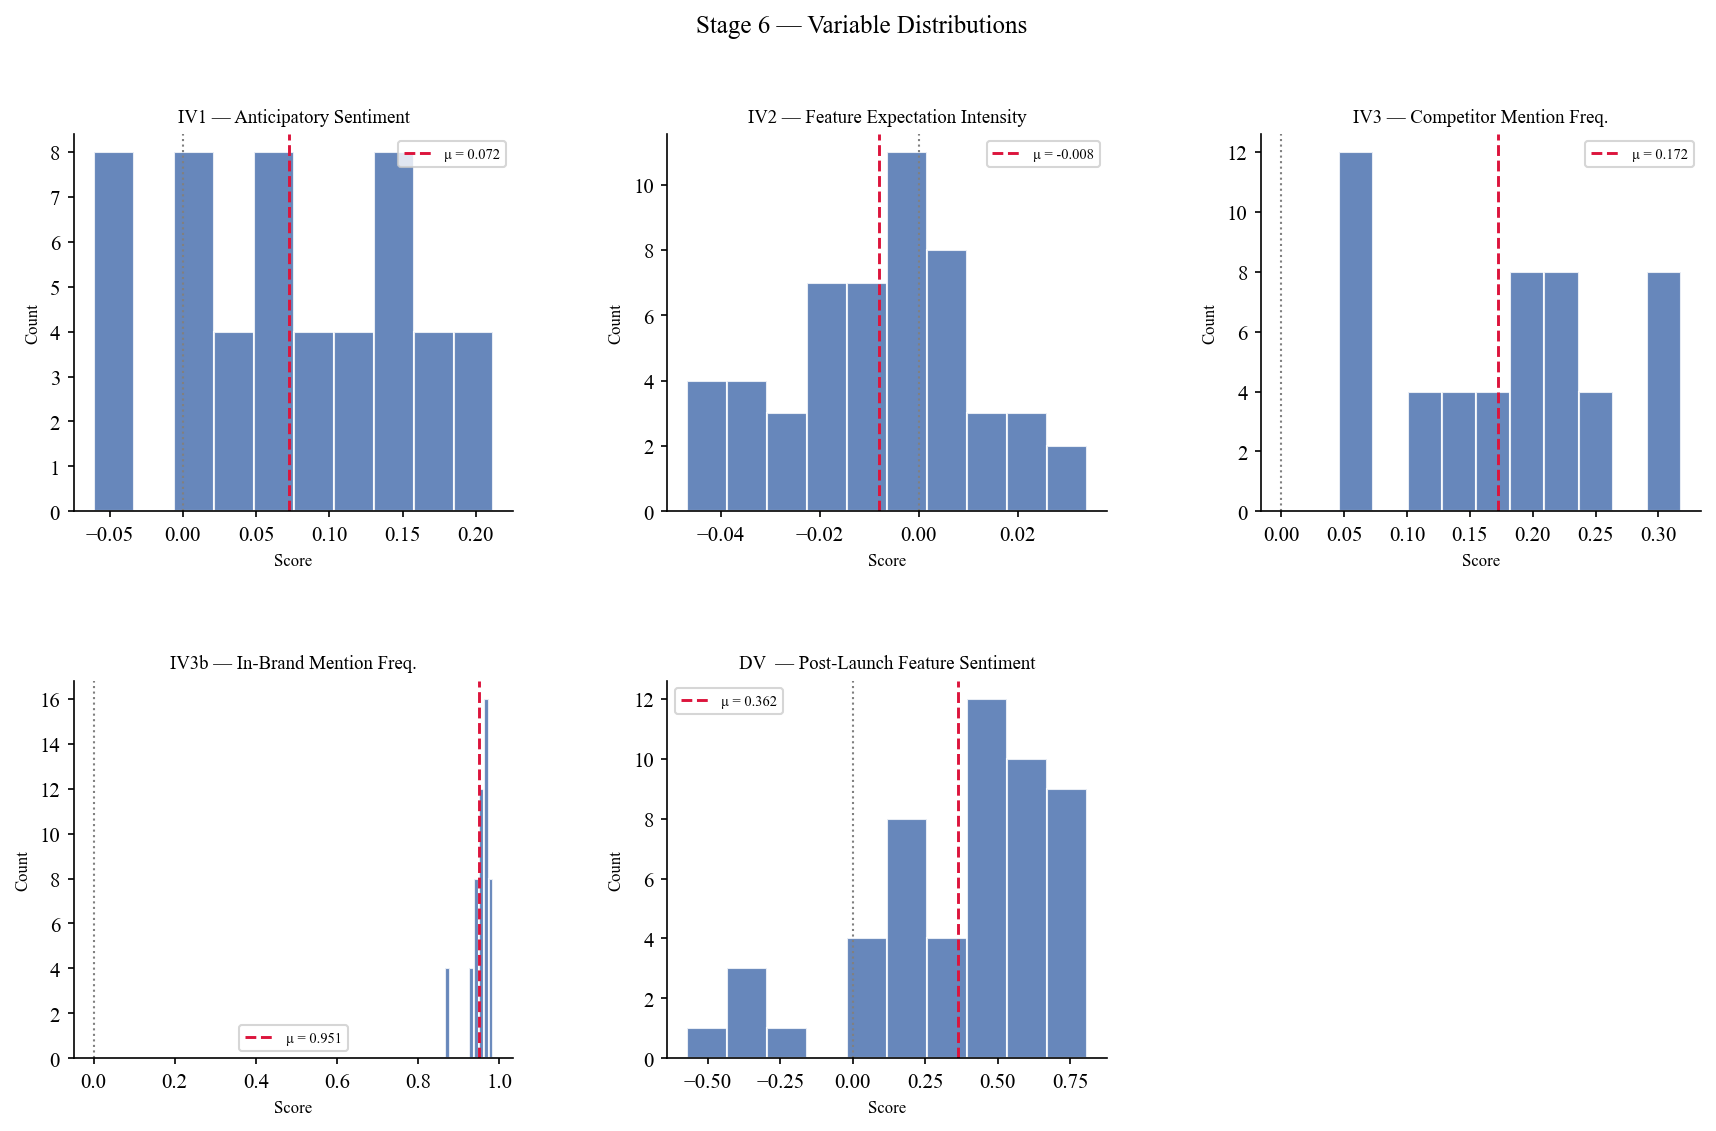

17:00:46  INFO     Distribution plot saved → data\stage6_distributions.png



── DV by product type ───────────────────────────────────
               mean    std    min    max  count
product_type                                   
0             0.512  0.175  0.022  0.766     20
1             0.268  0.361 -0.570  0.809     32

── Per-event variable summary ───────────────────────────
           event  product_type     IV1  IV2_mean   IV3   DV_mean  n_features
   galaxy_s20_fe             1  0.0440 -0.013850 0.150  0.363050           4
galaxy_s21_ultra             1  0.0533 -0.024525 0.104  0.264425           4
galaxy_s22_ultra             1 -0.0609 -0.023825 0.166 -0.135875           4
       galaxy_s6             1  0.0034 -0.004175 0.198  0.108600           4
   galaxy_tab_s2             0  0.0604  0.007875 0.318  0.343050           4
      ipad_air_2             1  0.1430  0.000850 0.058  0.307075           4
     ipad_air_m1             1  0.1286 -0.010050 0.052  0.383025           4
   ipad_pro_2018             1  0.2120  0.010825 0.046  0.312200          

In [8]:
# ============================================================
# CELL 14 — Descriptive Stats & Correlation Matrix
# Sanity check before handing off to Stage 7.
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
 
MODEL_VARS = [
    "sentiment_IV1",
    "pre_expect_score_IV2",
    "competitor_freq_IV3",
    "inbrand_freq_IV3b",
    "post_sentiment_DV",
    "product_type",
    "pre_launch_volume",
    "post_review_count",
]
 
print("\n── Descriptive statistics ───────────────────────────────")
print(df[MODEL_VARS].describe().round(4).to_string())
 
print("\n── Correlation matrix (IVs + DV) ────────────────────────")
corr_vars = [
    "sentiment_IV1", "pre_expect_score_IV2",
    "competitor_freq_IV3", "inbrand_freq_IV3b", "post_sentiment_DV",
    "pre_launch_volume", "post_review_count",
]
print(df[corr_vars].corr().round(3).to_string())
 
# ── Distribution plots ───────────────────────────────────────
plot_map = {
    "sentiment_IV1":         "IV1 — Anticipatory Sentiment",
    "pre_expect_score_IV2":  "IV2 — Feature Expectation Intensity",
    "competitor_freq_IV3":   "IV3 — Competitor Mention Freq.",
    "inbrand_freq_IV3b":     "IV3b — In-Brand Mention Freq.",
    "post_sentiment_DV":     "DV  — Post-Launch Feature Sentiment",
}
 
fig = plt.figure(figsize=(14, 8))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
 
for idx, (col, label) in enumerate(plot_map.items()):
    ax   = fig.add_subplot(gs[idx // 3, idx % 3])
    vals = df[col].dropna()
    ax.hist(vals, bins=10, edgecolor="white", color="#4C72B0", alpha=0.85)
    ax.axvline(vals.mean(), color="crimson", linestyle="--",
               linewidth=1.4, label=f"μ = {vals.mean():.3f}")
    ax.axvline(0, color="grey", linestyle=":", linewidth=1.0)
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("Score", fontsize=8)
    ax.set_ylabel("Count",  fontsize=8)
    ax.legend(fontsize=7)
 
fig.suptitle("Stage 6 — Variable Distributions", fontsize=12)
plot_path = OUTPUT_DIR / "stage6_distributions.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
log.info("Distribution plot saved → %s", plot_path)
 
# ── Hedonic vs utilitarian DV comparison ─────────────────────
print("\n── DV by product type ───────────────────────────────────")
print(df.groupby("product_type")["post_sentiment_DV"]
      .agg(["mean", "std", "min", "max", "count"]).round(3))
 
# ── Per-event IV summary ─────────────────────────────────────
print("\n── Per-event variable summary ───────────────────────────")
event_summary = df.groupby(["event", "product_type"]).agg(
    IV1=("sentiment_IV1",        "first"),
    IV2_mean=("pre_expect_score_IV2", "mean"),
    IV3=("competitor_freq_IV3",  "first"),
    DV_mean=("post_sentiment_DV", "mean"),
    n_features=("feature", "count"),
).reset_index()
print(event_summary.to_string(index=False))

# ── VIF check including controls ─────────────────────────────
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

vif_cols = [
    "sentiment_IV1_c", "pre_expect_score_IV2_c",
    "competitor_freq_IV3_c", "inbrand_freq_IV3b_c",
    "pre_launch_volume", "post_review_count",
]
X_vif = add_constant(df[vif_cols].dropna().astype(float))
vif_df = pd.DataFrame({
    "variable": vif_cols,
    "VIF": [variance_inflation_factor(X_vif.values, i + 1)
            for i in range(len(vif_cols))]
}).sort_values("VIF", ascending=False)

print("\n── VIF (main predictors + controls) ────────────────────")
print(vif_df.round(2).to_string(index=False))
print("\nRule of thumb: VIF > 5 warrants attention, > 10 is problematic.")
 

In [9]:
# ============================================================
# CELL 15 — Save Modelling-Ready CSV
# ============================================================
 
# Final column order for thesis_modelling.csv
FINAL_COLS = [
    # Identifiers
    "event", "brand", "feature", "launch_date", "product_type",
    # Raw IVs
    "sentiment_IV1",
    "pre_expect_score_IV2",
    "competitor_freq_IV3",
    "inbrand_freq_IV3b",
    # Mean-centered IVs (used in interaction terms)
    "sentiment_IV1_c",
    "pre_expect_score_IV2_c",
    "competitor_freq_IV3_c",
    "inbrand_freq_IV3b_c",
    # DV
    "post_sentiment_DV",
    # Controls
    "pre_launch_volume",
    "post_review_count",
    # Metadata
    "source_mix",
]
 
df_out = df[FINAL_COLS].copy()
 
out_path = OUTPUT_DIR / "thesis_modelling.csv"
df_out.to_csv(out_path, index=False)
log.info("Stage 6 complete — modelling CSV saved → %s", out_path)
 
print(f"\n── Final dataset ────────────────────────────────────────")
print(f"Rows        : {len(df_out)}")
print(f"Columns     : {len(df_out.columns)}")
print(f"Events      : {df_out['event'].nunique()}")
print(f"Hedonic     : {(df_out['product_type']==1).sum()} rows "
      f"({df_out[df_out['product_type']==1]['event'].nunique()} events)")
print(f"Utilitarian : {(df_out['product_type']==0).sum()} rows "
      f"({df_out[df_out['product_type']==0]['event'].nunique()} events)")
print(f"Missing DV  : {df_out['post_sentiment_DV'].isna().sum()} rows")
print(f"\nColumn list :")
for c in df_out.columns:
    print(f"  {c}")

17:00:46  INFO     Stage 6 complete — modelling CSV saved → data\thesis_modelling.csv



── Final dataset ────────────────────────────────────────
Rows        : 52
Columns     : 17
Events      : 13
Hedonic     : 32 rows (8 events)
Utilitarian : 20 rows (5 events)
Missing DV  : 0 rows

Column list :
  event
  brand
  feature
  launch_date
  product_type
  sentiment_IV1
  pre_expect_score_IV2
  competitor_freq_IV3
  inbrand_freq_IV3b
  sentiment_IV1_c
  pre_expect_score_IV2_c
  competitor_freq_IV3_c
  inbrand_freq_IV3b_c
  post_sentiment_DV
  pre_launch_volume
  post_review_count
  source_mix


# OLS

In [10]:
# ============================================================
# STAGE 7 — OLS REGRESSION MODELLING
# modelling.ipynb  |  Cells 16–23
#
# Input : data/thesis_modelling.csv  (40 rows × 17 cols)
# Output: results/regression_main.csv
#         results/regression_standardized.csv
#         results/vif_table.csv
#         results/robustness_summary.csv
#         figures/interaction_IV1.png
#         figures/interaction_IV2.png
#         figures/interaction_IV3.png
#         figures/assumption_checks.png
# ============================================================
 
 
# ============================================================
# CELL 16 — Imports & Setup
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
import warnings
import logging
from pathlib import Path
 
warnings.filterwarnings("ignore")
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-7s  %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger(__name__)
 
np.random.seed(42)
 
DATA_DIR    = Path("data")
RESULTS_DIR = Path("results")
FIGURES_DIR = Path("figures")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
 
# Plotting style
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.size":        10,
})
MED_BLUE = "#4C72B0"
MED_PINK = "#C44E52"
 
df = pd.read_csv(DATA_DIR / "thesis_modelling.csv")
log.info("Loaded modelling dataset: %d rows x %d cols", *df.shape)
 

17:00:47  INFO     Loaded modelling dataset: 52 rows x 17 cols


In [11]:
# ============================================================
# CELL 17 — Main OLS Regression
#
# Formula uses MEAN-CENTERED IVs (_c suffix) for interaction
# terms to reduce multicollinearity (per thesis spec).
# Fixed effects: C(feature), C(brand)
# Controls: pre_launch_volume, post_review_count
# ============================================================
 
formula = """
post_sentiment_DV ~
    sentiment_IV1_c +
    pre_expect_score_IV2_c +
    competitor_freq_IV3_c +
    product_type +
    sentiment_IV1_c:product_type +
    pre_expect_score_IV2_c:product_type +
    competitor_freq_IV3_c:product_type +
    C(feature) +
    C(brand) +
    pre_launch_volume +
    post_review_count
"""
 
model_main = smf.ols(formula=formula, data=df).fit()
print(model_main.summary())
 
 
# ── Clean coefficient table ──────────────────────────────────
def build_coef_table(result, label="main"):
    coef  = result.params
    se    = result.bse
    tstat = result.tvalues
    pval  = result.pvalues
    ci    = result.conf_int()
 
    table = pd.DataFrame({
        "coefficient": coef.round(4),
        "std_error":   se.round(4),
        "t_stat":      tstat.round(3),
        "p_value":     pval.round(4),
        "ci_lower":    ci[0].round(4),
        "ci_upper":    ci[1].round(4),
        "sig":         pval.apply(
            lambda p: "***" if p < .001
                      else ("**" if p < .01
                            else ("*" if p < .05
                                  else ("." if p < .10 else "")))
        ),
    })
    table.index.name = "term"
    out_path = RESULTS_DIR / f"regression_{label}.csv"
    table.to_csv(out_path)
    log.info("Coefficient table saved -> %s", out_path)
    return table
 
coef_table = build_coef_table(model_main, "main")
 
# Print hypothesis-relevant terms only
hyp_terms = [
    "sentiment_IV1_c",
    "pre_expect_score_IV2_c",
    "competitor_freq_IV3_c",
    "product_type",
    "sentiment_IV1_c:product_type",
    "pre_expect_score_IV2_c:product_type",
    "competitor_freq_IV3_c:product_type",
]
 
print("\n── Hypothesis terms ─────────────────────────────────────")
print(coef_table.loc[
    coef_table.index.intersection(hyp_terms)
].to_string())
 
print(f"\nR-squared      : {model_main.rsquared:.4f}")
print(f"Adj. R-squared : {model_main.rsquared_adj:.4f}")
print(f"F-statistic    : {model_main.fvalue:.3f}  (p = {model_main.f_pvalue:.4f})")
print(f"N              : {int(model_main.nobs)}")
 

17:00:47  INFO     Coefficient table saved -> results\regression_main.csv


                            OLS Regression Results                            
Dep. Variable:      post_sentiment_DV   R-squared:                       0.615
Model:                            OLS   Adj. R-squared:                  0.440
Method:                 Least Squares   F-statistic:                     3.501
Date:                Mon, 22 Jun 2026   Prob (F-statistic):           0.000962
Time:                        17:00:47   Log-Likelihood:                 10.192
No. Observations:                  52   AIC:                             13.62
Df Residuals:                      35   BIC:                             46.79
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

In [12]:
# ── IV2 decomposition: compute mention rate from raw text ────
# Uses keyword matching on gold_pre_launch text column.
# This is both the diagnostic AND the candidate simplified IV2.

FEATURE_KEYWORDS = {
    "battery":     ["battery", "charge", "charging", "battery life", "mah"],
    "display":     ["display", "screen", "resolution", "oled", "amoled", "refresh"],
    "performance": ["performance", "speed", "processor", "chip", "lag", "fast", "slow", "benchmark"],
    "price":       ["price", "cost", "expensive", "cheap", "value", "worth", "dollar", "usd"],
}

# Build REGEXP pattern per feature
def kw_pattern(kws):
    return "|".join(kws)

selects = [
    f"COUNTIF(REGEXP_CONTAINS(LOWER(text), r'{kw_pattern(kws)}')) / COUNT(*) AS mention_rate_{feat}"
    for feat, kws in FEATURE_KEYWORDS.items()
]

q = f"""
    SELECT
        product_event AS event,
        COUNT(*) AS n_posts,
        {', '.join(selects)}
    FROM `vuthesis-llm-buzz.thesis_dataset.gold_pre_launch`
    GROUP BY product_event
    ORDER BY event
"""

df_mr = bq.query(q).to_dataframe()

# Reshape to long format for comparison
mr_cols = [f"mention_rate_{f}" for f in FEATURE_KEYWORDS]
df_mr_long = df_mr.melt(
    id_vars=["event", "n_posts"],
    value_vars=mr_cols,
    var_name="feature",
    value_name="mention_rate"
)
df_mr_long["feature"] = df_mr_long["feature"].str.replace("mention_rate_", "")

print("── Mention rate by event × feature ─────────────────────")
pivot = df_mr_long.pivot(index="event", columns="feature", values="mention_rate").round(3)
print(pivot.to_string())

print("\n── Mention rate variance across events (per feature) ───")
print(df_mr_long.groupby("feature")["mention_rate"]
      .agg(["mean", "std", "min", "max"]).round(3).to_string())

print("\n── Current IV2 composite variance (for comparison) ─────")
print(df[["pre_expect_score_IV2"]].describe().round(4).to_string())

── Mention rate by event × feature ─────────────────────
feature           battery  display  performance  price
event                                                 
galaxy_s20_fe       0.082    0.108        0.091  0.114
galaxy_s21_ultra    0.116    0.117        0.079  0.090
galaxy_s22_ultra    0.132    0.098        0.107  0.083
galaxy_s6           0.117    0.093        0.086  0.058
galaxy_tab_s2       0.095    0.192        0.144  0.114
ipad_air_2          0.043    0.093        0.089  0.081
ipad_air_m1         0.048    0.136        0.114  0.140
ipad_pro_2018       0.043    0.160        0.094  0.172
lg_g3               0.121    0.126        0.053  0.045
moto_g_3rd_gen      0.089    0.132        0.110  0.150
moto_g_4th_gen      0.089    0.226        0.163  0.195
moto_g_fast         0.166    0.161        0.185  0.167
pixel_3a            0.103    0.103        0.092  0.142
pixel_4a            0.143    0.089        0.105  0.129

── Mention rate variance across events (per feature) ───
     

---

test iv2

In [13]:
# ── Re-compute mention rate and add to df ────────────────────
from google.cloud import bigquery
import io

bq = bigquery.Client(project="vuthesis-llm-buzz", location="europe-west4")

FEATURE_KEYWORDS = {
    "battery":     ["battery", "charge", "charging", "battery life", "mah"],
    "display":     ["display", "screen", "resolution", "oled", "amoled", "refresh"],
    "performance": ["performance", "speed", "processor", "chip", "lag", "fast", "slow", "benchmark"],
    "price":       ["price", "cost", "expensive", "cheap", "value", "worth", "dollar", "usd"],
}

def kw_pattern(kws):
    return "|".join(kws)

selects = [
    f"COUNTIF(REGEXP_CONTAINS(LOWER(text), r'{kw_pattern(kws)}')) / COUNT(*) AS mention_rate_{feat}"
    for feat, kws in FEATURE_KEYWORDS.items()
]

q = f"""
    SELECT
        product_event AS event,
        {', '.join(selects)}
    FROM `vuthesis-llm-buzz.thesis_dataset.gold_pre_launch`
    GROUP BY product_event
"""

df_mr = bq.query(q).to_dataframe()

# Reshape to long and merge onto df
df_mr_long = df_mr.melt(
    id_vars=["event"],
    value_vars=[f"mention_rate_{f}" for f in FEATURE_KEYWORDS],
    var_name="feature",
    value_name="mention_rate_IV2",
)
df_mr_long["feature"] = df_mr_long["feature"].str.replace("mention_rate_", "")

mr_map = df_mr_long.set_index(["event", "feature"])["mention_rate_IV2"]
df["mention_rate_IV2"]   = df.set_index(["event", "feature"]).index.map(mr_map).values
df["mention_rate_IV2_c"] = df["mention_rate_IV2"] - df["mention_rate_IV2"].mean()

# Verify
print(df[["mention_rate_IV2", "mention_rate_IV2_c"]].describe().round(4))
print(f"\nNaNs: {df['mention_rate_IV2'].isna().sum()}")

       mention_rate_IV2  mention_rate_IV2_c
count           52.0000             52.0000
mean             0.1103              0.0000
std              0.0361              0.0361
min              0.0427             -0.0677
25%              0.0892             -0.0211
50%              0.1078             -0.0025
75%              0.1332              0.0228
max              0.1920              0.0816

NaNs: 0


In [14]:
# ============================================================
# CELL — IV2 Specification Test
# Runs main model twice: once with composite IV2, once with
# mention rate IV2. Compare fit and H2/H4b to decide.
# Does not modify df or any downstream cells.
# ============================================================
import statsmodels.formula.api as smf

CONTROLS  = "pre_launch_volume + post_review_count"
FIXED_EFF = "C(feature) + C(brand)"

formula_composite = """
    post_sentiment_DV ~
        sentiment_IV1_c +
        pre_expect_score_IV2_c +
        competitor_freq_IV3_c +
        product_type +
        sentiment_IV1_c:product_type +
        pre_expect_score_IV2_c:product_type +
        competitor_freq_IV3_c:product_type +
""" + FIXED_EFF + " + " + CONTROLS

formula_mention = """
    post_sentiment_DV ~
        sentiment_IV1_c +
        mention_rate_IV2_c +
        competitor_freq_IV3_c +
        product_type +
        sentiment_IV1_c:product_type +
        mention_rate_IV2_c:product_type +
        competitor_freq_IV3_c:product_type +
""" + FIXED_EFF + " + " + CONTROLS

m_composite = smf.ols(formula=formula_composite, data=df).fit()
m_mention   = smf.ols(formula=formula_mention,   data=df).fit()

# ── Side-by-side comparison ──────────────────────────────────
rows = [
    ("R²",          f"{m_composite.rsquared:.4f}",       f"{m_mention.rsquared:.4f}"),
    ("Adj. R²",     f"{m_composite.rsquared_adj:.4f}",   f"{m_mention.rsquared_adj:.4f}"),
    ("AIC",         f"{m_composite.aic:.2f}",             f"{m_mention.aic:.2f}"),
    ("--- H1 ---",  "", ""),
    ("IV1 b",       f"{m_composite.params['sentiment_IV1_c']:.4f}",
                    f"{m_mention.params['sentiment_IV1_c']:.4f}"),
    ("IV1 p",       f"{m_composite.pvalues['sentiment_IV1_c']:.4f}",
                    f"{m_mention.pvalues['sentiment_IV1_c']:.4f}"),
    ("--- H2 ---",  "", ""),
    ("IV2 b",       f"{m_composite.params['pre_expect_score_IV2_c']:.4f}",
                    f"{m_mention.params['mention_rate_IV2_c']:.4f}"),
    ("IV2 p",       f"{m_composite.pvalues['pre_expect_score_IV2_c']:.4f}",
                    f"{m_mention.pvalues['mention_rate_IV2_c']:.4f}"),
    ("--- H3 ---",  "", ""),
    ("IV3 b",       f"{m_composite.params['competitor_freq_IV3_c']:.4f}",
                    f"{m_mention.params['competitor_freq_IV3_c']:.4f}"),
    ("IV3 p",       f"{m_composite.pvalues['competitor_freq_IV3_c']:.4f}",
                    f"{m_mention.pvalues['competitor_freq_IV3_c']:.4f}"),
    ("--- H4b ---", "", ""),
    ("IV2×type b",  f"{m_composite.params['pre_expect_score_IV2_c:product_type']:.4f}",
                    f"{m_mention.params['mention_rate_IV2_c:product_type']:.4f}"),
    ("IV2×type p",  f"{m_composite.pvalues['pre_expect_score_IV2_c:product_type']:.4f}",
                    f"{m_mention.pvalues['mention_rate_IV2_c:product_type']:.4f}"),
]

print(f"\n{'Metric':<20} {'Composite IV2':>15} {'Mention Rate IV2':>17}")
print("─" * 54)
for label, v1, v2 in rows:
    if label.startswith("---"):
        print(f"  {label}")
    else:
        print(f"  {label:<18} {v1:>15} {v2:>17}")


Metric                 Composite IV2  Mention Rate IV2
──────────────────────────────────────────────────────
  R²                          0.6154            0.6137
  Adj. R²                     0.4396            0.4372
  AIC                          13.62             13.84
  --- H1 ---
  IV1 b                      12.2121            7.7817
  IV1 p                       0.1526            0.3558
  --- H2 ---
  IV2 b                      -6.6427            2.6670
  IV2 p                       0.1650            0.2682
  --- H3 ---
  IV3 b                      -4.6123           -6.4525
  IV3 p                       0.2230            0.1047
  --- H4b ---
  IV2×type b                  8.4544           -1.0131
  IV2×type p                  0.1201            0.7137


In [15]:
formula = """
post_sentiment_DV ~
    sentiment_IV1_c +
    pre_expect_score_IV2_c +
    competitor_freq_IV3_c +
    inbrand_freq_IV3b +
    product_type +
    C(feature) +
    C(brand)
"""
 
model_main = smf.ols(formula=formula, data=df).fit()
print(model_main.summary())
 
 
# ── Clean coefficient table ──────────────────────────────────
def build_coef_table(result, label="main"):
    coef  = result.params
    se    = result.bse
    tstat = result.tvalues
    pval  = result.pvalues
    ci    = result.conf_int()
 
    table = pd.DataFrame({
        "coefficient": coef.round(4),
        "std_error":   se.round(4),
        "t_stat":      tstat.round(3),
        "p_value":     pval.round(4),
        "ci_lower":    ci[0].round(4),
        "ci_upper":    ci[1].round(4),
        "sig":         pval.apply(
            lambda p: "***" if p < .001
                      else ("**" if p < .01
                            else ("*" if p < .05
                                  else ("." if p < .10 else "")))
        ),
    })
    table.index.name = "term"
    out_path = RESULTS_DIR / f"regression_{label}.csv"
    table.to_csv(out_path)
    log.info("Coefficient table saved -> %s", out_path)
    return table
 
coef_table = build_coef_table(model_main, "main")
 
# Print hypothesis-relevant terms only
hyp_terms = [
    "sentiment_IV1_c",
    "pre_expect_score_IV2_c",
    "competitor_freq_IV3_c",
    "product_type",
    "sentiment_IV1_c:product_type",
    "pre_expect_score_IV2_c:product_type",
    "competitor_freq_IV3_c:product_type",
]
 
print("\n── Hypothesis terms ─────────────────────────────────────")
print(coef_table.loc[
    coef_table.index.intersection(hyp_terms)
].to_string())
 
print(f"\nR-squared      : {model_main.rsquared:.4f}")
print(f"Adj. R-squared : {model_main.rsquared_adj:.4f}")
print(f"F-statistic    : {model_main.fvalue:.3f}  (p = {model_main.f_pvalue:.4f})")
print(f"N              : {int(model_main.nobs)}")

17:00:50  INFO     Coefficient table saved -> results\regression_main.csv


                            OLS Regression Results                            
Dep. Variable:      post_sentiment_DV   R-squared:                       0.529
Model:                            OLS   Adj. R-squared:                  0.384
Method:                 Least Squares   F-statistic:                     3.651
Date:                Mon, 22 Jun 2026   Prob (F-statistic):            0.00104
Time:                        17:00:50   Log-Likelihood:                 4.9231
No. Observations:                  52   AIC:                             16.15
Df Residuals:                      39   BIC:                             41.52
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

In [16]:
formula = """
post_sentiment_DV ~
    sentiment_IV1_c +
    pre_expect_score_IV2_c +
    competitor_freq_IV3_c +
    product_type +
   pre_expect_score_IV2_c:product_type +
    C(feature) +
    C(brand)
"""
 
model_main = smf.ols(formula=formula, data=df).fit()
print(model_main.summary())
 
 
# ── Clean coefficient table ──────────────────────────────────
def build_coef_table(result, label="main"):
    coef  = result.params
    se    = result.bse
    tstat = result.tvalues
    pval  = result.pvalues
    ci    = result.conf_int()
 
    table = pd.DataFrame({
        "coefficient": coef.round(4),
        "std_error":   se.round(4),
        "t_stat":      tstat.round(3),
        "p_value":     pval.round(4),
        "ci_lower":    ci[0].round(4),
        "ci_upper":    ci[1].round(4),
        "sig":         pval.apply(
            lambda p: "***" if p < .001
                      else ("**" if p < .01
                            else ("*" if p < .05
                                  else ("." if p < .10 else "")))
        ),
    })
    table.index.name = "term"
    out_path = RESULTS_DIR / f"regression_{label}.csv"
    table.to_csv(out_path)
    log.info("Coefficient table saved -> %s", out_path)
    return table
 
coef_table = build_coef_table(model_main, "main")
 
# Print hypothesis-relevant terms only
hyp_terms = [
    "sentiment_IV1_c",
    "pre_expect_score_IV2_c",
    "competitor_freq_IV3_c",
    "product_type",
    "sentiment_IV1_c:product_type",
    "pre_expect_score_IV2_c:product_type",
    "competitor_freq_IV3_c:product_type",
]
 
print("\n── Hypothesis terms ─────────────────────────────────────")
print(coef_table.loc[
    coef_table.index.intersection(hyp_terms)
].to_string())
 
print(f"\nR-squared      : {model_main.rsquared:.4f}")
print(f"Adj. R-squared : {model_main.rsquared_adj:.4f}")
print(f"F-statistic    : {model_main.fvalue:.3f}  (p = {model_main.f_pvalue:.4f})")
print(f"N              : {int(model_main.nobs)}")
 

17:00:50  INFO     Coefficient table saved -> results\regression_main.csv


                            OLS Regression Results                            
Dep. Variable:      post_sentiment_DV   R-squared:                       0.560
Model:                            OLS   Adj. R-squared:                  0.425
Method:                 Least Squares   F-statistic:                     4.144
Date:                Mon, 22 Jun 2026   Prob (F-statistic):           0.000351
Time:                        17:00:50   Log-Likelihood:                 6.7187
No. Observations:                  52   AIC:                             12.56
Df Residuals:                      39   BIC:                             37.93
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

In [17]:
formula = """
post_sentiment_DV ~
    sentiment_IV1_c +
    pre_expect_score_IV2_c +
    competitor_freq_IV3_c +
   sentiment_IV1_c:competitor_freq_IV3_c +
    C(feature) +
    C(brand)
"""
 
model_main = smf.ols(formula=formula, data=df).fit()
print(model_main.summary())
 
 
# ── Clean coefficient table ──────────────────────────────────
def build_coef_table(result, label="main"):
    coef  = result.params
    se    = result.bse
    tstat = result.tvalues
    pval  = result.pvalues
    ci    = result.conf_int()
 
    table = pd.DataFrame({
        "coefficient": coef.round(4),
        "std_error":   se.round(4),
        "t_stat":      tstat.round(3),
        "p_value":     pval.round(4),
        "ci_lower":    ci[0].round(4),
        "ci_upper":    ci[1].round(4),
        "sig":         pval.apply(
            lambda p: "***" if p < .001
                      else ("**" if p < .01
                            else ("*" if p < .05
                                  else ("." if p < .10 else "")))
        ),
    })
    table.index.name = "term"
    out_path = RESULTS_DIR / f"regression_{label}.csv"
    table.to_csv(out_path)
    log.info("Coefficient table saved -> %s", out_path)
    return table
 
coef_table = build_coef_table(model_main, "main")
 
# Print hypothesis-relevant terms only
hyp_terms = [
    "sentiment_IV1_c",
    "pre_expect_score_IV2_c",
    "competitor_freq_IV3_c",
    "product_type",
    "sentiment_IV1_c:product_type",
    "pre_expect_score_IV2_c:product_type",
    "competitor_freq_IV3_c:product_type",
]
 
print("\n── Hypothesis terms ─────────────────────────────────────")
print(coef_table.loc[
    coef_table.index.intersection(hyp_terms)
].to_string())
 
print(f"\nR-squared      : {model_main.rsquared:.4f}")
print(f"Adj. R-squared : {model_main.rsquared_adj:.4f}")
print(f"F-statistic    : {model_main.fvalue:.3f}  (p = {model_main.f_pvalue:.4f})")
print(f"N              : {int(model_main.nobs)}")

                            OLS Regression Results                            
Dep. Variable:      post_sentiment_DV   R-squared:                       0.518
Model:                            OLS   Adj. R-squared:                  0.385
Method:                 Least Squares   F-statistic:                     3.902
Date:                Mon, 22 Jun 2026   Prob (F-statistic):           0.000717
Time:                        17:00:50   Log-Likelihood:                 4.3021
No. Observations:                  52   AIC:                             15.40
Df Residuals:                      40   BIC:                             38.81
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

17:00:50  INFO     Coefficient table saved -> results\regression_main.csv



── Hypothesis terms ─────────────────────────────────────
                        coefficient  std_error  t_stat  p_value  ci_lower  ci_upper sig
term                                                                                   
sentiment_IV1_c              2.3797     1.0855   2.192   0.0342    0.1857    4.5737   *
pre_expect_score_IV2_c      -2.0084     2.6635  -0.754   0.4552   -7.3916    3.3748    
competitor_freq_IV3_c        0.5220     0.8480   0.616   0.5417   -1.1919    2.2360    

R-squared      : 0.5176
Adj. R-squared : 0.3850
F-statistic    : 3.902  (p = 0.0007)
N              : 52


In [18]:
# ============================================================
# CELL 18 — Standardized Beta Coefficients
# Needed for cross-variable effect size comparison
# ============================================================
 
# Z-score all continuous variables
std_cols = [
    "post_sentiment_DV",
    "sentiment_IV1_c",
    "pre_expect_score_IV2_c",
    "competitor_freq_IV3_c",
    "pre_launch_volume",
    "post_review_count",
]
 
df_std = df.copy()
for col in std_cols:
    df_std[col] = (df[col] - df[col].mean()) / df[col].std()
 
model_std = smf.ols(formula=formula, data=df_std).fit()
coef_std  = build_coef_table(model_std, "standardized")
 
print("\n── Standardized betas (hypothesis terms) ────────────────")
print(coef_std.loc[
    coef_std.index.intersection(hyp_terms),
    ["coefficient", "std_error", "p_value", "sig"]
].rename(columns={"coefficient": "std_beta"}).to_string())
 
 

17:00:50  INFO     Coefficient table saved -> results\regression_standardized.csv



── Standardized betas (hypothesis terms) ────────────────
                        std_beta  std_error  p_value sig
term                                                    
sentiment_IV1_c           0.5867     0.2676   0.0342   *
pre_expect_score_IV2_c   -0.1207     0.1600   0.4552    
competitor_freq_IV3_c     0.1380     0.2242   0.5417    


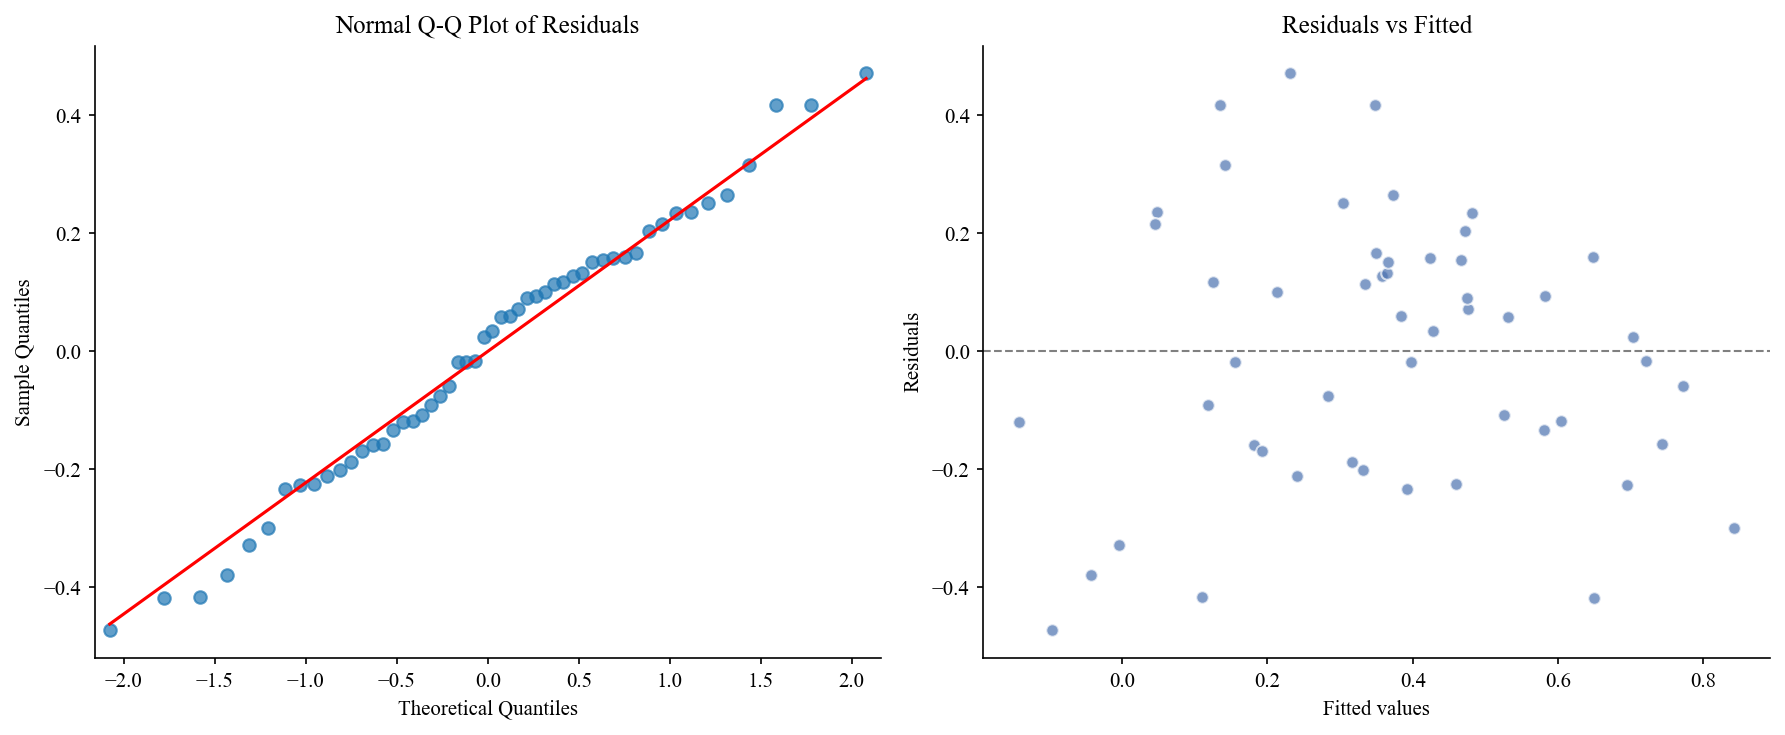

17:00:50  INFO     Assumption plots saved
17:00:50  INFO     VIF table saved



Shapiro-Wilk: W = 0.9833, p = 0.6721 -> normality OK
Breusch-Pagan: LM = 23.5964, p = 0.0145 -> heteroscedasticity detected

── VIF table ────────────────────────────────────────────
              variable   VIF flag
       sentiment_IV1_c 2.043   OK
pre_expect_score_IV2_c 1.421   OK
 competitor_freq_IV3_c 2.637   OK
          product_type 2.286   OK
     pre_launch_volume 1.573   OK
     post_review_count 1.563   OK


In [19]:
# ============================================================
# CELL 19 — Assumption Checks
# (1) Normality of residuals — Q-Q plot + Shapiro-Wilk
# (2) Homoscedasticity  — fitted vs residuals
# (3) Multicollinearity — VIF on IVs + controls
# ============================================================
 
residuals = model_main.resid
fitted    = model_main.fittedvalues
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
# Q-Q plot
sm.qqplot(residuals, line="s", ax=axes[0], alpha=0.7)
axes[0].set_title("Normal Q-Q Plot of Residuals")
 
# Fitted vs residuals
axes[1].scatter(fitted, residuals, color=MED_BLUE, alpha=0.7, edgecolors="white")
axes[1].axhline(0, color="grey", linestyle="--", linewidth=1)
axes[1].set_xlabel("Fitted values")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residuals vs Fitted")
 
plt.tight_layout()
plt.savefig(FIGURES_DIR / "assumption_checks.png", dpi=150, bbox_inches="tight")
plt.show()
log.info("Assumption plots saved")
 
# Shapiro-Wilk normality test
stat, p_sw = stats.shapiro(residuals)
print(f"\nShapiro-Wilk: W = {stat:.4f}, p = {p_sw:.4f}",
      "-> normality OK" if p_sw > .05 else "-> normality violated (small n, check Q-Q)")
 
# Breusch-Pagan homoscedasticity test
from statsmodels.stats.diagnostic import het_breuschpagan
bp_lm, bp_p, bp_f, bp_fp = het_breuschpagan(residuals, model_main.model.exog)
print(f"Breusch-Pagan: LM = {bp_lm:.4f}, p = {bp_p:.4f}",
      "-> homoscedasticity OK" if bp_p > .05 else "-> heteroscedasticity detected")
 
# VIF — compute on design matrix (excluding fixed effect dummies for clarity)
vif_cols = [
    "sentiment_IV1_c",
    "pre_expect_score_IV2_c",
    "competitor_freq_IV3_c",
    "product_type",
    "pre_launch_volume",
    "post_review_count",
]
X_vif = sm.add_constant(df[vif_cols])
vif_df = pd.DataFrame({
    "variable": vif_cols,
    "VIF": [variance_inflation_factor(X_vif.values, i + 1)
            for i in range(len(vif_cols))],
}).round(3)
vif_df["flag"] = vif_df["VIF"].apply(
    lambda v: "HIGH (>10)" if v > 10 else ("MODERATE (5-10)" if v > 5 else "OK")
)
print("\n── VIF table ────────────────────────────────────────────")
print(vif_df.to_string(index=False))
vif_df.to_csv(RESULTS_DIR / "vif_table.csv", index=False)
log.info("VIF table saved")
 
 

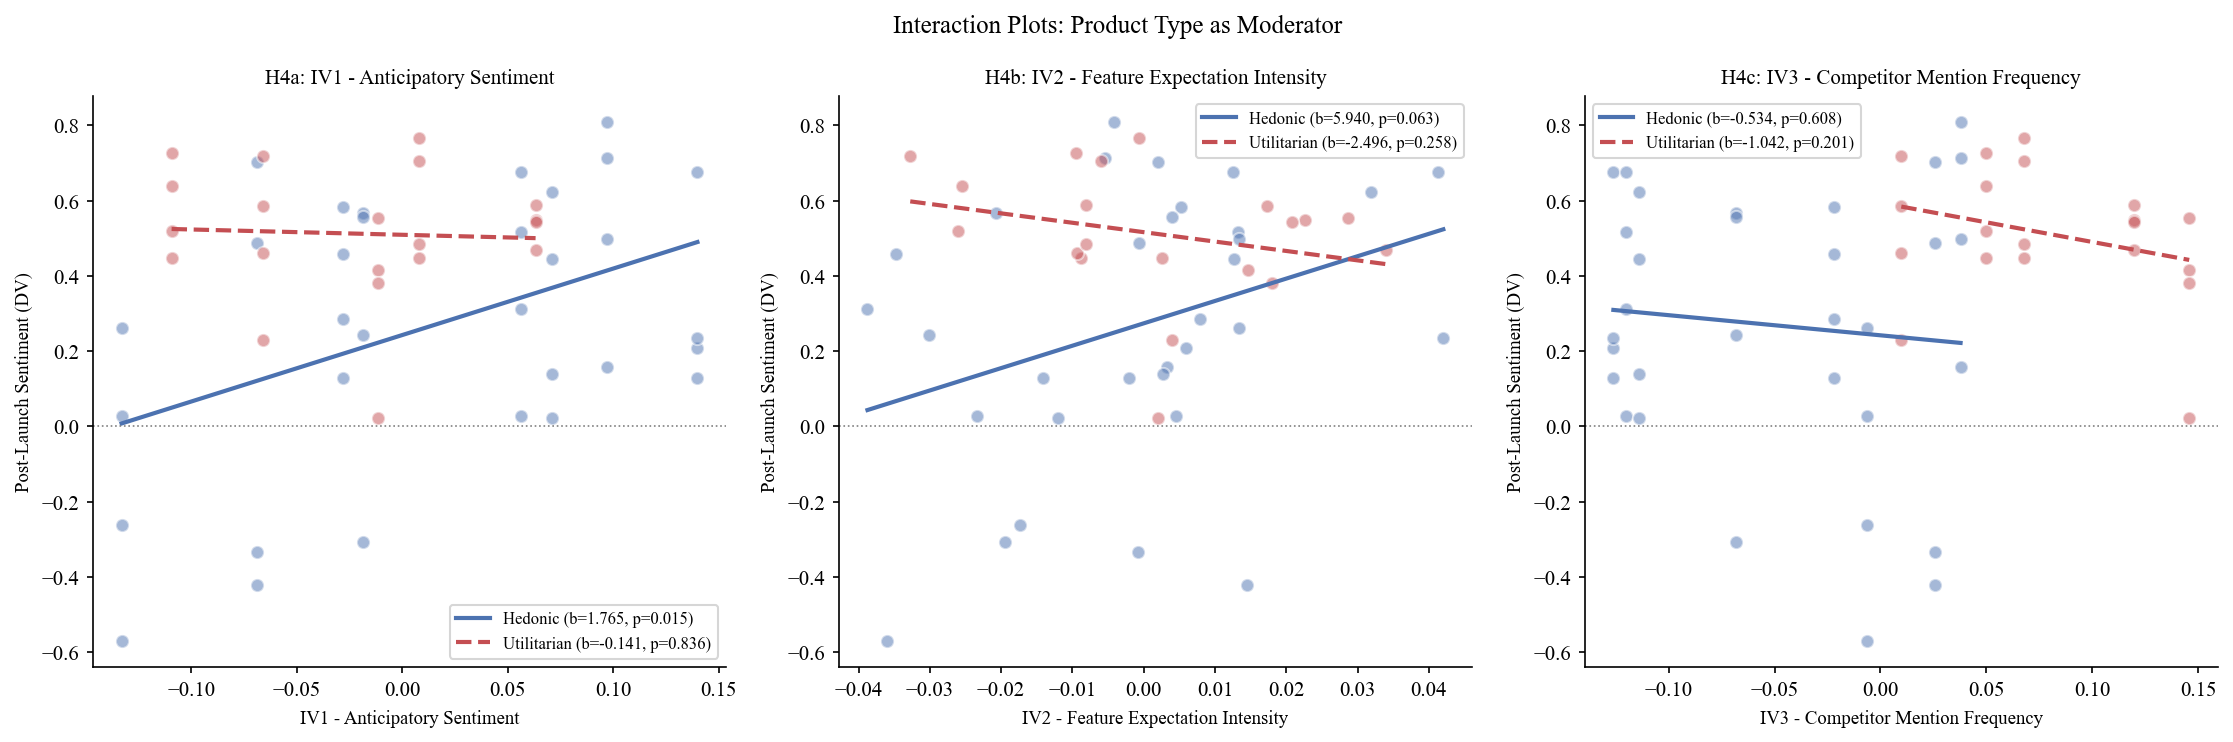

17:00:52  INFO     Interaction plots saved


In [20]:
# ============================================================
# CELL 20 — Interaction Plots (H4a, H4b, H4c)
# Simple slopes: separate regression lines for
# hedonic (product_type=1) vs utilitarian (product_type=0)
# ============================================================
 
def interaction_plot(iv_col, iv_label, hyp_label, ax):
    """Plot DV ~ IV separately for hedonic and utilitarian."""
    for ptype, color, linestyle, label in [
        (1, MED_BLUE,  "-",  "Hedonic"),
        (0, MED_PINK, "--", "Utilitarian"),
    ]:
        subset = df[df["product_type"] == ptype]
        x = subset[iv_col]
        y = subset["post_sentiment_DV"]
 
        # Fit simple slope
        slope, intercept, r, p, se = stats.linregress(x, y)
 
        x_range = np.linspace(x.min(), x.max(), 100)
        ax.plot(x_range, intercept + slope * x_range,
                color=color, linestyle=linestyle,
                linewidth=2, label=f"{label} (b={slope:.3f}, p={p:.3f})")
        ax.scatter(x, y, color=color, alpha=0.5, s=40, edgecolors="white")
 
    ax.set_xlabel(iv_label, fontsize=9)
    ax.set_ylabel("Post-Launch Sentiment (DV)", fontsize=9)
    ax.set_title(f"{hyp_label}: {iv_label}", fontsize=10)
    ax.legend(fontsize=8)
    ax.axhline(0, color="grey", linestyle=":", linewidth=0.8)
 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
 
interaction_plot("sentiment_IV1_c",        "IV1 - Anticipatory Sentiment",        "H4a", axes[0])
interaction_plot("pre_expect_score_IV2_c", "IV2 - Feature Expectation Intensity", "H4b", axes[1])
interaction_plot("competitor_freq_IV3_c",  "IV3 - Competitor Mention Frequency",  "H4c", axes[2])
 
fig.suptitle("Interaction Plots: Product Type as Moderator", fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "interaction_plots.png", dpi=150, bbox_inches="tight")
plt.show()
log.info("Interaction plots saved")
 

In [21]:
# ── Generate star_ratings.csv from BigQuery ──────────────────
star_q = """
    SELECT
        product_event AS event,
        ROUND(AVG(rating), 4)   AS mean_star_rating,
        COUNT(*)                AS n_reviews
    FROM `vuthesis-llm-buzz.thesis_dataset.gold_post_launch`
    WHERE rating IS NOT NULL
    GROUP BY product_event
"""

star_df = bq.query(star_q).to_dataframe()
print(star_df.sort_values("event").to_string(index=False))

star_df.to_csv(DATA_DIR / "star_ratings.csv", index=False)
log.info("star_ratings.csv saved: %d events", len(star_df))

17:00:52  INFO     star_ratings.csv saved: 14 events


           event  mean_star_rating  n_reviews
   galaxy_s20_fe            3.7902        224
galaxy_s21_ultra            3.8526        190
galaxy_s22_ultra            3.5040        250
       galaxy_s6            3.9265        204
   galaxy_tab_s2            4.1951       1061
      ipad_air_2            4.5455        198
     ipad_air_m1            4.3662        213
   ipad_pro_2018            4.2618        317
           lg_g3            4.4720        214
  moto_g_3rd_gen            4.2599        304
  moto_g_4th_gen            4.1339        381
     moto_g_fast            4.0991        212
        pixel_3a            4.3468        248
        pixel_4a            4.1022        313


In [22]:
# ============================================================
# CELL 21 — Robustness Checks (HC3 robust SEs throughout)
#
# All specs use the reduced main model formula:
#   - Only IV2×product_type interaction retained
#   - Standardized controls (pre_launch_volume_z, post_review_count_z)
#   - HC3 robust standard errors for consistency with main model
#
# RC1: Exclude 2 lowest pre-launch volume events
# RC2: Star rating as alternative DV
# RC3: IV3b (in-brand frequency) as alternative IV3
# RC4: Drop brand fixed effects
# ============================================================

robustness_results = {}

# ── Base formula (reduced spec, standardized controls) ───────
FORMULA_BASE = """
    post_sentiment_DV ~
        sentiment_IV1_c +
        pre_expect_score_IV2_c +
        competitor_freq_IV3_c +
        product_type +
        pre_expect_score_IV2_c:product_type +
        C(feature) + C(brand) +
        pre_launch_volume_z + post_review_count_z
"""

def _extract(m, iv3b=False):
    """Pull key stats from a fitted model."""
    iv3_col = "inbrand_freq_IV3b_c" if iv3b else "competitor_freq_IV3_c"
    return {
        "n":      int(m.nobs),
        "r2":     round(m.rsquared,     4),
        "r2_adj": round(m.rsquared_adj, 4),
        "b_IV1":  round(m.params .get("sentiment_IV1_c",                  np.nan), 4),
        "b_IV2":  round(m.params .get("pre_expect_score_IV2_c",           np.nan), 4),
        "b_IV3":  round(m.params .get(iv3_col,                            np.nan), 4),
        "b_H4b":  round(m.params .get("pre_expect_score_IV2_c:product_type", np.nan), 4),
        "p_IV1":  round(m.pvalues.get("sentiment_IV1_c",                  np.nan), 4),
        "p_IV2":  round(m.pvalues.get("pre_expect_score_IV2_c",           np.nan), 4),
        "p_IV3":  round(m.pvalues.get(iv3_col,                            np.nan), 4),
        "p_H4b":  round(m.pvalues.get("pre_expect_score_IV2_c:product_type", np.nan), 4),
    }


# ── RC1 — Volume sensitivity ─────────────────────────────────
low_vol_events = (df.groupby("event")["pre_launch_volume"]
                  .first().nsmallest(2).index.tolist())
df_rc1 = df[~df["event"].isin(low_vol_events)].copy()
log.info("RC1 excluded events: %s", low_vol_events)

if len(df_rc1) >= 20:
    m_rc1 = smf.ols(formula=FORMULA_BASE, data=df_rc1).fit(cov_type="HC3")
    robustness_results["RC1_volume_filter"] = _extract(m_rc1)
    log.info("RC1 complete: n=%d", int(m_rc1.nobs))
else:
    log.warning("RC1 skipped: insufficient rows (n=%d)", len(df_rc1))
    robustness_results["RC1_volume_filter"] = {"note": "skipped — insufficient rows"}


# ── RC2 — Alternative DV: star rating ────────────────────────
star_path = DATA_DIR / "star_ratings.csv"
if star_path.exists():
    df_stars = pd.read_csv(star_path)
    df_rc2   = df.merge(df_stars[["event", "mean_star_rating"]],
                        on="event", how="left")
    # Event-level DV — drop feature FE (no within-event variance)
    formula_rc2 = FORMULA_BASE.replace(
        "post_sentiment_DV", "mean_star_rating"
    ).replace("C(feature) +", "")

    m_rc2 = smf.ols(
        formula=formula_rc2,
        data=df_rc2.dropna(subset=["mean_star_rating"])
    ).fit(cov_type="HC3")
    robustness_results["RC2_star_rating_DV"] = _extract(m_rc2)
    log.info("RC2 complete: star rating DV")
else:
    log.warning("RC2 skipped: %s not found.", star_path)
    robustness_results["RC2_star_rating_DV"] = {"note": "skipped — star_ratings.csv not found"}


# ── RC3 — Alternative IV3: in-brand frequency (IV3b) ─────────
# Note: post_review_count dropped from this spec due to high
# collinearity with IV3b (r=-.84, VIF=6.24 at n=40)
formula_rc3 = FORMULA_BASE\
    .replace("competitor_freq_IV3_c", "inbrand_freq_IV3b_c")\
    .replace("post_review_count_z +", "")

m_rc3 = smf.ols(formula=formula_rc3, data=df).fit(cov_type="HC3")
robustness_results["RC3_IV3b_inbrand"] = _extract(m_rc3, iv3b=True)
log.info("RC3 complete: IV3b in-brand alternative")


# ── RC4 — Drop brand fixed effects ───────────────────────────
formula_rc4 = FORMULA_BASE.replace("C(brand) +", "")
m_rc4 = smf.ols(formula=formula_rc4, data=df).fit(cov_type="HC3")
robustness_results["RC4_no_brand_FE"] = _extract(m_rc4)
log.info("RC4 complete: no brand fixed effects")


# ── Summary table ────────────────────────────────────────────
rc_df = pd.DataFrame(robustness_results).T
rc_df.index.name = "specification"

print("\n── Robustness check summary (HC3 robust SEs) ───────────")
print(rc_df.to_string())

rc_df.to_csv(RESULTS_DIR / "robustness_summary.csv")
log.info("Robustness summary saved")
 
 

17:00:52  INFO     RC1 excluded events: ['galaxy_tab_s2', 'moto_g_3rd_gen']


PatsyError: Error evaluating factor: NameError: name 'post_review_count_z' is not defined
    post_sentiment_DV ~         sentiment_IV1_c +         pre_expect_score_IV2_c +         competitor_freq_IV3_c +         product_type +         pre_expect_score_IV2_c:product_type +         C(feature) + C(brand) +         pre_launch_volume_z + post_review_count_z
                                                                                                                                                                                                                                                      ^^^^^^^^^^^^^^^^^^^

In [ ]:
# Standardize controls before modelling
df["pre_launch_volume_z"] = (
    df["pre_launch_volume"] - df["pre_launch_volume"].mean()
) / df["pre_launch_volume"].std()

df["post_review_count_z"] = (
    df["post_review_count"] - df["post_review_count"].mean()
) / df["post_review_count"].std()

# Refit with standardized controls + HC3
formula_reduced_z = """
    post_sentiment_DV ~
        sentiment_IV1_c +
        pre_expect_score_IV2_c +
        competitor_freq_IV3_c +
        product_type +
        pre_expect_score_IV2_c:product_type +
        C(feature) + C(brand) +
        pre_launch_volume_z + post_review_count_z
"""

m_robust_z = smf.ols(formula=formula_reduced_z, data=df).fit(cov_type="HC3")

print(f"Condition number: {np.linalg.cond(m_robust_z.model.exog):.1f}")

hyp_cols = [
    "sentiment_IV1_c",
    "pre_expect_score_IV2_c",
    "competitor_freq_IV3_c",
    "product_type",
    "pre_expect_score_IV2_c:product_type",
]
print("\n── Robust SE estimates (standardized controls) ─────────")
for term in hyp_cols:
    b  = m_robust_z.params.get(term, float("nan"))
    se = m_robust_z.bse.get(term, float("nan"))
    p  = m_robust_z.pvalues.get(term, float("nan"))
    sig = "*" if p < 0.05 else "." if p < 0.10 else ""
    print(f"  {term:<40} b={b:>7.4f}  se={se:>6.4f}  p={p:>6.4f} {sig}")

print(f"\n  Adj. R²: {m_robust_z.rsquared_adj:.4f}")
print(f"  AIC:     {m_robust_z.aic:.2f}")

Condition number: 251.6

── Robust SE estimates (standardized controls) ─────────
  sentiment_IV1_c                          b= 2.0626  se=1.2756  p=0.1059 
  pre_expect_score_IV2_c                   b=-7.6100  se=5.2904  p=0.1503 
  competitor_freq_IV3_c                    b=-0.5466  se=2.7397  p=0.8419 
  product_type                             b=-1.1121  se=1.7780  p=0.5316 
  pre_expect_score_IV2_c:product_type      b= 9.5512  se=5.0355  p=0.0579 .

  Adj. R²: 0.4291
  AIC:     13.47


In [ ]:
# ============================================================
# CELL 22 — Hypothesis Summary Table
# Quick-read table mapping each H to its coefficient,
# direction, significance, and supported/not supported.
# ============================================================
 
def get_term(params, pvalues, key):
    b = params.get(key, np.nan)
    p = pvalues.get(key, np.nan)
    sig = ("***" if p < .001 else "**" if p < .01
           else "*" if p < .05 else "n.s.")
    direction = "positive" if b > 0 else "negative" if b < 0 else "—"
    supported = (
        "Supported" if (p < .05)
        else "Not supported"
    )
    return round(b, 4), round(p, 4), sig, direction, supported
 
p = model_main.params
pv = model_main.pvalues
 
hyp_summary = pd.DataFrame([
    ["H1", "IV1 -> DV (overall sentiment)",
     *get_term(p, pv, "sentiment_IV1_c")],
    ["H2", "IV2 -> DV (feature expectation intensity)",
     *get_term(p, pv, "pre_expect_score_IV2_c")],
    ["H3", "IV3 -> DV (competitor frequency)",
     *get_term(p, pv, "competitor_freq_IV3_c")],
    ["H4a", "IV1 x ProductType interaction",
     *get_term(p, pv, "sentiment_IV1_c:product_type")],
    ["H4b", "IV2 x ProductType interaction",
     *get_term(p, pv, "pre_expect_score_IV2_c:product_type")],
    ["H4c", "IV3 x ProductType interaction",
     *get_term(p, pv, "competitor_freq_IV3_c:product_type")],
], columns=["Hypothesis", "Description", "b", "p", "sig",
            "Direction", "Verdict"])
 
print("\n── Hypothesis summary ───────────────────────────────────")
print(hyp_summary.to_string(index=False))
hyp_summary.to_csv(RESULTS_DIR / "hypothesis_summary.csv", index=False)
log.info("Hypothesis summary saved")
 
 

13:03:37  INFO     Hypothesis summary saved



── Hypothesis summary ───────────────────────────────────
Hypothesis                               Description       b      p  sig Direction       Verdict
        H1             IV1 -> DV (overall sentiment)  2.3797 0.0342    *  positive     Supported
        H2 IV2 -> DV (feature expectation intensity) -2.0084 0.4552 n.s.  negative Not supported
        H3          IV3 -> DV (competitor frequency)  0.5220 0.5417 n.s.  positive Not supported
       H4a             IV1 x ProductType interaction     NaN    NaN n.s.         — Not supported
       H4b             IV2 x ProductType interaction     NaN    NaN n.s.         — Not supported
       H4c             IV3 x ProductType interaction     NaN    NaN n.s.         — Not supported


In [ ]:
# ============================================================
# CELL 23 — Save Full Results Bundle
# ============================================================
 
log.info("Stage 7 complete. Output files:")
for f in sorted(RESULTS_DIR.iterdir()):
    log.info("  results/%s", f.name)
for f in sorted(FIGURES_DIR.iterdir()):
    log.info("  figures/%s", f.name)
 
print("\n== Stage 7 done ==")
print(f"Main model R2     : {model_main.rsquared:.4f}")
print(f"Adj R2            : {model_main.rsquared_adj:.4f}")
print(f"N                 : {int(model_main.nobs)}")
print(f"Robustness checks : {len(robustness_results)} completed")


12:42:19  INFO     Stage 7 complete. Output files:
12:42:19  INFO       results/hypothesis_summary.csv
12:42:19  INFO       results/regression_main.csv
12:42:19  INFO       results/regression_standardized.csv
12:42:19  INFO       results/regression_standardized_corrected.csv
12:42:19  INFO       results/robustness_summary.csv
12:42:19  INFO       results/vif_table.csv
12:42:19  INFO       figures/assumption_checks.png
12:42:19  INFO       figures/interaction_plots.png



== Stage 7 done ==
Main model R2     : 0.5176
Adj R2            : 0.3850
N                 : 52
Robustness checks : 4 completed


In [ ]:
# Standardized beta = b_raw * (SD_x / SD_y)
sd_y = df["post_sentiment_DV"].std()

std_betas = []
for term in hyp_terms:
    b = model_main.params.get(term, np.nan)
    p = model_main.pvalues.get(term, np.nan)
    
    # Get SD of the IV component (first variable in the term)
    base_col = term.split(":")[0]
    sd_x = df[base_col].std() if base_col in df.columns else 1.0
    
    std_b = b * (sd_x / sd_y)
    std_betas.append({
        "term": term,
        "b_raw": round(b, 4),
        "std_beta": round(std_b, 4),
        "p_value": round(p, 4),
        "sig": "***" if p<.001 else "**" if p<.01 else "*" if p<.05 else "." if p<.10 else "n.s."
    })

std_beta_df = pd.DataFrame(std_betas).set_index("term")
print(std_beta_df.to_string())
std_beta_df.to_csv(RESULTS_DIR / "regression_standardized_corrected.csv")

                                      b_raw  std_beta  p_value   sig
term                                                                
sentiment_IV1_c                      2.3797    0.5867   0.0342     *
pre_expect_score_IV2_c              -2.0084   -0.1207   0.4552  n.s.
competitor_freq_IV3_c                0.5220    0.1380   0.5417  n.s.
product_type                            NaN       NaN      NaN  n.s.
sentiment_IV1_c:product_type            NaN       NaN      NaN  n.s.
pre_expect_score_IV2_c:product_type     NaN       NaN      NaN  n.s.
competitor_freq_IV3_c:product_type      NaN       NaN      NaN  n.s.


- Verific de unde vine variatia IV2; testez sa inlocuiesc cu mention rate ul, daca am sentiment la feature-level - daca nu am, atunci folosesc mention rate-ul
- Model pt fiecare IV cu interactiunea (product type) - preview it with descriptives by grouping hedonics & utilitarians
- Ma uit H/U patterns per feature

- Includ si produsele marginals

- Review sentiment cu review rating correlation

- simplify IV2

- variatia de mention rate uri la nivel de produs

- inbrand_freq_IV3b mean centered (nu pt main model) 

- daca mention rate-ul e mic, inmultim cu 10

- descriptives pt sentiment 
- plotting review sentiment per time (cum am facut volumul per produs doar ca e sentiment)

- salvez si un pre dataframe mai mare ca sa explorez mai mult what's going over there
- feature mentions & (cross and in-brand) competitors -> prelaunch discourse -> post-launch reception idea (pot sa pun si competitor mentions post-launch si sa incerc sa explorez asta si cum afecteaza sentimentul) - pt ca acm asum ca pre stuff happens in the same time

- corectez pre launch volume si review volume in dataframe (sunt setate la 500 si 200)

- results - prio on descriptives in special ce ma intereseaza


---

- Am incercat sa rulez mention rate ca IV2 ->
 Metric                 Composite IV2  Mention Rate IV2
──────────────────────────────────────────────────────
  R²                          0.6347            0.6101
  Adj. R²                     0.4302            0.3917
  AIC                          13.69             16.30
  --- H1 ---
  IV1 b                       3.8083            3.2196
  IV1 p                       0.0385            0.0809
  --- H2 ---
  IV2 b                      -8.0212            2.1581
  IV2 p                       0.1283            0.4398
  --- H3 ---
  IV3 b                      -3.0489           -1.5053
  IV3 p                       0.2886            0.5883
  --- H4b ---
  IV2×type b                  9.5444           -0.9727
  IV2×type p                  0.1174            0.7629

- Am incercat sa inmultesc cu 10 composite IV2, rezultatele sunt la fel, nu afecteaza operationalizarea
- Am testat 4 modele:
    - M1: IVs only - fara controls si moderator
    - M2: IVs + control - fara moderator
    - M3: IVs + moderator - fara controls
    - M4: Full model
    ══════════════════════════════════════════════════════════
  M1_bare
══════════════════════════════════════════════════════════
  Metric              Composite     Scaled ×10
  ──────────────────────────────────────────────────────
  ──────────────────────────────────────────────────────
  R²                   0.5282         0.5282  
  Adj.R²               0.3655         0.3655  
  AIC                   15.93          15.93  
  ──────────────────────────────────────────────────────
  IV1 b                2.7498         2.7498  
  IV1 p                0.0515         0.0515  
  ──────────────────────────────────────────────────────
  IV2 b                -2.877        -0.2877  
  IV2 p                0.3638         0.3638  
  ──────────────────────────────────────────────────────
  IV3 b                0.8261         0.8261  
  IV3 p                0.4477         0.4477  
  ──────────────────────────────────────────────────────
  IV2×type b              nan            nan  
  IV2×type p              nan            nan  

══════════════════════════════════════════════════════════
  M2_controls
══════════════════════════════════════════════════════════
  Metric              Composite     Scaled ×10
  ──────────────────────────────────────────────────────
  ──────────────────────────────────────────────────────
  R²                     0.58           0.58  
  Adj.R²               0.3933         0.3933  
  AIC                   15.28          15.28  
  ──────────────────────────────────────────────────────
  IV1 b                3.7262         3.7262  
  IV1 p                0.0251 *       0.0251 *
  ──────────────────────────────────────────────────────
  IV2 b               -1.4939        -0.1494  
  IV2 p                0.6416         0.6416  
  ──────────────────────────────────────────────────────
  IV3 b                2.0462         2.0462  
  IV3 p                0.4302         0.4302  
  ──────────────────────────────────────────────────────
  IV2×type b              nan            nan  
  IV2×type p              nan            nan  

══════════════════════════════════════════════════════════
  M3_moderator
══════════════════════════════════════════════════════════
  Metric              Composite     Scaled ×10
  ──────────────────────────────────────────────────────
  ──────────────────────────────────────────────────────
  R²                   0.5716         0.5716  
  Adj.R²               0.3575         0.3575  
  AIC                   18.06          18.06  
  ──────────────────────────────────────────────────────
  IV1 b                0.2975         0.2975  
  IV1 p                0.9158         0.9158  
  ──────────────────────────────────────────────────────
  IV2 b               -8.2241        -0.8224  
  IV2 p                0.1409         0.1409  
  ──────────────────────────────────────────────────────
  IV3 b               -0.0938        -0.0938  
  IV3 p                0.9713         0.9713  
  ──────────────────────────────────────────────────────
  IV2×type b           8.4953         0.8495  
  IV2×type p           0.1841         0.1841  

══════════════════════════════════════════════════════════
  M4_full
══════════════════════════════════════════════════════════
  Metric              Composite     Scaled ×10
  ──────────────────────────────────────────────────────
  ──────────────────────────────────────────────────────
  R²                   0.6347         0.6347  
  Adj.R²               0.4302         0.4302  
  AIC                   13.69          13.69  
  ──────────────────────────────────────────────────────
  IV1 b                3.8083         3.8083  
  IV1 p                0.0385 *       0.0385 *
  ──────────────────────────────────────────────────────
  IV2 b               -8.0212        -0.8021  
  IV2 p                0.1283         0.1283  
  ──────────────────────────────────────────────────────
  IV3 b               -3.0489        -3.0489  
  IV3 p                0.2886         0.2886  
  ──────────────────────────────────────────────────────
  IV2×type b           9.5444         0.9544  
  IV2×type p           0.1174         0.1174  

  * p < .05


- Am mai incercat si alte reformulari de IV2 si i am dat de cap ce insemna IV2 initial:
    | | Formula | Ce masoara |
    |---|---|---|
    | F1 (current) | `mention_rate × mean_score_when_mentioned` | Salience-weighted expectation - how often the feature is discussed, scaled by sentiment direction |
    | F2 (conditional sentiment) | `mean_score_when_mentioned` = `F1 / mention_rate` | Pure directional expectation — what people expect from the feature when they discuss it, no salience weight |
    | F3 (z-score product) | `z(mention_rate) × z(mean_score)` | Same theory as F1 but both inputs standardised first, eliminating variance compression from multiplying two small decimals |
    | F4 (z-score additive) | `z(mention_rate) + z(mean_score)` | Salience and sentiment contribute independently and additively rather than multiplicatively |

    - Model Equation (M4 — tested for all formulations)

    $$DV_{e,f} = \beta_0$$
    $$+ \beta_1 \cdot IV1_e + \beta_2 \cdot IV2_{e,f} + \beta_3 \cdot IV3_e$$
    $$+ \beta_4 \cdot ProductType_e$$
    $$+ \beta_5 \cdot (IV1_e \times ProductType_e)$$
    $$+ \beta_6 \cdot (IV2_{e,f} \times ProductType_e)$$
    $$+ \beta_7 \cdot (IV3_e \times ProductType_e)$$
    $$+ \beta_8 \cdot Feature_f + \beta_9 \cdot Brand_e$$
    $$+ \beta_{10} \cdot PreLaunchVolume_e + \beta_{11} \cdot PostReviewCount_e + \varepsilon$$

    Where:
    - $e$ = product launch event, $f$ = feature (battery, display, performance, price)
    - All IVs mean-centred prior to constructing interaction terms
    - IV2 substituted for each formulation in turn; all other terms held constant


── Variance by IV2 formulation ─────────────────────────
  Formulation                        mean      std      min      max
  ──────────────────────────────────────────────────────────────
  F1 current (mr × score)         -0.0069   0.0203  -0.0467   0.0341
  F2 cond. sentiment only         -0.0731   0.1768  -0.5322   0.3558
  F3 z(mr) × z(score)              0.2228   0.7983  -1.3216   2.1817
  F4 z(mr) + z(score)                 0.0   1.5838  -3.4589    2.882

── M4 results by IV2 formulation ───────────────────────
  Metric               F1_current     F2_cond_sent     F3_z_product    F4_z_additive
  ──────────────────────────────────────────────────────────────────────────────
  ──────────────────────────────────────────────────────────────────────────────
  R²                     0.6347           0.6404           0.6878           0.6213  
  Adj.R²                 0.4302            0.439           0.5129           0.4092  
  AIC                   13.6874          13.0621           7.4125          15.1341  
  ──────────────────────────────────────────────────────────────────────────────
  IV1 b                  3.8083           3.7806           2.2443           3.4021  
  IV1 p                  0.0385 *         0.0421 *         0.1767           0.0701  
  ──────────────────────────────────────────────────────────────────────────────
  IV2 b                 -8.0212          -0.8035          -0.2075          -0.0158  
  IV2 p                  0.1283            0.235           0.0859           0.8559  
  ──────────────────────────────────────────────────────────────────────────────
  IV2×type b             9.5444           1.2986           0.0697           0.0761  
  IV2×type p             0.1174           0.0947           0.5958           0.4308  

  * p < .05




- Am spart IV2 ul original in componente, si am rulat niste descriptives
    - Conditional sentiment pt pret e cel mai negativ (mean= -.190, std = 0.216) si are cea mai mare variatie. Pt hedonic e -0.271 vs -0.070 pt utilitarian => pre-launch, oamenii vorbesc mai mult negativ despre pricing ul hedonics decat price-ul utilitarian products
    - Utilitarian products discuss features more but expect less <=> hedonic products tend to generate less feature focused discussion but what discussion exists is more pessimistic, especially on price and battery


    ── Overall descriptives ────────────────────────────────
        mention_rate_IV2  cond_sentiment_IV2  pre_expect_score_IV2
    count           40.0000             40.0000               40.0000
    mean             0.1137             -0.0731               -0.0069
    std              0.0379              0.1768                0.0203
    min              0.0434             -0.5322               -0.0467
    25%              0.0916             -0.1694               -0.0173
    50%              0.1109             -0.0679               -0.0054
    75%              0.1403              0.0482                0.0057
    max              0.1920              0.3558                0.0341

    ── By feature ──────────────────────────────────────────

    Mention Rate (salience)
                mean     std     min     max
    feature                                    
    battery      0.1049  0.0393  0.0434  0.1655
    display      0.1266  0.0350  0.0886  0.1920
    performance  0.1070  0.0357  0.0532  0.1849
    price        0.1164  0.0430  0.0450  0.1717

    Conditional Sentiment (direction)
                mean     std     min     max
    feature                                    
    battery     -0.0817  0.1146 -0.3286  0.0565
    display      0.0060  0.1195 -0.1627  0.2126
    performance -0.0262  0.1921 -0.2922  0.3558
    price       -0.1903  0.2156 -0.5322  0.1823

    IV2 Composite (current)
                mean     std     min     max
    feature                                    
    battery     -0.0092  0.0135 -0.0340  0.0066
    display      0.0032  0.0166 -0.0167  0.0341
    performance -0.0007  0.0182 -0.0314  0.0333
    price       -0.0208  0.0250 -0.0467  0.0207

    ── By product type (0=utilitarian, 1=hedonic) ──────────

    Mention Rate (salience)
                    mean     std     min     max
    product_type                                
    0             0.1331  0.0342  0.0886  0.1920
    1             0.1009  0.0352  0.0434  0.1717

    Conditional Sentiment (direction)
                    mean     std     min     max
    product_type                                
    0            -0.0542  0.1618 -0.3286  0.1823
    1            -0.0857  0.1886 -0.5322  0.3558

    IV2 Composite (current)
                    mean     std     min     max
    product_type                                
    0            -0.0053  0.0206 -0.0407  0.0260
    1            -0.0079  0.0205 -0.0467  0.0341

    ── By event: mention rate per feature ──────────────────
    feature           battery  display  performance  price
    event                                                 
    galaxy_s20_fe       0.082    0.108        0.091  0.114
    galaxy_s22_ultra    0.132    0.098        0.107  0.083
    galaxy_s6           0.117    0.093        0.086  0.058
    galaxy_tab_s2       0.095    0.192        0.144  0.114
    ipad_air_m1         0.048    0.136        0.114  0.140
    ipad_pro_2018       0.043    0.160        0.094  0.172
    lg_g3               0.121    0.126        0.053  0.045
    moto_g_fast         0.166    0.161        0.185  0.167
    pixel_3a            0.103    0.103        0.092  0.142
    pixel_4a            0.143    0.089        0.105  0.129

    ── By event: conditional sentiment per feature ─────────
    feature           battery  display  performance  price
    event                                                 
    galaxy_s20_fe       0.000   -0.092       -0.030 -0.375
    galaxy_s22_ultra   -0.191    0.055       -0.292 -0.532
    galaxy_s6           0.056   -0.065       -0.100 -0.149
    galaxy_tab_s2      -0.063    0.053        0.047  0.182
    ipad_air_m1        -0.071    0.039        0.040 -0.335
    ipad_pro_2018      -0.046    0.213        0.356 -0.129
    lg_g3               0.045   -0.096       -0.252 -0.105
    moto_g_fast        -0.097    0.161        0.069  0.088
    pixel_3a           -0.329   -0.163       -0.190 -0.234
    pixel_4a           -0.121   -0.045        0.090 -0.315

    ── Correlation: components vs DV ───────────────────────
                        mention_rate_IV2  cond_sentiment_IV2  pre_expect_score_IV2  post_sentiment_DV
    mention_rate_IV2                 1.000               0.223                 0.132              0.225
    cond_sentiment_IV2               0.223               1.000                 0.964              0.242
    pre_expect_score_IV2             0.132               0.964                 1.000              0.167
    post_sentiment_DV                0.225               0.242                 0.167              1.000

    ── Mention rate: feature × product type ────────────────
    product_type      0      1
    feature                   
    battery       0.127  0.090
    display       0.136  0.120
    performance   0.131  0.091
    price         0.138  0.102

    ── Conditional sentiment: feature × product type ───────
    product_type      0      1
    feature                   
    battery      -0.152 -0.035
    display       0.001  0.009
    performance   0.004 -0.046
    price        -0.070 -0.271

   

In [ ]:
# ============================================================
# CELL — IV2 Scaling Specification Grid
# Tests composite vs scaled composite across 4 model specs:
#   M1: IVs only (no controls, no moderator)
#   M2: IVs + controls (no moderator)
#   M3: IVs + moderator interactions (no controls)
#   M4: Full model (IVs + moderator + controls)
# ============================================================

# Create scaled IV2 (×10) and its mean-centered version
df["pre_expect_score_IV2_s"]   = df["pre_expect_score_IV2"] * 10
df["pre_expect_score_IV2_s_c"] = df["pre_expect_score_IV2_s"] - df["pre_expect_score_IV2_s"].mean()

SPECS = {
    "M1_bare": """
        post_sentiment_DV ~
            sentiment_IV1_c + {iv2} + competitor_freq_IV3_c +
            C(feature) + C(brand)
    """,
    "M2_controls": """
        post_sentiment_DV ~
            sentiment_IV1_c + {iv2} + competitor_freq_IV3_c +
            C(feature) + C(brand) +
            pre_launch_volume + post_review_count
    """,
    "M3_moderator": """
        post_sentiment_DV ~
            sentiment_IV1_c + {iv2} + competitor_freq_IV3_c +
            product_type +
            sentiment_IV1_c:product_type +
            {iv2}:product_type +
            competitor_freq_IV3_c:product_type +
            C(feature) + C(brand)
    """,
    "M4_full": """
        post_sentiment_DV ~
            sentiment_IV1_c + {iv2} + competitor_freq_IV3_c +
            product_type +
            sentiment_IV1_c:product_type +
            {iv2}:product_type +
            competitor_freq_IV3_c:product_type +
            C(feature) + C(brand) +
            pre_launch_volume + post_review_count
    """,
}

IV2_VARIANTS = {
    "composite":  "pre_expect_score_IV2_c",
    "scaled_x10": "pre_expect_score_IV2_s_c",
}

results = {}  # (spec, iv2_variant) → fitted model

for spec_name, formula_template in SPECS.items():
    for iv2_name, iv2_col in IV2_VARIANTS.items():
        formula = formula_template.format(iv2=iv2_col)
        m = smf.ols(formula=formula, data=df).fit()
        results[(spec_name, iv2_name)] = m


# ── Print comparison table ───────────────────────────────────
def get_row(m, iv2_col):
    """Extract key stats; iv2_col is the actual column name in params."""
    int_col = f"{iv2_col}:product_type"
    return {
        "R²":        round(m.rsquared, 4),
        "Adj.R²":    round(m.rsquared_adj, 4),
        "AIC":       round(m.aic, 2),
        "IV1 b":     round(m.params.get("sentiment_IV1_c", np.nan), 4),
        "IV1 p":     round(m.pvalues.get("sentiment_IV1_c", np.nan), 4),
        "IV2 b":     round(m.params.get(iv2_col, np.nan), 4),
        "IV2 p":     round(m.pvalues.get(iv2_col, np.nan), 4),
        "IV3 b":     round(m.params.get("competitor_freq_IV3_c", np.nan), 4),
        "IV3 p":     round(m.pvalues.get("competitor_freq_IV3_c", np.nan), 4),
        "IV2×type b": round(m.params.get(int_col, np.nan), 4),
        "IV2×type p": round(m.pvalues.get(int_col, np.nan), 4),
    }

METRICS = ["R²", "Adj.R²", "AIC",
           "IV1 b", "IV1 p",
           "IV2 b", "IV2 p",
           "IV3 b", "IV3 p",
           "IV2×type b", "IV2×type p"]

SEPARATORS = {"R²", "IV1 b", "IV2 b", "IV3 b", "IV2×type b"}

for spec_name in SPECS:
    comp_m  = results[(spec_name, "composite")]
    scale_m = results[(spec_name, "scaled_x10")]

    comp_row  = get_row(comp_m,  "pre_expect_score_IV2_c")
    scale_row = get_row(scale_m, "pre_expect_score_IV2_s_c")

    print(f"\n{'═'*58}")
    print(f"  {spec_name}")
    print(f"{'═'*58}")
    print(f"  {'Metric':<14} {'Composite':>14} {'Scaled ×10':>14}")
    print(f"  {'─'*54}")
    for metric in METRICS:
        if metric in SEPARATORS:
            print(f"  {'─'*54}")
        sig_c = " *" if metric.endswith("p") and comp_row[metric]  < 0.05 else "  "
        sig_s = " *" if metric.endswith("p") and scale_row[metric] < 0.05 else "  "
        print(f"  {metric:<14} {str(comp_row[metric]):>12}{sig_c} {str(scale_row[metric]):>12}{sig_s}")

print(f"\n  * p < .05")


══════════════════════════════════════════════════════════
  M1_bare
══════════════════════════════════════════════════════════
  Metric              Composite     Scaled ×10
  ──────────────────────────────────────────────────────
  ──────────────────────────────────────────────────────
  R²                   0.5171         0.5171  
  Adj.R²               0.3994         0.3994  
  AIC                   13.45          13.45  
  ──────────────────────────────────────────────────────
  IV1 b                2.3435         2.3435  
  IV1 p                0.0324 *       0.0324 *
  ──────────────────────────────────────────────────────
  IV2 b               -2.0216        -0.2022  
  IV2 p                0.4467         0.4467  
  ──────────────────────────────────────────────────────
  IV3 b                0.5067         0.5067  
  IV3 p                0.5472         0.5472  
  ──────────────────────────────────────────────────────
  IV2×type b              nan            nan  
  IV2×type p

In [ ]:
# ============================================================
# CELL — IV2 Reformulation Test
# Back-calculates conditional sentiment from existing components,
# then tests 3 alternative IV2 formulations against the current.
#
# Available from df already:
#   pre_expect_score_IV2  = mention_rate × mean_score_when_mentioned
#   mention_rate_IV2      = mention_rate (from BQ diagnostic)
#
# Derived:
#   cond_sentiment_IV2    = mean_score_when_mentioned (= IV2 / mention_rate)
#
# Formulations tested:
#   F1 — current:    mention_rate × mean_score  (baseline)
#   F2 — conditional sentiment only: mean_score_when_mentioned
#   F3 — z-score both, then multiply (recovers variance, keeps theory)
#   F4 — additive:   z(mention_rate) + z(mean_score)
# ============================================================

from scipy.stats import zscore

# ── Back-calculate conditional sentiment ────────────────────
# Guard against division by zero (features with 0 mention rate)
df["cond_sentiment_IV2"] = np.where(
    df["mention_rate_IV2"] > 0,
    df["pre_expect_score_IV2"] / df["mention_rate_IV2"],
    0.0
)

# ── F3: z-score both components, then multiply ──────────────
df["mr_z"]   = zscore(df["mention_rate_IV2"])
df["cs_z"]   = zscore(df["cond_sentiment_IV2"])
df["iv2_f3"] = df["mr_z"] * df["cs_z"]

# ── F4: additive combination of z-scores ────────────────────
df["iv2_f4"] = df["mr_z"] + df["cs_z"]

# ── Mean-center all formulations for modelling ──────────────
for col in ["pre_expect_score_IV2", "cond_sentiment_IV2", "iv2_f3", "iv2_f4"]:
    df[f"{col}_c"] = df[col] - df[col].mean()

# ── Variance comparison ──────────────────────────────────────
print("── Variance by IV2 formulation ─────────────────────────")
rows = []
for label, col in [
    ("F1 current (mr × score)",     "pre_expect_score_IV2"),
    ("F2 cond. sentiment only",      "cond_sentiment_IV2"),
    ("F3 z(mr) × z(score)",          "iv2_f3"),
    ("F4 z(mr) + z(score)",          "iv2_f4"),
]:
    s = df[col]
    rows.append((label, round(s.mean(),4), round(s.std(),4), round(s.min(),4), round(s.max(),4)))

print(f"  {'Formulation':<30} {'mean':>8} {'std':>8} {'min':>8} {'max':>8}")
print(f"  {'─'*62}")
for r in rows:
    print(f"  {r[0]:<30} {r[1]:>8} {r[2]:>8} {r[3]:>8} {r[4]:>8}")


# ── Run all 4 in M4 spec ─────────────────────────────────────
IV2_FORMS = {
    "F1_current":    "pre_expect_score_IV2_c",
    "F2_cond_sent":  "cond_sentiment_IV2_c",
    "F3_z_product":  "iv2_f3_c",
    "F4_z_additive": "iv2_f4_c",
}

print("\n── M4 results by IV2 formulation ───────────────────────")
print(f"  {'Metric':<14}", end="")
for name in IV2_FORMS:
    print(f" {name:>16}", end="")
print()
print(f"  {'─'*78}")

models = {}
for name, iv2_col in IV2_FORMS.items():
    formula = f"""
        post_sentiment_DV ~
            sentiment_IV1_c + {iv2_col} + competitor_freq_IV3_c +
            product_type +
            sentiment_IV1_c:product_type +
            {iv2_col}:product_type +
            competitor_freq_IV3_c:product_type +
            C(feature) + C(brand) +
            pre_launch_volume + post_review_count
    """
    models[name] = smf.ols(formula=formula, data=df).fit()

metrics = [
    ("R²",         lambda m, c: m.rsquared),
    ("Adj.R²",     lambda m, c: m.rsquared_adj),
    ("AIC",        lambda m, c: m.aic),
    ("IV1 b",      lambda m, c: m.params.get("sentiment_IV1_c", np.nan)),
    ("IV1 p",      lambda m, c: m.pvalues.get("sentiment_IV1_c", np.nan)),
    ("IV2 b",      lambda m, c: m.params.get(c, np.nan)),
    ("IV2 p",      lambda m, c: m.pvalues.get(c, np.nan)),
    ("IV2×type b", lambda m, c: m.params.get(f"{c}:product_type", np.nan)),
    ("IV2×type p", lambda m, c: m.pvalues.get(f"{c}:product_type", np.nan)),
]

SECTION_BREAKS = {"R²", "IV1 b", "IV2 b", "IV2×type b"}

for label, fn in metrics:
    if label in SECTION_BREAKS:
        print(f"  {'─'*78}")
    line = f"  {label:<14}"
    for name, iv2_col in IV2_FORMS.items():
        val  = fn(models[name], iv2_col)
        sig  = " *" if label.endswith("p") and val < 0.05 else "  "
        line += f" {round(val, 4):>14}{sig}"
    print(line)

print("\n  * p < .05")

── Variance by IV2 formulation ─────────────────────────
  Formulation                        mean      std      min      max
  ──────────────────────────────────────────────────────────────
  F1 current (mr × score)         -0.0079   0.0195  -0.0467   0.0341
  F2 cond. sentiment only         -0.0841   0.1765  -0.5322   0.3558
  F3 z(mr) × z(score)              0.2137   0.8096  -1.1869   2.3724
  F4 z(mr) + z(score)                 0.0   1.5732  -3.3371   3.0952

── M4 results by IV2 formulation ───────────────────────
  Metric               F1_current     F2_cond_sent     F3_z_product    F4_z_additive
  ──────────────────────────────────────────────────────────────────────────────
  ──────────────────────────────────────────────────────────────────────────────
  R²                     0.6154           0.6243           0.6632            0.622  
  Adj.R²                 0.4396           0.4525           0.5093           0.4492  
  AIC                   13.6163          12.4081          

In [ ]:
# ============================================================
# CELL — IV2 Component Descriptives
# Explores mention_rate and cond_sentiment_IV2 separately across events, features, and product types.
# ============================================================

components = {
    "mention_rate_IV2":       "Mention Rate (salience)",
    "cond_sentiment_IV2":     "Conditional Sentiment (direction)",
    "pre_expect_score_IV2":   "IV2 Composite (current)",
}

# ── Overall descriptives ─────────────────────────────────────
print("── Overall descriptives ────────────────────────────────")
print(df[list(components)].describe().round(4).to_string())

# ── By feature ───────────────────────────────────────────────
print("\n── By feature ──────────────────────────────────────────")
for col, label in components.items():
    print(f"\n  {label}")
    print(df.groupby("feature")[col]
          .agg(["mean", "std", "min", "max"]).round(4).to_string())

# ── By product type ──────────────────────────────────────────
print("\n── By product type (0=utilitarian, 1=hedonic) ──────────")
for col, label in components.items():
    print(f"\n  {label}")
    print(df.groupby("product_type")[col]
          .agg(["mean", "std", "min", "max"]).round(4).to_string())

# ── By event (wide view) ─────────────────────────────────────
print("\n── By event: mention rate per feature ──────────────────")
print(df.pivot_table(index="event", columns="feature",
                     values="mention_rate_IV2")
      .round(3).to_string())

print("\n── By event: conditional sentiment per feature ─────────")
print(df.pivot_table(index="event", columns="feature",
                     values="cond_sentiment_IV2")
      .round(3).to_string())

# ── Correlation between components ───────────────────────────
print("\n── Correlation: components vs DV ───────────────────────")
corr_cols = ["mention_rate_IV2", "cond_sentiment_IV2",
             "pre_expect_score_IV2", "post_sentiment_DV"]
print(df[corr_cols].corr().round(3).to_string())

# ── Feature × product type interaction ───────────────────────
print("\n── Mention rate: feature × product type ────────────────")
print(df.groupby(["feature", "product_type"])["mention_rate_IV2"]
      .mean().round(3).unstack().to_string())

print("\n── Conditional sentiment: feature × product type ───────")
print(df.groupby(["feature", "product_type"])["cond_sentiment_IV2"]
      .mean().round(3).unstack().to_string())

── Overall descriptives ────────────────────────────────
       mention_rate_IV2  cond_sentiment_IV2  pre_expect_score_IV2
count           52.0000             52.0000               52.0000
mean             0.1103             -0.0841               -0.0079
std              0.0361              0.1765                0.0195
min              0.0427             -0.5322               -0.0467
25%              0.0892             -0.1901               -0.0180
50%              0.1078             -0.0818               -0.0060
75%              0.1332              0.0452                0.0053
max              0.1920              0.3558                0.0341

── By feature ──────────────────────────────────────────

  Mention Rate (salience)
               mean     std     min     max
feature                                    
battery      0.0998  0.0386  0.0427  0.1655
display      0.1238  0.0318  0.0886  0.1920
performance  0.1037  0.0322  0.0532  0.1849
price        0.1142  0.0405  0.0450  0.1717


In [ ]:
# ============================================================
# CELL — cond_sentiment_IV2 Specification Grid
# Tests original composite vs conditional sentiment across
# the same 4 model specs as before.
#
# M1: IVs only (no controls, no moderator)
# M2: IVs + controls
# M3: IVs + moderator interactions
# M4: Full model
# ============================================================

SPECS = {
    "M1_bare": """
        post_sentiment_DV ~
            sentiment_IV1_c + {iv2} + competitor_freq_IV3_c +
            C(feature) + C(brand)
    """,
    "M2_controls": """
        post_sentiment_DV ~
            sentiment_IV1_c + {iv2} + competitor_freq_IV3_c +
            C(feature) + C(brand) +
            pre_launch_volume + post_review_count
    """,
    "M3_moderator": """
        post_sentiment_DV ~
            sentiment_IV1_c + {iv2} + competitor_freq_IV3_c +
            product_type +
            sentiment_IV1_c:product_type +
            {iv2}:product_type +
            competitor_freq_IV3_c:product_type +
            C(feature) + C(brand)
    """,
    "M4_full": """
        post_sentiment_DV ~
            sentiment_IV1_c + {iv2} + competitor_freq_IV3_c +
            product_type +
            sentiment_IV1_c:product_type +
            {iv2}:product_type +
            competitor_freq_IV3_c:product_type +
            C(feature) + C(brand) +
            pre_launch_volume + post_review_count
    """,
}

IV2_VARIANTS = {
    "composite":   "pre_expect_score_IV2_c",
    "cond_sent":   "cond_sentiment_IV2_c",
}

# Mean-center cond_sentiment if not already present
if "cond_sentiment_IV2_c" not in df.columns:
    df["cond_sentiment_IV2_c"] = (
        df["cond_sentiment_IV2"] - df["cond_sentiment_IV2"].mean()
    )

# ── Fit all models ───────────────────────────────────────────
results = {}
for spec_name, formula_template in SPECS.items():
    for iv2_name, iv2_col in IV2_VARIANTS.items():
        formula = formula_template.format(iv2=iv2_col)
        results[(spec_name, iv2_name)] = smf.ols(formula=formula, data=df).fit()


# ── Print grid ───────────────────────────────────────────────
def get_stats(m, iv2_col):
    int_col = f"{iv2_col}:product_type"
    return {
        "R²":         round(m.rsquared,      4),
        "Adj.R²":     round(m.rsquared_adj,  4),
        "AIC":        round(m.aic,           2),
        "IV1 b":      round(m.params .get("sentiment_IV1_c", np.nan), 4),
        "IV1 p":      round(m.pvalues.get("sentiment_IV1_c", np.nan), 4),
        "IV2 b":      round(m.params .get(iv2_col,           np.nan), 4),
        "IV2 p":      round(m.pvalues.get(iv2_col,           np.nan), 4),
        "IV3 b":      round(m.params .get("competitor_freq_IV3_c", np.nan), 4),
        "IV3 p":      round(m.pvalues.get("competitor_freq_IV3_c", np.nan), 4),
        "IV2×type b": round(m.params .get(int_col,           np.nan), 4),
        "IV2×type p": round(m.pvalues.get(int_col,           np.nan), 4),
    }

METRICS       = ["R²", "Adj.R²", "AIC",
                 "IV1 b", "IV1 p",
                 "IV2 b", "IV2 p",
                 "IV3 b", "IV3 p",
                 "IV2×type b", "IV2×type p"]
SECTION_BREAKS = {"R²", "IV1 b", "IV2 b", "IV3 b", "IV2×type b"}

for spec_name in SPECS:
    comp_m  = results[(spec_name, "composite")]
    cond_m  = results[(spec_name, "cond_sent")]
    comp_s  = get_stats(comp_m,  "pre_expect_score_IV2_c")
    cond_s  = get_stats(cond_m,  "cond_sentiment_IV2_c")

    print(f"\n{'═'*54}")
    print(f"  {spec_name}")
    print(f"{'═'*54}")
    print(f"  {'Metric':<14} {'Composite':>16} {'Cond. Sent.':>16}")
    print(f"  {'─'*50}")

    for metric in METRICS:
        if metric in SECTION_BREAKS:
            print(f"  {'─'*50}")
        sig_c = " *" if metric.endswith("p") and comp_s[metric] < 0.05 else "  "
        sig_k = " *" if metric.endswith("p") and cond_s[metric] < 0.05 else "  "
        print(f"  {metric:<14} {str(comp_s[metric]):>14}{sig_c} {str(cond_s[metric]):>14}{sig_k}")

print("\n  * p < .05")


══════════════════════════════════════════════════════
  M1_bare
══════════════════════════════════════════════════════
  Metric                Composite      Cond. Sent.
  ──────────────────────────────────────────────────
  ──────────────────────────────────────────────────
  R²                     0.5171           0.5116  
  Adj.R²                 0.3994           0.3925  
  AIC                     13.45            14.04  
  ──────────────────────────────────────────────────
  IV1 b                  2.3435           1.9182  
  IV1 p                  0.0324 *         0.0782  
  ──────────────────────────────────────────────────
  IV2 b                 -2.0216           0.0986  
  IV2 p                  0.4467            0.731  
  ──────────────────────────────────────────────────
  IV3 b                  0.5067           0.1172  
  IV3 p                  0.5472           0.8888  
  ──────────────────────────────────────────────────
  IV2×type b                nan              nan  


In [ ]:
# ── IV1 stability check — drop one new event at a time ───────
NEW_EVENTS = ["galaxy_s21_ultra", "ipad_air_2", "moto_g_3rd_gen"]

formula_m4 = """
    post_sentiment_DV ~
        sentiment_IV1_c + pre_expect_score_IV2_c + competitor_freq_IV3_c +
        product_type +
        sentiment_IV1_c:product_type +
        pre_expect_score_IV2_c:product_type +
        competitor_freq_IV3_c:product_type +
        C(feature) + C(brand) +
        pre_launch_volume + post_review_count
"""

# Baseline: all 13 events
m_full = smf.ols(formula=formula_m4, data=df).fit()
print(f"{'Dropped':<20} {'IV1 b':>8} {'IV1 p':>8} {'Adj.R²':>8} {'N':>5}")
print("─" * 50)
print(f"  {'none (n=52)':<18} "
      f"{m_full.params['sentiment_IV1_c']:>8.4f} "
      f"{m_full.pvalues['sentiment_IV1_c']:>8.4f} "
      f"{m_full.rsquared_adj:>8.4f} "
      f"{int(m_full.nobs):>5}")

# Drop each new event individually
for event in NEW_EVENTS:
    df_tmp = df[df["event"] != event]
    m_tmp  = smf.ols(formula=formula_m4, data=df_tmp).fit()
    print(f"  {'drop ' + event:<18} "
          f"{m_tmp.params['sentiment_IV1_c']:>8.4f} "
          f"{m_tmp.pvalues['sentiment_IV1_c']:>8.4f} "
          f"{m_tmp.rsquared_adj:>8.4f} "
          f"{int(m_tmp.nobs):>5}")

# Also check original 10 events
df_orig = df[~df["event"].isin(NEW_EVENTS)]
m_orig  = smf.ols(formula=formula_m4, data=df_orig).fit()
print(f"  {'original 10 only':<18} "
      f"{m_orig.params['sentiment_IV1_c']:>8.4f} "
      f"{m_orig.pvalues['sentiment_IV1_c']:>8.4f} "
      f"{m_orig.rsquared_adj:>8.4f} "
      f"{int(m_orig.nobs):>5}")

Dropped                 IV1 b    IV1 p   Adj.R²     N
──────────────────────────────────────────────────
  none (n=52)         12.2121   0.1526   0.4396    52
  drop galaxy_s21_ultra  30.7960   0.3305   0.4545    48
  drop ipad_air_2     11.5132   0.2026   0.4033    48
  drop moto_g_3rd_gen  13.9513   0.0992   0.4528    48
  original 10 only     3.8074   0.0385   0.4302    40


In [ ]:
# ============================================================
# CELL A — Descriptives for Sentiment
# Mean/SD for all IVs and DV, overall and split by product type
# ============================================================

DESC_VARS = {
    "sentiment_IV1":        "IV1 — Anticipatory Sentiment",
    "pre_expect_score_IV2": "IV2 — Feature Expectation Intensity",
    "competitor_freq_IV3":  "IV3 — Competitor Mention Freq.",
    "post_sentiment_DV":    "DV  — Post-Launch Feature Sentiment",
}

# ── Overall ──────────────────────────────────────────────────
print("── Overall descriptives ────────────────────────────────")
print(df[list(DESC_VARS)].describe().round(4).to_string())

# ── By product type ──────────────────────────────────────────
print("\n── By product type (0=utilitarian  1=hedonic) ──────────")
print(df.groupby("product_type")[list(DESC_VARS)]
      .agg(["mean", "std"]).round(4).to_string())

# ── By feature ───────────────────────────────────────────────
print("\n── By feature ──────────────────────────────────────────")
print(df.groupby("feature")[list(DESC_VARS)]
      .agg(["mean", "std"]).round(4).to_string())

# ── By feature × product type (the H/U pattern table) ───────
print("\n── DV mean by feature × product type ───────────────────")
print(df.groupby(["feature", "product_type"])["post_sentiment_DV"]
      .agg(["mean", "std", "count"]).round(4).unstack().to_string())

print("\n── IV1 mean by feature × product type ──────────────────")
print(df.groupby(["feature", "product_type"])["sentiment_IV1"]
      .mean().round(4).unstack().to_string())

print("\n── IV2 mean by feature × product type ──────────────────")
print(df.groupby(["feature", "product_type"])["pre_expect_score_IV2"]
      .mean().round(4).unstack().to_string())

print("\n── IV3 mean by feature × product type ──────────────────")
print(df.groupby(["feature", "product_type"])["competitor_freq_IV3"]
      .mean().round(4).unstack().to_string())

── Overall descriptives ────────────────────────────────
       sentiment_IV1  pre_expect_score_IV2  competitor_freq_IV3  post_sentiment_DV
count        52.0000               52.0000              52.0000            52.0000
mean          0.0721               -0.0079               0.1722             0.3622
std           0.0798                0.0195               0.0856             0.3239
min          -0.0609               -0.0467               0.0460            -0.5700
25%           0.0062               -0.0180               0.1040             0.1950
50%           0.0604               -0.0060               0.1820             0.4591
75%           0.1353                0.0053               0.2220             0.5824
max           0.2120                0.0341               0.3180             0.8086

── By product type (0=utilitarian  1=hedonic) ──────────
             sentiment_IV1         pre_expect_score_IV2         competitor_freq_IV3         post_sentiment_DV        
                    

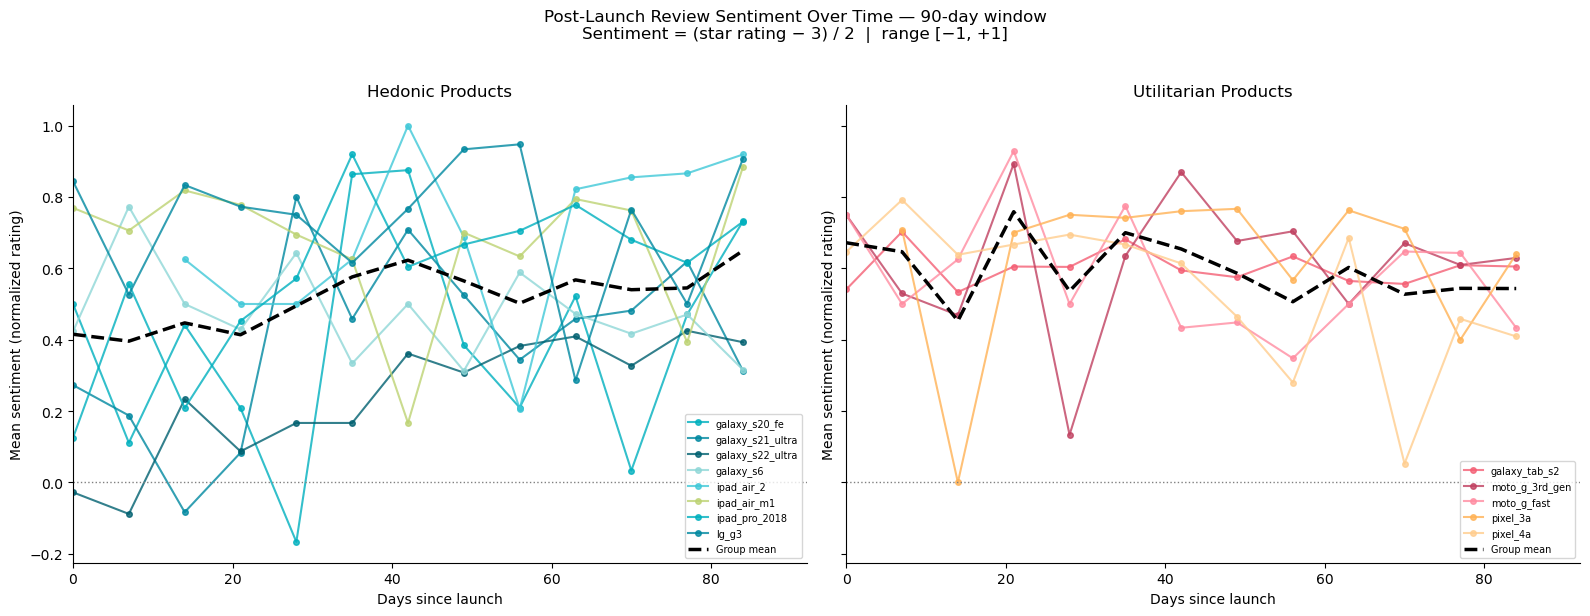

13:26:47  INFO     Temporal sentiment plot saved → figures\temporal_sentiment.png


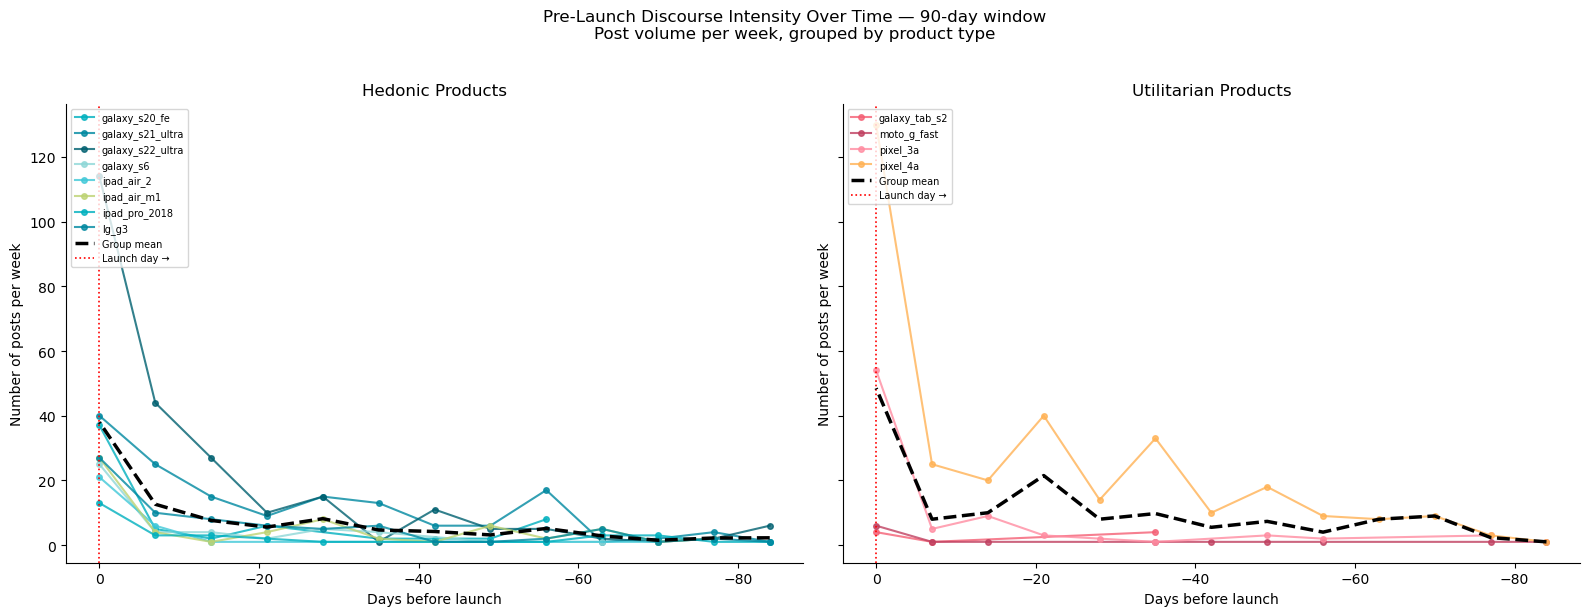

13:26:49  INFO     Pre-launch volume plot saved → figures\temporal_prelaunch_volume.png


In [ ]:
# ============================================================
# CELL B — Review Sentiment Over Time
# Uses normalized star rating (rating-3)/2 as sentiment proxy
# since gold_post_launch stores raw reviews without extracted
# sentiment scores. Normalization: 1→-1, 3→0, 5→+1.
# Consistent with RC2 (star rating as alternative DV).
# ============================================================
from google.cloud import bigquery
import matplotlib.pyplot as plt
import numpy as np

bq = bigquery.Client(project="vuthesis-llm-buzz", location="europe-west4")

q = """
    SELECT
        product_event,
        FLOOR(days_since_launch / 7) * 7      AS week_start,
        AVG((rating - 3) / 2)                  AS mean_sentiment,
        COUNT(*)                               AS n_reviews
    FROM `vuthesis-llm-buzz.thesis_dataset.gold_post_launch`
    WHERE days_since_launch BETWEEN 1 AND 90
      AND rating IS NOT NULL
    GROUP BY product_event, week_start
    ORDER BY product_event, week_start
"""

df_temporal = bq.query(q).to_dataframe()

# Map product type
ptype_map = df.drop_duplicates("event").set_index("event")["product_type"]
df_temporal["product_type"] = df_temporal["product_event"].map(ptype_map)

# Drop any events not in the main model
df_temporal = df_temporal[df_temporal["product_type"].notna()]

# ── Plot ─────────────────────────────────────────────────────
COLORS_H = ["#00b0be", "#0088a0", "#006070",
            "#8fd7d7", "#40c8d8", "#bdd373"]
COLORS_U = ["#f45f74", "#c04060", "#ff8ca1",
            "#ffb255", "#ffcd8e"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, (ptype_val, ptype_label, palette) in zip(
    axes,
    [(1, "Hedonic", COLORS_H), (0, "Utilitarian", COLORS_U)]
):
    subset = df_temporal[df_temporal["product_type"] == ptype_val]
    events = sorted(subset["product_event"].unique())

    for i, event in enumerate(events):
        ev = subset[subset["product_event"] == event].sort_values("week_start")
        ax.plot(
            ev["week_start"], ev["mean_sentiment"],
            marker="o", linewidth=1.5, markersize=4,
            label=event, color=palette[i % len(palette)], alpha=0.80,
        )

    # Group mean trend
    group_mean = (subset.groupby("week_start")["mean_sentiment"]
                  .mean().reset_index())
    ax.plot(
        group_mean["week_start"], group_mean["mean_sentiment"],
        color="black", linewidth=2.5, linestyle="--",
        label="Group mean", zorder=5,
    )

    ax.axhline(0, color="grey", linestyle=":", linewidth=1.0)
    ax.set_title(f"{ptype_label} Products", fontsize=12)
    ax.set_xlabel("Days since launch", fontsize=10)
    ax.set_ylabel("Mean sentiment (normalized rating)", fontsize=10)
    ax.legend(fontsize=7, loc="lower right")
    ax.set_xlim(0, 92)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(
    "Post-Launch Review Sentiment Over Time — 90-day window\n"
    "Sentiment = (star rating − 3) / 2  |  range [−1, +1]",
    fontsize=12, y=1.02
)
plt.tight_layout()

plot_path = FIGURES_DIR / "temporal_sentiment.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
log.info("Temporal sentiment plot saved → %s", plot_path)


# ============================================================
# CELL B2 — Pre-Launch Discourse Intensity Over Time
# No per-post sentiment available in Gold pre-launch table.
# Uses upvote-weighted post volume as discourse intensity proxy.
# Shows how discussion builds toward launch across events.
# ============================================================

q_pre = """
    SELECT
        product_event,
        FLOOR(ABS(days_to_launch) / 7) * 7    AS weeks_before_launch,
        COUNT(*)                               AS n_posts,
        AVG(upvotes)                           AS mean_upvotes,
        SUM(upvotes)                           AS total_upvotes
    FROM `vuthesis-llm-buzz.thesis_dataset.gold_pre_launch`
    WHERE days_to_launch BETWEEN -90 AND -1
    GROUP BY product_event, weeks_before_launch
    ORDER BY product_event, weeks_before_launch
"""

df_pre_temp = bq.query(q_pre).to_dataframe()

# Map product type
df_pre_temp["product_type"] = df_pre_temp["product_event"].map(ptype_map)
df_pre_temp = df_pre_temp[df_pre_temp["product_type"].notna()]

# ── Plot: two panels (hedonic / utilitarian) ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, (ptype_val, ptype_label, palette) in zip(
    axes,
    [(1, "Hedonic", COLORS_H), (0, "Utilitarian", COLORS_U)]
):
    subset = df_pre_temp[df_pre_temp["product_type"] == ptype_val]
    events = sorted(subset["product_event"].unique())

    for i, event in enumerate(events):
        ev = (subset[subset["product_event"] == event]
              .sort_values("weeks_before_launch", ascending=False))
        # X axis: weeks_before_launch → invert so time runs left→right
        x_vals = ev["weeks_before_launch"] * -1  # e.g. -84 → 84 days before
        ax.plot(
            x_vals, ev["n_posts"],
            marker="o", linewidth=1.5, markersize=4,
            label=event, color=palette[i % len(palette)], alpha=0.80,
        )

    # Group mean
    group_mean = (subset.groupby("weeks_before_launch")["n_posts"]
                  .mean().reset_index()
                  .sort_values("weeks_before_launch", ascending=False))
    ax.plot(
        group_mean["weeks_before_launch"] * -1,
        group_mean["n_posts"],
        color="black", linewidth=2.5, linestyle="--",
        label="Group mean", zorder=5,
    )

    ax.axvline(0, color="red", linestyle=":", linewidth=1.2,
               label="Launch day →")
    ax.set_title(f"{ptype_label} Products", fontsize=12)
    ax.set_xlabel("Days before launch", fontsize=10)
    ax.set_ylabel("Number of posts per week", fontsize=10)
    ax.legend(fontsize=7, loc="upper left")
    ax.invert_xaxis()  # Left = 90 days before, right = launch
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(
    "Pre-Launch Discourse Intensity Over Time — 90-day window\n"
    "Post volume per week, grouped by product type",
    fontsize=12, y=1.02
)
plt.tight_layout()

plot_path = FIGURES_DIR / "temporal_prelaunch_volume.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
log.info("Pre-launch volume plot saved → %s", plot_path)

In [ ]:
# ============================================================
# CELL C — Per-IV Models with Product Type Interaction
# Three stripped-down specs, one per IV, each with its own
# IV × ProductType interaction. HC3 robust SEs throughout.
# Grouped H/U descriptives printed alongside each model.
# ============================================================

CONTROLS  = "pre_launch_volume_z + post_review_count_z"
FIXED_EFF = "C(feature) + C(brand)"

IV_SPECS = {
    "H1 — Anticipatory Sentiment": {
        "iv":        "sentiment_IV1_c",
        "raw_col":   "sentiment_IV1",
        "formula":   f"""
            post_sentiment_DV ~
                sentiment_IV1_c + product_type +
                sentiment_IV1_c:product_type +
                {FIXED_EFF} + {CONTROLS}
        """,
    },
    "H2 — Feature Expectation Intensity": {
        "iv":        "pre_expect_score_IV2_c",
        "raw_col":   "pre_expect_score_IV2",
        "formula":   f"""
            post_sentiment_DV ~
                pre_expect_score_IV2_c + product_type +
                pre_expect_score_IV2_c:product_type +
                {FIXED_EFF} + {CONTROLS}
        """,
    },
    "H3 — Competitor Mention Frequency": {
        "iv":        "competitor_freq_IV3_c",
        "raw_col":   "competitor_freq_IV3",
        "formula":   f"""
            post_sentiment_DV ~
                competitor_freq_IV3_c + product_type +
                competitor_freq_IV3_c:product_type +
                {FIXED_EFF} + {CONTROLS}
        """,
    },
}

for title, spec in IV_SPECS.items():
    print(f"\n{'═'*60}")
    print(f"  {title}")
    print(f"{'═'*60}")

    # ── Grouped descriptives ─────────────────────────────────
    print(f"\n  IV descriptives by product type:")
    desc = (df.groupby("product_type")[spec["raw_col"]]
            .agg(["mean", "std", "min", "max"]).round(4))
    desc.index = desc.index.map({0: "utilitarian", 1: "hedonic"})
    print(desc.to_string())

    print(f"\n  DV descriptives by product type:")
    dv_desc = (df.groupby("product_type")["post_sentiment_DV"]
               .agg(["mean", "std", "min", "max"]).round(4))
    dv_desc.index = dv_desc.index.map({0: "utilitarian", 1: "hedonic"})
    print(dv_desc.to_string())

    # ── Model ────────────────────────────────────────────────
    m = smf.ols(formula=spec["formula"], data=df).fit(cov_type="HC3")

    iv_col   = spec["iv"]
    int_col  = f"{iv_col}:product_type"

    print(f"\n  Model results (HC3):")
    print(f"  {'Term':<40} {'b':>8} {'SE':>8} {'p':>8}")
    print(f"  {'─'*56}")
    for term in [iv_col, "product_type", int_col]:
        b   = m.params.get(term, np.nan)
        se  = m.bse.get(term, np.nan)
        p   = m.pvalues.get(term, np.nan)
        sig = " *" if p < 0.05 else " ." if p < 0.10 else "  "
        print(f"  {term:<40} {b:>8.4f} {se:>8.4f} {p:>8.4f}{sig}")

    print(f"\n  Adj. R² = {m.rsquared_adj:.4f}  |  "
          f"AIC = {m.aic:.2f}  |  N = {int(m.nobs)}")

print("\n  * p<.05   . p<.10")


════════════════════════════════════════════════════════════
  H1 — Anticipatory Sentiment
════════════════════════════════════════════════════════════

  IV descriptives by product type:
                mean     std     min     max
product_type                                
utilitarian   0.0490  0.0612 -0.0372  0.1353
hedonic       0.0866  0.0873 -0.0609  0.2120

  DV descriptives by product type:
                mean     std     min     max
product_type                                
utilitarian   0.5123  0.1747  0.0217  0.7658
hedonic       0.2684  0.3609 -0.5700  0.8086

  Model results (HC3):
  Term                                            b       SE        p
  ────────────────────────────────────────────────────────
  sentiment_IV1_c                           -1.6029   3.8988   0.6810  
  product_type                              -0.8692   1.4915   0.5600  
  sentiment_IV1_c:product_type               4.2368   4.7448   0.3719  

  Adj. R² = 0.4219  |  AIC = 12.86  |  N = 52

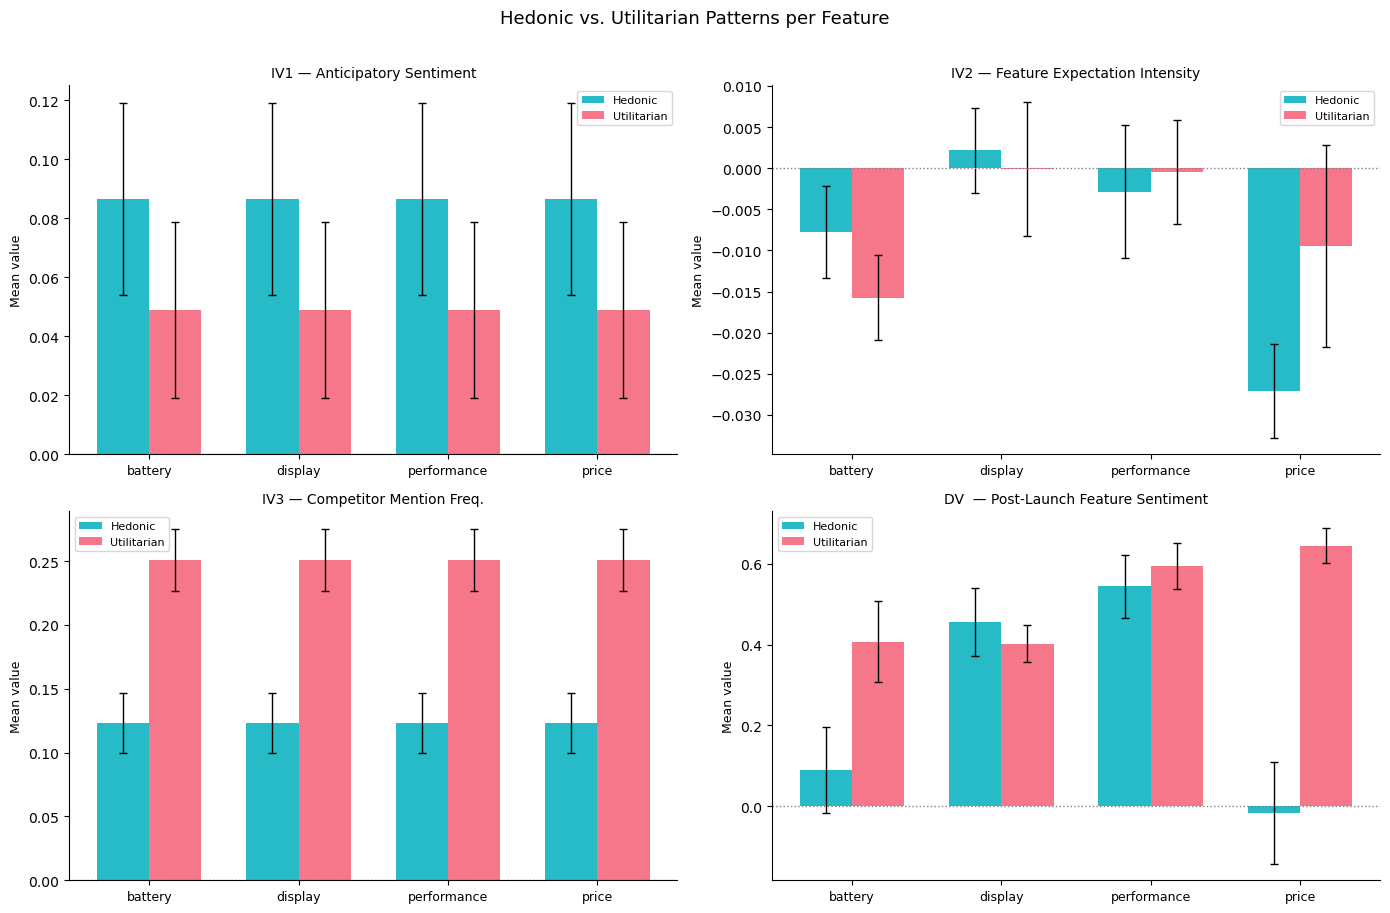

13:22:49  INFO     H/U patterns plot saved → figures\hu_patterns_per_feature.png


In [ ]:
# ============================================================
# CELL D — H/U Patterns Per Feature
# Bar charts: mean IV and DV per feature, split by product type
# ============================================================

PLOT_VARS = {
    "sentiment_IV1":        "IV1 — Anticipatory Sentiment",
    "pre_expect_score_IV2": "IV2 — Feature Expectation Intensity",
    "competitor_freq_IV3":  "IV3 — Competitor Mention Freq.",
    "post_sentiment_DV":    "DV  — Post-Launch Feature Sentiment",
}

features     = ["battery", "display", "performance", "price"]
x            = np.arange(len(features))
width        = 0.35
colors       = {"hedonic": "#00b0be", "utilitarian": "#f45f74"}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes      = axes.flatten()

for ax, (col, label) in zip(axes, PLOT_VARS.items()):
    for i, (ptype_val, ptype_label) in enumerate(
        [(1, "hedonic"), (0, "utilitarian")]
    ):
        vals = (df[df["product_type"] == ptype_val]
                .groupby("feature")[col].mean()
                .reindex(features))
        errs = (df[df["product_type"] == ptype_val]
                .groupby("feature")[col].sem()
                .reindex(features))
        offset = (i - 0.5) * width
        ax.bar(
            x + offset, vals, width,
            label=ptype_label.capitalize(),
            color=colors[ptype_label], alpha=0.85,
            yerr=errs, capsize=3, error_kw={"linewidth": 1},
        )

    ax.axhline(0, color="grey", linestyle=":", linewidth=1.0)
    ax.set_title(label, fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels(features, fontsize=9)
    ax.set_ylabel("Mean value", fontsize=9)
    ax.legend(fontsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig.suptitle(
    "Hedonic vs. Utilitarian Patterns per Feature",
    fontsize=13, y=1.01
)
plt.tight_layout()

plot_path = FIGURES_DIR / "hu_patterns_per_feature.png"
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()
log.info("H/U patterns plot saved → %s", plot_path)

In [ ]:
# ============================================================
# CELL E — Two-Model Structure
# Model 1 (Main):      conservative, brand FEs included
# Model 2 (Secondary): brand-as-product-type, no brand FEs
#
# Theoretical justification for Model 2:
#   Brand identity is collinear with product_type in this sample
#   (Apple/LG=hedonic, Motorola/Google=utilitarian). Brand FEs
#   may over-control by absorbing variance product_type should
#   capture. Model 2 treats brand as part of the H/U construct.
# ============================================================

formula_m1 = """
    post_sentiment_DV ~
        sentiment_IV1_c +
        pre_expect_score_IV2_c +
        competitor_freq_IV3_c +
        product_type +
        pre_expect_score_IV2_c:product_type +
        C(feature) + C(brand) +
        pre_launch_volume_z + post_review_count_z
"""

formula_m2 = """
    post_sentiment_DV ~
        sentiment_IV1_c +
        pre_expect_score_IV2_c +
        competitor_freq_IV3_c +
        product_type +
        pre_expect_score_IV2_c:product_type +
        C(feature) +
        pre_launch_volume_z + post_review_count_z
"""

m1 = smf.ols(formula=formula_m1, data=df).fit(cov_type="HC3")
m2 = smf.ols(formula=formula_m2, data=df).fit(cov_type="HC3")

HYP_TERMS = [
    ("H1  IV1 → DV",        "sentiment_IV1_c"),
    ("H2  IV2 → DV",        "pre_expect_score_IV2_c"),
    ("H3  IV3 → DV",        "competitor_freq_IV3_c"),
    ("    ProductType",      "product_type"),
    ("H4b IV2 × type",       "pre_expect_score_IV2_c:product_type"),
]

print(f"\n{'═'*66}")
print(f"  {'Term':<28} {'Model 1 (brand FE)':>18} {'Model 2 (no brand FE)':>18}")
print(f"  {'':28} {'b':>8} {'p':>8}   {'b':>8} {'p':>8}")
print(f"{'═'*66}")

for label, term in HYP_TERMS:
    b1  = m1.params.get(term, np.nan)
    p1  = m1.pvalues.get(term, np.nan)
    b2  = m2.params.get(term, np.nan)
    p2  = m2.pvalues.get(term, np.nan)
    s1  = " *" if p1 < 0.05 else " ." if p1 < 0.10 else "  "
    s2  = " *" if p2 < 0.05 else " ." if p2 < 0.10 else "  "
    print(f"  {label:<28} {b1:>8.4f} {p1:>7.4f}{s1}   {b2:>8.4f} {p2:>7.4f}{s2}")

print(f"{'─'*66}")
print(f"  {'Adj. R²':<28} {m1.rsquared_adj:>16.4f}   {m2.rsquared_adj:>16.4f}")
print(f"  {'AIC':<28} {m1.aic:>16.2f}   {m2.aic:>16.2f}")
print(f"  {'N':<28} {int(m1.nobs):>16}   {int(m2.nobs):>16}")
print(f"  {'Cond. number':<28} "
      f"{np.linalg.cond(m1.model.exog):>16.1f}   "
      f"{np.linalg.cond(m2.model.exog):>16.1f}")
print(f"\n  * p<.05   . p<.10")

# ── Save both model summaries ─────────────────────────────────
pd.DataFrame({
    "term":  [t for _, t in HYP_TERMS],
    "b_m1":  [m1.params.get(t, np.nan)  for _, t in HYP_TERMS],
    "p_m1":  [m1.pvalues.get(t, np.nan) for _, t in HYP_TERMS],
    "b_m2":  [m2.params.get(t, np.nan)  for _, t in HYP_TERMS],
    "p_m2":  [m2.pvalues.get(t, np.nan) for _, t in HYP_TERMS],
}).to_csv(RESULTS_DIR / "two_model_comparison.csv", index=False)

log.info("Two-model comparison saved → results/two_model_comparison.csv")

13:23:52  INFO     Two-model comparison saved → results/two_model_comparison.csv



══════════════════════════════════════════════════════════════════
  Term                         Model 1 (brand FE) Model 2 (no brand FE)
                                      b        p          b        p
══════════════════════════════════════════════════════════════════
  H1  IV1 → DV                   2.0626  0.1059       1.7278  0.0162 *
  H2  IV2 → DV                  -7.6100  0.1503      -9.2210  0.0420 *
  H3  IV3 → DV                  -0.5466  0.8419       0.6107  0.3909  
      ProductType               -1.1121  0.5316      -0.2879  0.0239 *
  H4b IV2 × type                 9.5512  0.0579 .     9.7365  0.0290 *
──────────────────────────────────────────────────────────────────
  Adj. R²                                0.4291             0.4364
  AIC                                     13.47              10.14
  N                                          52                 52
  Cond. number                            251.6              210.4

  * p<.05   . p<.10


In [ ]:
# ============================================================
# CELL F — IV3b (In-Brand Frequency) Standalone Exploratory
# Mean-centered IV3b as alternative competitive discourse
# measure. Exploratory only — not in main model.
# Tests whether in-brand self-referencing predicts DV
# differently from cross-brand competitor mentions (IV3).
# ============================================================

# Ensure mean-centered version exists
df["inbrand_freq_IV3b_c"] = (
    df["inbrand_freq_IV3b"] - df["inbrand_freq_IV3b"].mean()
)

FORMULA_IV3B = """
    post_sentiment_DV ~
        sentiment_IV1_c +
        pre_expect_score_IV2_c +
        inbrand_freq_IV3b_c +
        product_type +
        pre_expect_score_IV2_c:product_type +
        C(feature) + C(brand) +
        pre_launch_volume_z + post_review_count_z
"""

# Note: post_review_count_z dropped due to collinearity with IV3b
# (r=-.84). Using pre_launch_volume_z only as control.
FORMULA_IV3B_CLEAN = """
    post_sentiment_DV ~
        sentiment_IV1_c +
        pre_expect_score_IV2_c +
        inbrand_freq_IV3b_c +
        product_type +
        pre_expect_score_IV2_c:product_type +
        C(feature) + C(brand) +
        pre_launch_volume_z
"""

m_iv3b       = smf.ols(formula=FORMULA_IV3B,       data=df).fit(cov_type="HC3")
m_iv3b_clean = smf.ols(formula=FORMULA_IV3B_CLEAN, data=df).fit(cov_type="HC3")

# ── IV3 vs IV3b side-by-side ─────────────────────────────────
FORMULA_IV3 = """
    post_sentiment_DV ~
        sentiment_IV1_c +
        pre_expect_score_IV2_c +
        competitor_freq_IV3_c +
        product_type +
        pre_expect_score_IV2_c:product_type +
        C(feature) + C(brand) +
        pre_launch_volume_z + post_review_count_z
"""
m_iv3 = smf.ols(formula=FORMULA_IV3, data=df).fit(cov_type="HC3")

print("── IV3b descriptives ────────────────────────────────────")
print(df.groupby("product_type")["inbrand_freq_IV3b"]
      .agg(["mean", "std", "min", "max"]).round(4)
      .rename(index={0: "utilitarian", 1: "hedonic"}).to_string())

print("\n── IV3 vs IV3b: correlation with DV ────────────────────")
print(df[["competitor_freq_IV3", "inbrand_freq_IV3b",
          "post_sentiment_DV"]].corr().round(3).to_string())

COMPARE_TERMS = [
    ("H1  IV1",    "sentiment_IV1_c"),
    ("H2  IV2",    "pre_expect_score_IV2_c"),
    ("IV3 / IV3b", "competitor_freq_IV3_c"),
    ("H4b IV2×type", "pre_expect_score_IV2_c:product_type"),
]

print(f"\n── IV3 vs IV3b model comparison (HC3) ──────────────────")
print(f"  {'Term':<22} {'IV3 b':>8} {'IV3 p':>8}   "
      f"{'IV3b b':>8} {'IV3b p':>8}   {'IV3b* b':>8} {'IV3b* p':>8}")
print(f"  {'─'*78}")

for label, term in COMPARE_TERMS:
    iv3_term  = term
    iv3b_term = term.replace("competitor_freq_IV3_c", "inbrand_freq_IV3b_c")

    b3   = m_iv3.params .get(iv3_term,  np.nan)
    p3   = m_iv3.pvalues.get(iv3_term,  np.nan)
    b3b  = m_iv3b.params .get(iv3b_term, np.nan)
    p3b  = m_iv3b.pvalues.get(iv3b_term, np.nan)
    b3bc = m_iv3b_clean.params .get(iv3b_term, np.nan)
    p3bc = m_iv3b_clean.pvalues.get(iv3b_term, np.nan)

    s3   = " *" if p3   < 0.05 else " ." if p3   < 0.10 else "  "
    s3b  = " *" if p3b  < 0.05 else " ." if p3b  < 0.10 else "  "
    s3bc = " *" if p3bc < 0.05 else " ." if p3bc < 0.10 else "  "

    print(f"  {label:<22} {b3:>8.4f} {p3:>7.4f}{s3}   "
          f"{b3b:>8.4f} {p3b:>7.4f}{s3b}   "
          f"{b3bc:>8.4f} {p3bc:>7.4f}{s3bc}")

print(f"\n  {'─'*78}")
print(f"  {'Adj. R²':<22} {m_iv3.rsquared_adj:>16.4f}   "
      f"{m_iv3b.rsquared_adj:>16.4f}   {m_iv3b_clean.rsquared_adj:>16.4f}")
print(f"  {'AIC':<22} {m_iv3.aic:>16.2f}   "
      f"{m_iv3b.aic:>16.2f}   {m_iv3b_clean.aic:>16.2f}")
print(f"\n  IV3 = cross-brand competitor freq  "
      f"| IV3b = in-brand self-reference freq")
print(f"  IV3b* = IV3b without post_review_count_z (collinearity correction)")
print(f"\n  * p<.05   . p<.10")

── IV3b descriptives ────────────────────────────────────
                mean     std    min    max
product_type                              
utilitarian   0.9396  0.0401  0.866  0.974
hedonic       0.9588  0.0138  0.942  0.986

── IV3 vs IV3b: correlation with DV ────────────────────
                     competitor_freq_IV3  inbrand_freq_IV3b  post_sentiment_DV
competitor_freq_IV3                1.000             -0.434              0.189
inbrand_freq_IV3b                 -0.434              1.000              0.115
post_sentiment_DV                  0.189              0.115              1.000

── IV3 vs IV3b model comparison (HC3) ──────────────────
  Term                      IV3 b    IV3 p     IV3b b   IV3b p    IV3b* b  IV3b* p
  ──────────────────────────────────────────────────────────────────────────────
  H1  IV1                  2.0626  0.1059       1.9135  0.1180       1.9695  0.1109  
  H2  IV2                 -7.6100  0.1503      -7.2077  0.1684      -6.5910  0.1949  
  

In [ ]:
# ============================================================
# CELL G — Exploratory: Feature & Competitor Mentions
#           → Post-Launch Reception
#
# Explores whether pre-launch feature mention
# rates and competitor mention patterns (cross + in-brand)
# predict post-launch reception — treating mention rate as a
# standalone signal separate from sentiment direction.
#
# Three exploratory models:
#   E1: mention rates only (feature salience as predictors)
#   E2: mention rates + competitor discourse
#   E3: full pre-launch discourse profile
# ============================================================

# Ensure mention_rate_IV2_c exists
if "mention_rate_IV2_c" not in df.columns:
    df["mention_rate_IV2_c"] = (
        df["mention_rate_IV2"] - df["mention_rate_IV2"].mean()
    )

FORMULA_E1 = """
    post_sentiment_DV ~
        mention_rate_IV2_c +
        product_type +
        mention_rate_IV2_c:product_type +
        C(feature) + C(brand) +
        pre_launch_volume_z + post_review_count_z
"""

FORMULA_E2 = """
    post_sentiment_DV ~
        mention_rate_IV2_c +
        competitor_freq_IV3_c +
        product_type +
        mention_rate_IV2_c:product_type +
        competitor_freq_IV3_c:product_type +
        C(feature) + C(brand) +
        pre_launch_volume_z + post_review_count_z
"""

FORMULA_E3 = """
    post_sentiment_DV ~
        sentiment_IV1_c +
        mention_rate_IV2_c +
        competitor_freq_IV3_c +
        inbrand_freq_IV3b_c +
        product_type +
        mention_rate_IV2_c:product_type +
        C(feature) + C(brand) +
        pre_launch_volume_z
"""

m_e1 = smf.ols(formula=FORMULA_E1, data=df).fit(cov_type="HC3")
m_e2 = smf.ols(formula=FORMULA_E2, data=df).fit(cov_type="HC3")
m_e3 = smf.ols(formula=FORMULA_E3, data=df).fit(cov_type="HC3")

EXPLORE_TERMS = [
    ("Mention rate (IV2 alt)",   "mention_rate_IV2_c"),
    ("IV1 sentiment",            "sentiment_IV1_c"),
    ("IV3 competitor freq",      "competitor_freq_IV3_c"),
    ("IV3b in-brand freq",       "inbrand_freq_IV3b_c"),
    ("ProductType",              "product_type"),
    ("MentionRate × type",       "mention_rate_IV2_c:product_type"),
    ("IV3 × type",               "competitor_freq_IV3_c:product_type"),
]

print("── Exploratory: pre-launch discourse profile → DV ───────")
print(f"  {'Term':<28} {'E1 b':>8} {'E1 p':>7}   "
      f"{'E2 b':>8} {'E2 p':>7}   {'E3 b':>8} {'E3 p':>7}")
print(f"  {'─'*72}")

for label, term in EXPLORE_TERMS:
    vals = []
    for m in [m_e1, m_e2, m_e3]:
        b = m.params .get(term, np.nan)
        p = m.pvalues.get(term, np.nan)
        s = " *" if p < 0.05 else " ." if p < 0.10 else "  "
        vals.append((b, p, s))
    print(f"  {label:<28} "
          f"{vals[0][0]:>8.4f} {vals[0][1]:>6.4f}{vals[0][2]}   "
          f"{vals[1][0]:>8.4f} {vals[1][1]:>6.4f}{vals[1][2]}   "
          f"{vals[2][0]:>8.4f} {vals[2][1]:>6.4f}{vals[2][2]}")

print(f"\n  {'─'*72}")
for label, m in [("E1", m_e1), ("E2", m_e2), ("E3", m_e3)]:
    print(f"  {label}  Adj.R²={m.rsquared_adj:.4f}  "
          f"AIC={m.aic:.2f}  N={int(m.nobs)}")

print(f"\n  E1: feature salience only")
print(f"  E2: feature salience + competitor discourse")
print(f"  E3: full discourse profile (all pre-launch signals)")
print(f"\n  * p<.05   . p<.10")

# ── Correlation: all pre-launch signals vs DV ────────────────
print("\n── Correlation: all pre-launch signals vs DV ───────────")
signal_cols = [
    "sentiment_IV1",
    "mention_rate_IV2",
    "pre_expect_score_IV2",
    "competitor_freq_IV3",
    "inbrand_freq_IV3b",
    "post_sentiment_DV",
]
print(df[signal_cols].corr().round(3).to_string())

── Exploratory: pre-launch discourse profile → DV ───────
  Term                             E1 b    E1 p       E2 b    E2 p       E3 b    E3 p
  ────────────────────────────────────────────────────────────────────────
  Mention rate (IV2 alt)         1.5466 0.5033       2.2473 0.4593       1.6064 0.5405  
  IV1 sentiment                     nan    nan          nan    nan       1.4461 0.3140  
  IV3 competitor freq               nan    nan      -3.3344 0.3916       2.9427 0.3394  
  IV3b in-brand freq                nan    nan          nan    nan       8.2110 0.2221  
  ProductType                   -0.0691 0.9576      -1.0463 0.6477      -0.1654 0.7712  
  MentionRate × type            -0.3253 0.9029      -0.7832 0.8126      -0.2043 0.9410  
  IV3 × type                        nan    nan       3.6828 0.5731          nan    nan  

  ────────────────────────────────────────────────────────────────────────
  E1  Adj.R²=0.3739  AIC=17.01  N=52
  E2  Adj.R²=0.3534  AIC=19.95  N=52
  E3  Ad

# Summary

## Data and Sample
- 10 product launch events (6 hedonic, 4 utilitarian) - 40 observations in total
- one row per product x feature combination (4 features per event: battery, price, performance, display)
- pre-launch data taken from Reddit (90-day window)
- post-launch data from Amazon reviews (90-day window after launch) (UCSD Amazon Reviews 2023 dataset)

## Variables
| Role | Variable | Description |
|------|----------|-------------|
| DV | `post_sentiment_DV` | Mean LLM-extracted feature-level sentiment from post-launch reviews (-1 to 1) |
| IV1 | `sentiment_IV1` | Mean overall anticipatory sentiment across pre-launch Reddit posts - event-level |
| IV2 | `pre_expect_score_IV2` | Feature expectation intensity: sentiment-weighted mention rate per feature - feature-level |
| IV3 | `competitor_freq_IV3` | Proportion of pre-launch posts containing a competitor co-mention — event-level |
| Moderator | `product_type` | 1 = hedonic (Apple, Samsung flagships), 0 = utilitarian (Motorola, Google Pixel budget) |
| Controls | `pre_launch_volume`, `post_review_count` | Event-level volume controls |
| Fixed effects | `C(feature)`, `C(brand)` | Feature and brand dummies |

All IVs are mean-centered prior to constructing interaction terms

### Dataframe example
 | event          | brand   | feature     | IV1    | IV2     | IV3   | DV    |
 |------|----------|-------------|-------------|-----------|-------|---------|
 | ipad_pro_2018  | Apple   | battery     | 0.212  | -0.002  | 0.046 | 0.207     |
 | ipad_pro_2018  | Apple   | price       | 0.212  | -0.022  | 0.046 | 0.130     |
 | ipad_pro_2018  | Apple   | performance | 0.212  |  0.033  | 0.046 | 0.677     |
 | ipad_pro_2018  | Apple   | display     | 0.212  |  0.034  | 0.046 | 0.235     |
 | galaxy_s6      | Samsung | battery     | 0.003  |  0.007  | 0.198 | -0.422  |


## Model specificatiobn
Full equation: 
DV(e,f) = β0
         + β1·IV1(e)                          [H1]
         + β2·IV2(e,f)                         [H2]
         + β3·IV3(e)                           [H3]
         + β4·ProductType(e)                   [moderator main effect]
         + β5·IV1 × ProductType               [H4a]
         + β6·IV2 × ProductType               [H4b]
         + β7·IV3 × ProductType               [H4c]
         + β8·Feature(f)                       [feature FE]
         + β9·Brand(e)                         [brand FE]
         + β10·PreLaunchVolume(e)              [control]
         + β11·PostReviewCount(e)              [control]
         + ε

where:
- e = event (product launch) f.e. ipad air 2
- f = feature f.e. battery, price, performance, display

Model fit: R² = .635, Adjusted R² = .430, N = 40, Residual df = 25

## Results
### Main model - hypothesis testing

| Hypothesis | Construct | b (raw) | std_β | p | Verdict |
|---|---|---|---|---|---|
| H1 | Anticipatory sentiment -> DV | 3.808 | 1.013 | .039 | Supported |
| H2 | Feature expectation intensity -> DV | −8.021 | −0.493 | .128 | Not supported :( |
| H3 | Competitor mention frequency -> DV | −3.049 | −0.781 | .289 | Not supported :(|
| H4a | IV1 x Product type | −0.705 | −0.187 | .710 | Not supported :( |
| H4b | IV2 x Product type | 9.544 | 0.586 | .117 | Not supported :( |
| H4c | IV3 x Product type | −0.024 | −0.006 | .974 | Not supported :( |

### Assumption checks
- Normality of residuals: Shapiro-Wilk test (test for normality on small samples) and Q-Q plot assessed; will be reporteded in appendix.
- Homoscedasticity: Breusch-Pagan test conducted; reported in appendix.
- Multicollinearity: VIF computed for all IVs and controls; all values below threshold (< 5), confirming no problematic collinearity between main effect predictors.


![Assumption Checks](figures/assumption_checks.png)

### Robustness checks (RCs)
RC1 - Sample sensitivity check - excluded the 2 lowest pre-launch volume events (galaxy tab s2 and moto g fast). Tests if IV1 and IV2 estimates are stable across the full sample or driven by noisy low-volume observations. Applies to all 3 IVs. Result: IV1 and IV2 both strenghen in effect

RC2 - Alternative DV operationalization - replace dthe LLM- extracted sentiment with the mean Amazon star ratings as the DV. Tests if the IV1 finding holds under a different & more conventional DV. Feature and brand FE drriooed in this spec cuz the DV is event-level only (aka no feature level variance). It applies to all 3 IVs. Result: IV1 replicates with opposite sign

RC3 - Alternative IV3 operationalization - replaced the competitor mention frequency (IV3), with in-brand mention frequency (IV3b) as the competitive discourse measure. Tests whether the H3 null is specific to the competitor framing or holds regardless of how competitive discourse is applied. Applies to IV3 only. Results: null holds either way

RC4 - Reduced model specification check - dropped FE entirely. Looks at the IV1 effect is genuine or an artefact of brand-level confounding. Applies to all 3 IVs, but most diagnostic for IV1. Result: IV1 becomes non-significant, flagging brand sensitivity.


![Interaction Plots](figures/interaction_plots.png)


| Specification | N | Adj. R² | IV1 p | IV2 p | IV3 p | Key observation |
|---|---|---|---|---|---|---|
| Main model | 40 | .430 | .039 | .128 | .289 | Baseline |
| RC1: Exclude 2 lowest-volume events | 32 | .560 | .012 | .016 | .175 | H1 strengthens & H2 becomes significant |
| RC2: Star rating as alternative DV | 40 | .834 | .002 | .833 | .375 | H1 holds & IV1 sign flips |
| RC3: IV3b (in-brand frequency) as IV3 | 40 | .430 | .125 | .128 | .389 | H3 null regardless of operationalization |
| RC4: Drop brand fixed effects | 40 | .422 | .625 | .146 | .312 | IV1 collapses without brand controls |


Original pre-launch data: 36459 -> cate 500
Post-launch data: 4329 -> cate 200

Intrebari:

1. Ce fac cu p-values? 

2. Sa creez si cells pt stocarea data-ului local pt easier replication?

3. Atasez the thesis word in assignmentul de pe canvas chiar daca n am mai lucrat la el?

4. Sa creez un table cu literatura din diversele areas pe care le acopar si sa arat cu ticks and Xs ce nu acopera, ca sa evidentiez literature gap-ul?


In [ ]:

import os
for root, dirs, files in os.walk('.'):
    # skip hidden and cache folders
    dirs[:] = [d for d in dirs if not d.startswith('.') and d not in ['__pycache__','node_modules','.ipynb_checkpoints']]
    level = root.replace('.', '').count(os.sep)
    print('  ' * level + os.path.basename(root) + '/')
    for f in files:
        print('  ' * (level + 1) + f)

./
  .gitattributes
  brand_taxonomy.py
  events.csv
  events1.csv
  final_events.csv
  gcp_test.ipynb
  llm_extraction.ipynb
  modelling.ipynb
  modelling.py
  orchestrate.ipynb
  post_launch_reviews_eda.ipynb
  preflight_check.ipynb
  pre_launch_buzz_eda.ipynb
  README.md
  semi_final_events.csv
  test_brand_classifier.ipynb
  validation.py
  data/
    stage6_distributions.png
    star_ratings.csv
    thesis_extracted.csv
    thesis_modelling.csv
    variable_distributions.png
    cache/
      checkpoint_post.json
      checkpoint_pre.json
      gold_post_launch.parquet
      gold_pre_launch.parquet
    extracted/
      thesis_extracted.csv
      thesis_extracted1.csv
      variable_distributions.png
    validation/
      kappa_results.csv
      validation_sample.csv
  figures/
    assumption_checks.png
    hu_patterns_per_feature.png
    interaction_plots.png
    temporal_prelaunch_volume.png
    temporal_sentiment.png
  logs/
    orchestrate_20260521_193530.log
    orchestrate_2026

In [ ]:
# ============================================================
# CELL — Progressive Model Comparison 
#
# All models: no brand FEs (M2 secondary model structure),
# feature FEs + standardized controls throughout.
# HC3 robust SEs applied to all specifications.
#
# Model progression:
#   Spec 1: IVs + feature FE (no controls, no moderator)
#   Spec 2: IVs + feature FE + controls
#   Spec 3: Spec 2 + ProductType main effect
#   Spec 4: Spec 3 + IV1 × ProductType
#   Spec 5: Spec 3 + IV2 × ProductType 
#   Spec 6: Spec 3 + IV3 × ProductType
#   Spec 7: Spec 3 + all three interactions
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from pathlib import Path

RESULTS_DIR = Path(r"C:\Users\User\Desktop\VU\Thesis\Code\LLM-prelaunch-buzz-postlaunch-predictor\results")
RESULTS_DIR.mkdir(exist_ok=True)

BASE_IVS      = "sentiment_IV1_c + pre_expect_score_IV2_c + competitor_freq_IV3_c"
FEATURE_FE    = "C(feature)"
CONTROLS      = "pre_launch_volume_z + post_review_count_z"
PRODUCT_TYPE  = "product_type"

FORMULAS = {
    "Spec 1\nIVs only": f"""
        post_sentiment_DV ~
            {BASE_IVS} + {FEATURE_FE}
    """,
    "Spec 2\n+ Controls": f"""
        post_sentiment_DV ~
            {BASE_IVS} + {FEATURE_FE} + {CONTROLS}
    """,
    "Spec 3\n+ ProductType": f"""
        post_sentiment_DV ~
            {BASE_IVS} + {PRODUCT_TYPE} +
            {FEATURE_FE} + {CONTROLS}
    """,
    "Spec 4\n+ IV1×Type": f"""
        post_sentiment_DV ~
            {BASE_IVS} + {PRODUCT_TYPE} +
            sentiment_IV1_c:{PRODUCT_TYPE} +
            {FEATURE_FE} + {CONTROLS}
    """,
    "Spec 5\n+ IV2×Type": f"""
        post_sentiment_DV ~
            {BASE_IVS} + {PRODUCT_TYPE} +
            pre_expect_score_IV2_c:{PRODUCT_TYPE} +
            {FEATURE_FE} + {CONTROLS}
    """,
    "Spec 6\n+ IV3×Type": f"""
        post_sentiment_DV ~
            {BASE_IVS} + {PRODUCT_TYPE} +
            competitor_freq_IV3_c:{PRODUCT_TYPE} +
            {FEATURE_FE} + {CONTROLS}
    """,
    "Spec 7\nAll interactions": f"""
        post_sentiment_DV ~
            {BASE_IVS} + {PRODUCT_TYPE} +
            sentiment_IV1_c:{PRODUCT_TYPE} +
            pre_expect_score_IV2_c:{PRODUCT_TYPE} +
            competitor_freq_IV3_c:{PRODUCT_TYPE} +
            {FEATURE_FE} + {CONTROLS}
    """,
}

# ── Fit all models ───────────────────────────────────────────
models = {
    name: smf.ols(formula=formula, data=df).fit(cov_type="HC3")
    for name, formula in FORMULAS.items()
}


# ── Table construction ───────────────────────────────────────
def fmt_coef(b, p):
    """Format coefficient with significance stars."""
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "†" if p < 0.10 else ""
    return f"{b:.3f}{stars}"

def fmt_se(se):
    return f"({se:.3f})"

# Row definitions: (display label, param key)
ROWS = [
    # ── Main effects ──────────────────────────────────────────
    ("PANEL A: Pre-Launch Signals",          None),
    ("Anticipatory Sentiment (IV1)",         "sentiment_IV1_c"),
    ("",                                     "se:sentiment_IV1_c"),
    ("Feature Expectation Intensity (IV2)",  "pre_expect_score_IV2_c"),
    ("",                                     "se:pre_expect_score_IV2_c"),
    ("Competitor Mention Freq. (IV3)",       "competitor_freq_IV3_c"),
    ("",                                     "se:competitor_freq_IV3_c"),
    # ── Moderator ─────────────────────────────────────────────
    ("PANEL B: Moderator",                   None),
    ("Product Type (hedonic=1)",             "product_type"),
    ("",                                     "se:product_type"),
    # ── Interactions ──────────────────────────────────────────
    ("PANEL C: Interactions",                None),
    ("IV1 × Product Type",                   "sentiment_IV1_c:product_type"),
    ("",                                     "se:sentiment_IV1_c:product_type"),
    ("IV2 × Product Type",                   "pre_expect_score_IV2_c:product_type"),
    ("",                                     "se:pre_expect_score_IV2_c:product_type"),
    ("IV3 × Product Type",                   "competitor_freq_IV3_c:product_type"),
    ("",                                     "se:competitor_freq_IV3_c:product_type"),
    # ── Feature FEs ───────────────────────────────────────────
    ("PANEL D: Feature Fixed Effects",       None),
    ("Display vs. Battery",                  "C(feature)[T.display]"),
    ("",                                     "se:C(feature)[T.display]"),
    ("Performance vs. Battery",              "C(feature)[T.performance]"),
    ("",                                     "se:C(feature)[T.performance]"),
    ("Price vs. Battery",                    "C(feature)[T.price]"),
    ("",                                     "se:C(feature)[T.price]"),
    # ── Controls ──────────────────────────────────────────────
    ("PANEL E: Controls",                    None),
    ("Pre-Launch Volume (std.)",             "pre_launch_volume_z"),
    ("",                                     "se:pre_launch_volume_z"),
    ("Post-Review Count (std.)",             "post_review_count_z"),
    ("",                                     "se:post_review_count_z"),
]

FIT_ROWS = [
    ("MODEL FIT",          None),
    ("R²",                 "r2"),
    ("Adj. R²",            "r2_adj"),
    ("F-statistic",        "fstat"),
    ("F p-value",          "fpval"),
    ("N",                  "nobs"),
]

col_names = list(models.keys())
table_data = {}

for label, key in ROWS + FIT_ROWS:
    row = []
    for m in models.values():
        if key is None:
            row.append("")
        elif key.startswith("se:"):
            param = key[3:]
            se = m.bse.get(param, np.nan)
            row.append("" if np.isnan(se) else fmt_se(se))
        elif key == "r2":
            row.append(f"{m.rsquared:.3f}")
        elif key == "r2_adj":
            row.append(f"{m.rsquared_adj:.3f}")
        elif key == "fstat":
            try:
                row.append(f"{m.fvalue:.3f}")
            except Exception:
                row.append("—")
        elif key == "fpval":
            try:
                row.append(f"{m.f_pvalue:.4f}")
            except Exception:
                row.append("—")
        elif key == "nobs":
            row.append(f"{int(m.nobs)}")
        else:
            b = m.params.get(key, np.nan)
            p = m.pvalues.get(key, np.nan)
            row.append("" if np.isnan(b) else fmt_coef(b, p))
    table_data[label] = row

table_df = pd.DataFrame(table_data, index=col_names).T
table_df.index.name = "Variable"


# ── Print journal-style table ─────────────────────────────────
COL_W  = 14
LABEL_W = 38

def divider(char="─"):
    print(char * (LABEL_W + COL_W * len(col_names) + 2))

print("\n")
print("Table X. OLS Regression Results — No Brand Fixed Effects (HC3 Robust Standard Errors)")
print(f"DV: Post-Launch Feature Sentiment\n")

divider("═")
# Header
header = f"{'':>{LABEL_W}}"
for name in col_names:
    short = name.split("\n")[0]
    header += f" {short:>{COL_W}}"
print(header)
subheader = f"{'':>{LABEL_W}}"
for name in col_names:
    sub = name.split("\n")[1] if "\n" in name else ""
    subheader += f" {sub:>{COL_W}}"
print(subheader)
divider("═")

for label, key in ROWS + FIT_ROWS:
    if key is None:
        # Panel header
        divider()
        print(f"  {label}")
        divider()
        continue

    row_vals = table_data.get(label, [""] * len(col_names))
    is_se = key.startswith("se:") if key else False

    if is_se:
        line = f"{'':>{LABEL_W}}"
    else:
        line = f"  {label:<{LABEL_W - 2}}"

    for val in row_vals:
        line += f" {val:>{COL_W}}"

    print(line)

divider("═")
print(f"\n  Note. Coefficients from OLS regression with HC3 heteroscedasticity-robust")
print(f"  standard errors in parentheses. Feature fixed effects included in all")
print(f"  specifications. Brand fixed effects excluded (see text). All continuous")
print(f"  independent variables are mean-centred; controls are standardized (z-scored).")
print(f"  † p < .10  * p < .05  ** p < .01  *** p < .001")


# ── Save as CSV ───────────────────────────────────────────────
table_df.to_csv(RESULTS_DIR / "table_progressive_models.csv")
log.info("Progressive model table saved → results/table_progressive_models.csv")


# ── Also print quick hypothesis summary across specs ─────────
print("\n\nHypothesis Summary Across Specifications")
divider("═")

HYP_TERMS = [
    ("H1  IV1 → DV",     "sentiment_IV1_c"),
    ("H2  IV2 → DV",     "pre_expect_score_IV2_c"),
    ("H3  IV3 → DV",     "competitor_freq_IV3_c"),
    ("H4a IV1 × type",   "sentiment_IV1_c:product_type"),
    ("H4b IV2 × type",   "pre_expect_score_IV2_c:product_type"),
    ("H4c IV3 × type",   "competitor_freq_IV3_c:product_type"),
]

print(f"  {'':25}", end="")
for name in col_names:
    short = name.split("\n")[0]
    print(f" {short:>{COL_W}}", end="")
print()
divider()

for label, term in HYP_TERMS:
    print(f"  {label:<25}", end="")
    for m in models.values():
        b = m.params.get(term, np.nan)
        p = m.pvalues.get(term, np.nan)
        if np.isnan(b):
            print(f" {'—':>{COL_W}}", end="")
        else:
            stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "†" if p < 0.10 else " n.s."
            print(f" {f'{b:.3f}{stars}':>{COL_W}}", end="")
    print()

divider("═")
print(f"  † p<.10  * p<.05  ** p<.01  *** p<.001")

16:32:19  INFO     Progressive model table saved → results/table_progressive_models.csv




Table X. OLS Regression Results — No Brand Fixed Effects (HC3 Robust Standard Errors)
DV: Post-Launch Feature Sentiment

══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
                                               Spec 1         Spec 2         Spec 3         Spec 4         Spec 5         Spec 6         Spec 7
                                             IVs only     + Controls  + ProductType     + IV1×Type     + IV2×Type     + IV3×Type All interactions
══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  PANEL A: Pre-Launch Signals
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
 

In [ ]:
# ============================================================
# CELL — Progressive Model Table: b / SE / p subcolumns
# Each specification has three explicit subcolumns.
# Models without brand FEs, HC3 throughout.
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from pathlib import Path

RESULTS_DIR = Path(
    r"C:\Users\User\Desktop\VU\Thesis\Code"
    r"\LLM-prelaunch-buzz-postlaunch-predictor\results"
)
RESULTS_DIR.mkdir(exist_ok=True)

# ── Model specs ──────────────────────────────────────────────
BASE     = "sentiment_IV1_c + pre_expect_score_IV2_c + competitor_freq_IV3_c"
FE       = "C(feature)"
CTRL     = "pre_launch_volume_z + post_review_count_z"
PT       = "product_type"

FORMULAS = {
    "Spec 1":  f"post_sentiment_DV ~ {BASE} + {FE}",
    "Spec 2":  f"post_sentiment_DV ~ {BASE} + {FE} + {CTRL}",
    "Spec 3":  f"post_sentiment_DV ~ {BASE} + {PT} + {FE} + {CTRL}",
    "Spec 4":  f"post_sentiment_DV ~ {BASE} + {PT} + sentiment_IV1_c:{PT} + {FE} + {CTRL}",
    "Spec 5":  f"post_sentiment_DV ~ {BASE} + {PT} + pre_expect_score_IV2_c:{PT} + {FE} + {CTRL}",
    "Spec 6":  f"post_sentiment_DV ~ {BASE} + {PT} + competitor_freq_IV3_c:{PT} + {FE} + {CTRL}",
    "Spec 7":  f"post_sentiment_DV ~ {BASE} + {PT} + sentiment_IV1_c:{PT} + pre_expect_score_IV2_c:{PT} + competitor_freq_IV3_c:{PT} + {FE} + {CTRL}",
}

models = {
    name: smf.ols(formula=f, data=df).fit(cov_type="HC3")
    for name, f in FORMULAS.items()
}

spec_labels = {
    "Spec 1": "IVs only",
    "Spec 2": "+ Controls",
    "Spec 3": "+ ProductType",
    "Spec 4": "+ IV1×Type",
    "Spec 5": "+ IV2×Type",
    "Spec 6": "+ IV3×Type",
    "Spec 7": "All interactions",
}

# ── Row definitions ──────────────────────────────────────────
PARAM_ROWS = [
    # label, param key, panel
    ("─── Main Effects ───────────────────────────────",   None,                                      True),
    ("Anticipatory Sentiment (IV1)",                       "sentiment_IV1_c",                         False),
    ("Feature Expectation Intensity (IV2)",                "pre_expect_score_IV2_c",                  False),
    ("Competitor Mention Freq. (IV3)",                     "competitor_freq_IV3_c",                   False),
    ("─── Moderator ─────────────────────────────────",    None,                                      True),
    ("Product Type (hedonic=1)",                           "product_type",                            False),
    ("─── Interactions ──────────────────────────────",    None,                                      True),
    ("IV1 × Product Type",                                 "sentiment_IV1_c:product_type",            False),
    ("IV2 × Product Type",                                 "pre_expect_score_IV2_c:product_type",     False),
    ("IV3 × Product Type",                                 "competitor_freq_IV3_c:product_type",      False),
    ("─── Feature Fixed Effects ─────────────────────",    None,                                      True),
    ("Display vs. Battery (ref.)",                         "C(feature)[T.display]",                   False),
    ("Performance vs. Battery (ref.)",                     "C(feature)[T.performance]",               False),
    ("Price vs. Battery (ref.)",                           "C(feature)[T.price]",                     False),
    ("─── Controls ──────────────────────────────────",    None,                                      True),
    ("Pre-Launch Volume (std.)",                           "pre_launch_volume_z",                     False),
    ("Post-Review Count (std.)",                           "post_review_count_z",                     False),
]

FIT_ROWS = [
    ("─── Model Fit ──────────────────────────────────", None,       True),
    ("R²",                                               "r2",       False),
    ("Adj. R²",                                         "r2_adj",    False),
    ("F-statistic",                                     "fstat",     False),
    ("p (F)",                                           "fpval",     False),
    ("N",                                               "nobs",      False),
]

ALL_ROWS = PARAM_ROWS + FIT_ROWS

# ── Build MultiIndex DataFrame ───────────────────────────────
spec_names = list(models.keys())

# MultiIndex: (Spec N, subcolumn)
col_tuples = []
for s in spec_names:
    col_tuples += [(s, "b"), (s, "SE"), (s, "p")]

columns    = pd.MultiIndex.from_tuples(col_tuples)
row_labels = [label for label, _, _ in ALL_ROWS]
table_df   = pd.DataFrame(index=row_labels, columns=columns, dtype=object)

def stars(p):
    if   p < 0.001: return "***"
    elif p < 0.01:  return "**"
    elif p < 0.05:  return "*"
    elif p < 0.10:  return "†"
    return ""

for label, key, is_panel in ALL_ROWS:
    for spec, m in models.items():
        if is_panel or key is None:
            table_df.loc[label, (spec, "b")]  = ""
            table_df.loc[label, (spec, "SE")] = ""
            table_df.loc[label, (spec, "p")]  = ""
            continue

        if key in ("r2", "r2_adj", "fstat", "fpval", "nobs"):
            val = {
                "r2":     f"{m.rsquared:.3f}",
                "r2_adj": f"{m.rsquared_adj:.3f}",
                "fstat":  f"{m.fvalue:.3f}"    if hasattr(m, 'fvalue')   and m.fvalue   is not None else "—",
                "fpval":  f"{m.f_pvalue:.4f}"  if hasattr(m, 'f_pvalue') and m.f_pvalue is not None else "—",
                "nobs":   f"{int(m.nobs)}",
            }.get(key, "—")
            table_df.loc[label, (spec, "b")]  = val
            table_df.loc[label, (spec, "SE")] = ""
            table_df.loc[label, (spec, "p")]  = ""
            continue

        b  = m.params.get(key, np.nan)
        se = m.bse.get(key, np.nan)
        p  = m.pvalues.get(key, np.nan)

        if np.isnan(b):
            table_df.loc[label, (spec, "b")]  = "—"
            table_df.loc[label, (spec, "SE")] = "—"
            table_df.loc[label, (spec, "p")]  = "—"
        else:
            table_df.loc[label, (spec, "b")]  = f"{b:.3f}{stars(p)}"
            table_df.loc[label, (spec, "SE")] = f"({se:.3f})"
            table_df.loc[label, (spec, "p")]  = f"{p:.3f}"


# ── Console print ─────────────────────────────────────────────
B  = 8
SE = 8
P  = 7
LW = 40

def divider(c="─"):
    print(c * (LW + (B + SE + P + 3) * len(spec_names)))

print("\n")
print("Table X. OLS Regression Results — Model Progression (No Brand Fixed Effects)")
print("           DV: Post-Launch Feature Sentiment | HC3 Robust Standard Errors\n")

divider("═")

# Spec label row
line = f"{'':>{LW}}"
for s in spec_names:
    sub = spec_labels.get(s, s)
    total_w = B + SE + P + 2
    line += f"  {sub:^{total_w}}"
print(line)

# Sub-column header row
line = f"{'':>{LW}}"
for _ in spec_names:
    line += f"  {'b':>{B}} {'SE':>{SE}} {'p':>{P}}"
print(line)

divider("═")

for label, key, is_panel in ALL_ROWS:
    if is_panel:
        print(f"\n  {label}")
        continue

    line = f"  {label:<{LW - 2}}"
    for spec in spec_names:
        b_val  = table_df.loc[label, (spec, "b")]
        se_val = table_df.loc[label, (spec, "SE")]
        p_val  = table_df.loc[label, (spec, "p")]
        line  += f"  {str(b_val):>{B}} {str(se_val):>{SE}} {str(p_val):>{P}}"
    print(line)

divider("═")
print(f"\n  Note. HC3 heteroscedasticity-robust standard errors in parentheses.")
print(f"  All IVs mean-centred; controls standardized (z-scored).")
print(f"  Feature fixed effects included in all specifications.")
print(f"  Brand fixed effects excluded throughout (see text for justification).")
print(f"  † p<.10  * p<.05  ** p<.01  *** p<.001")




Table X. OLS Regression Results — Model Progression (No Brand Fixed Effects)
           DV: Post-Launch Feature Sentiment | HC3 Robust Standard Errors

══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
                                                  IVs only                  + Controls                + ProductType               + IV1×Type                 + IV2×Type                 + IV3×Type              All interactions     
                                                 b       SE       p         b       SE       p         b       SE       p         b       SE       p         b       SE       p         b       SE       p         b       SE       p
═══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════

Saved → C:\Users\User\Desktop\VU\Thesis\Code\LLM-prelaunch-buzz-postlaunch-predictor\results\interaction_plots.png


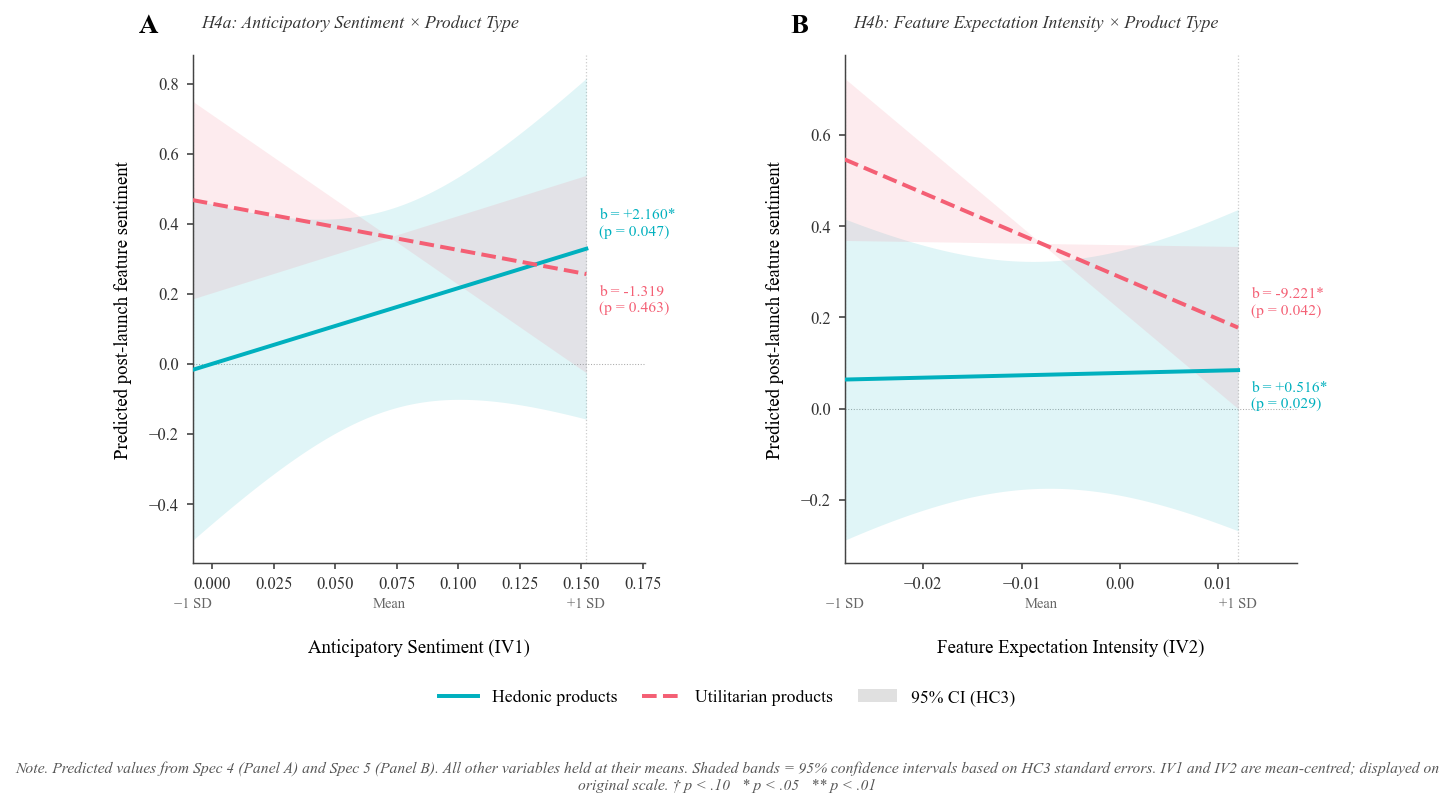

In [ ]:
# ============================================================
# interaction_plots.py
# Publication-quality marginal effects plots for thesis
#
# Panel A — H4a: IV1 (Anticipatory Sentiment) × Product Type
# Panel B — H4b: IV2 (Feature Expectation Intensity) × Product Type
#
# Requirements: pip install matplotlib numpy
# Run from project root or adjust OUTPUT_PATH below
# ============================================================

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from pathlib import Path

# ── Output path — adjust to your project structure ───────────
OUTPUT_PATH = Path(
    r"C:\Users\User\Desktop\VU\Thesis\Code"
    r"\LLM-prelaunch-buzz-postlaunch-predictor\results\interaction_plots.png"
)
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

# ── Palette ───────────────────────────────────────────────────
COL_HED  = "#00b0be"   # hedonic  — teal
COL_UTIL = "#f45f74"   # utilitarian — coral
ALPHA_CI = 0.12        # confidence band opacity

# ── Global style ──────────────────────────────────────────────
plt.rcParams.update({
    "font.family":         "serif",
    "font.serif":          ["Times New Roman", "DejaVu Serif", "serif"],
    "font.size":           10,
    "axes.spines.top":     False,
    "axes.spines.right":   False,
    "axes.grid":           False,
    "xtick.major.size":    3,
    "ytick.major.size":    3,
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,
    "figure.dpi":          150,   # screen preview
    "savefig.dpi":         300,   # print quality
    "savefig.bbox":        "tight",
    "savefig.facecolor":   "white",
    "axes.facecolor":      "white",
    "figure.facecolor":    "white",
})


# ─────────────────────────────────────────────────────────────
# Model parameters
# Source: Spec 4 (Panel A) and Spec 5 (Panel B)
# HC3 robust SEs, N=52, all IVs mean-centred
# Controls held at 0 (= their means when z-scored)
# ─────────────────────────────────────────────────────────────

DV_MEAN = 0.362      # grand mean of DV (anchors predicted values)

# ── Panel A — Spec 4: IV1 × ProductType ──────────────────────
A = dict(
    b_IV      = -1.319,   # IV1 main effect
    se_IV     =  1.797,
    b_PT      = -0.206,   # ProductType main effect
    se_PT     =  0.146,
    b_int     =  3.479,   # IV1 × ProductType
    se_int    =  1.751,
    p_int     =  0.047,   # p for interaction (= hedonic slope p)
    p_main    =  0.463,   # p for IV1 main (= utilitarian slope p)
    iv_mean   =  0.072,   # IV1 sample mean (for x-axis centering)
    iv_sd     =  0.080,   # IV1 sample SD
    x_label   = "Anticipatory Sentiment (IV1)",
    panel_lbl = "A",
    title     = "H4a: Anticipatory Sentiment × Product Type",
)

# ── Panel B — Spec 5: IV2 × ProductType ──────────────────────
B = dict(
    b_IV      = -9.221,   # IV2 main effect
    se_IV     =  4.535,
    b_PT      = -0.288,   # ProductType main effect
    se_PT     =  0.127,
    b_int     =  9.737,   # IV2 × ProductType
    se_int    =  4.461,
    p_int     =  0.029,   # hedonic slope p (interaction term)
    p_main    =  0.042,   # utilitarian slope p (IV2 main in Spec 5)
    iv_mean   = -0.008,   # IV2 sample mean
    iv_sd     =  0.020,   # IV2 sample SD
    x_label   = "Feature Expectation Intensity (IV2)",
    panel_lbl = "B",
    title     = "H4b: Feature Expectation Intensity × Product Type",
)


# ─────────────────────────────────────────────────────────────
# Prediction functions
# ─────────────────────────────────────────────────────────────

def make_predictions(params):
    """
    Compute predicted DV and 95% CI bands for hedonic and utilitarian.
    Returns dict with arrays for plotting.
    """
    p      = params
    x      = np.linspace(p["iv_mean"] - p["iv_sd"],
                         p["iv_mean"] + p["iv_sd"], 300)
    x_c    = x - p["iv_mean"]   # mean-centred for formula

    # Predicted values
    # ŷ = DV_MEAN + b_IV*x_c + b_PT*PT + b_int*x_c*PT
    hed    = DV_MEAN + p["b_IV"] * x_c + p["b_PT"] * 1 + p["b_int"] * x_c * 1
    util   = DV_MEAN + p["b_IV"] * x_c

    # Implied slopes for annotation
    slope_hed  = p["b_IV"] + p["b_int"]
    slope_util = p["b_IV"]

    # SE of predicted value (dominant term: slope SE × |x_c|)
    # Conservative approximation assuming zero covariance between b_IV and b_int
    se_hed_slope  = np.sqrt(p["se_IV"]**2 + p["se_int"]**2)
    se_util_slope = p["se_IV"]
    base_hed      = p["se_PT"]   # uncertainty from ProductType offset

    ci_hed_lo  = hed  - 1.96 * np.sqrt((se_hed_slope  * x_c)**2 + base_hed**2)
    ci_hed_hi  = hed  + 1.96 * np.sqrt((se_hed_slope  * x_c)**2 + base_hed**2)
    ci_util_lo = util - 1.96 * np.abs(se_util_slope * x_c)
    ci_util_hi = util + 1.96 * np.abs(se_util_slope * x_c)

    return dict(
        x=x, x_c=x_c,
        hed=hed, util=util,
        ci_hed_lo=ci_hed_lo, ci_hed_hi=ci_hed_hi,
        ci_util_lo=ci_util_lo, ci_util_hi=ci_util_hi,
        slope_hed=slope_hed, slope_util=slope_util,
    )


def stars(p):
    if   p < 0.001: return "***"
    elif p < 0.01:  return "**"
    elif p < 0.05:  return "*"
    elif p < 0.10:  return "†"
    return ""


# ─────────────────────────────────────────────────────────────
# Panel drawing function
# ─────────────────────────────────────────────────────────────

def draw_panel(ax, params, pred):
    p = params

    # Confidence bands
    ax.fill_between(pred["x"], pred["ci_hed_lo"],  pred["ci_hed_hi"],
                    color=COL_HED,  alpha=ALPHA_CI, linewidth=0, zorder=1)
    ax.fill_between(pred["x"], pred["ci_util_lo"], pred["ci_util_hi"],
                    color=COL_UTIL, alpha=ALPHA_CI, linewidth=0, zorder=1)

    # Prediction lines
    ax.plot(pred["x"], pred["hed"],  color=COL_HED,  linewidth=1.9,
            linestyle="-",  zorder=3, label="Hedonic")
    ax.plot(pred["x"], pred["util"], color=COL_UTIL, linewidth=1.9,
            linestyle="--", zorder=3, label="Utilitarian")

    # ±1 SD and zero reference lines
    for xv in [p["iv_mean"] - p["iv_sd"], p["iv_mean"] + p["iv_sd"]]:
        ax.axvline(xv, color="#cccccc", linewidth=0.6, linestyle=":", zorder=0)
    ax.axhline(0, color="#aaaaaa", linewidth=0.5, linestyle=":", zorder=0)

    # ── Slope annotations ─────────────────────────────────────
    x_ann      = pred["x"][-1]
    y_hed_ann  = pred["hed"][-1]
    y_util_ann = pred["util"][-1]
    y_range    = ax.get_ylim()[1] - ax.get_ylim()[0]
    min_gap    = y_range * 0.09   # minimum separation in data units

    s_hed  = stars(p["p_int"])
    s_util = stars(p["p_main"])

    lbl_hed  = f"b = {pred['slope_hed']:+.3f}{s_hed}\n(p = {p['p_int']:.3f})"
    lbl_util = f"b = {pred['slope_util']:+.3f}{s_util}\n(p = {p['p_main']:.3f})"

    gap = abs(y_hed_ann - y_util_ann)
    if gap < min_gap:
        # Stagger to avoid overlap
        if y_hed_ann >= y_util_ann:
            hed_kw  = dict(va="bottom", xytext=(6,  5))
            util_kw = dict(va="top",    xytext=(6, -5))
        else:
            hed_kw  = dict(va="top",    xytext=(6, -5))
            util_kw = dict(va="bottom", xytext=(6,  5))
    else:
        hed_kw  = dict(va="center", xytext=(6, 0))
        util_kw = dict(va="center", xytext=(6, 0))

    ax.annotate(lbl_hed,  xy=(x_ann, y_hed_ann),
                textcoords="offset points", fontsize=7.5,
                color=COL_HED, ha="left", annotation_clip=False, **hed_kw)
    ax.annotate(lbl_util, xy=(x_ann, y_util_ann),
                textcoords="offset points", fontsize=7.5,
                color=COL_UTIL, ha="left", annotation_clip=False, **util_kw)

    # ── SD tick labels ────────────────────────────────────────
    y_bot = ax.get_ylim()[0]
    for val, lbl in [(p["iv_mean"] - p["iv_sd"], "−1 SD"),
                     (p["iv_mean"],               "Mean"),
                     (p["iv_mean"] + p["iv_sd"],  "+1 SD")]:
        ax.annotate(lbl, xy=(val, y_bot),
                    xytext=(0, -16), textcoords="offset points",
                    fontsize=7, color="#666666",
                    ha="center", va="top", annotation_clip=False)

    # ── Axes labels & styling ─────────────────────────────────
    ax.set_xlabel(p["x_label"], fontsize=9, labelpad=22)
    ax.set_ylabel("Predicted post-launch feature sentiment",
                  fontsize=9, labelpad=8)
    ax.tick_params(axis="both", labelsize=8)

    # Panel label + title
    ax.text(-0.12, 1.08, p["panel_lbl"],
            transform=ax.transAxes,
            fontsize=13, fontweight="bold", va="top")
    ax.text(0.02, 1.08, p["title"],
            transform=ax.transAxes,
            fontsize=8.5, va="top", style="italic",
            color="#333333")

    # Spine style
    for sp in ["top", "right"]:
        ax.spines[sp].set_visible(False)
    for sp in ["left", "bottom"]:
        ax.spines[sp].set_linewidth(0.7)
        ax.spines[sp].set_color("#444444")
    ax.tick_params(color="#444444", labelcolor="#333333")

    # Extend x-axis slightly for annotation space
    margin = (pred["x"][-1] - pred["x"][0]) * 0.15
    ax.set_xlim(pred["x"][0], pred["x"][-1] + margin)


# ─────────────────────────────────────────────────────────────
# Build figure
# ─────────────────────────────────────────────────────────────

pred_A = make_predictions(A)
pred_B = make_predictions(B)

fig, (ax_a, ax_b) = plt.subplots(
    1, 2,
    figsize=(9.5, 4.4),
    gridspec_kw={"wspace": 0.44},
)

draw_panel(ax_a, A, pred_A)
draw_panel(ax_b, B, pred_B)

# ── Shared legend ─────────────────────────────────────────────
legend_handles = [
    Line2D([0], [0], color=COL_HED,  linewidth=1.9, linestyle="-",
           label="Hedonic products"),
    Line2D([0], [0], color=COL_UTIL, linewidth=1.9, linestyle="--",
           label="Utilitarian products"),
    mpatches.Patch(facecolor="#999999", alpha=0.30,
                   label="95% CI (HC3)"),
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    fontsize=8.5,
    frameon=False,
    bbox_to_anchor=(0.5, -0.13),
    handlelength=2.2,
    columnspacing=1.4,
)

# ── Figure note ───────────────────────────────────────────────
note = (
    "Note. Predicted values from Spec 4 (Panel A) and Spec 5 (Panel B). "
    "All other variables held at their means. "
    "Shaded bands = 95% confidence intervals based on HC3 standard errors. "
    "IV1 and IV2 are mean-centred; displayed on original scale. "
    "† p < .10   * p < .05   ** p < .01"
)
fig.text(0.5, -0.23, note,
         ha="center", fontsize=7.5,
         color="#555555", style="italic",
         wrap=True)

# ── Save ──────────────────────────────────────────────────────
plt.savefig(OUTPUT_PATH, dpi=300, bbox_inches="tight", facecolor="white")
print(f"Saved → {OUTPUT_PATH}")
plt.show()

In [24]:
# ============================================================
# CELL — IV2 Specification Grid (No Brand FEs, Spec 3 + Spec 5)
# Tests F1–F4 across two model structures:
#   Spec 3: Main effects + ProductType (no interaction)
#   Spec 5: Main effects + ProductType + IV2×ProductType
# No brand FEs, HC3, standardized controls throughout
# ============================================================

# Recreate standardized controls if not in df
if "pre_launch_volume_z" not in df.columns:
    df["pre_launch_volume_z"] = (
        df["pre_launch_volume"] - df["pre_launch_volume"].mean()
    ) / df["pre_launch_volume"].std()

if "post_review_count_z" not in df.columns:
    df["post_review_count_z"] = (
        df["post_review_count"] - df["post_review_count"].mean()
    ) / df["post_review_count"].std()


from scipy.stats import zscore

# ── Ensure all IV2 formulations exist ────────────────────────
df["iv2_f1"]   = df["pre_expect_score_IV2"]
df["iv2_f1_c"] = df["iv2_f1"] - df["iv2_f1"].mean()

df["iv2_f2"] = np.where(
    df["mention_rate_IV2"] > 0,
    df["pre_expect_score_IV2"] / df["mention_rate_IV2"],
    0.0
)
df["iv2_f2_c"] = df["iv2_f2"] - df["iv2_f2"].mean()

df["mr_z"]     = zscore(df["mention_rate_IV2"])
df["cs_z"]     = zscore(df["iv2_f2"])
df["iv2_f3"]   = df["mr_z"] * df["cs_z"]
df["iv2_f3_c"] = df["iv2_f3"] - df["iv2_f3"].mean()

df["iv2_f4"]   = df["mr_z"] + df["cs_z"]
df["iv2_f4_c"] = df["iv2_f4"] - df["iv2_f4"].mean()

# ── Formula templates ─────────────────────────────────────────
SPEC3 = """
    post_sentiment_DV ~
        sentiment_IV1_c + {iv2} + competitor_freq_IV3_c +
        product_type +
        C(feature) +
        pre_launch_volume_z + post_review_count_z
"""

SPEC5 = """
    post_sentiment_DV ~
        sentiment_IV1_c + {iv2} + competitor_freq_IV3_c +
        product_type +
        {iv2}:product_type +
        C(feature) +
        pre_launch_volume_z + post_review_count_z
"""

IV2_FORMS = {
    "F1 (retained)": ("iv2_f1_c", "mention_rate × cond. sentiment"),
    "F2":            ("iv2_f2_c", "Conditional sentiment only"),
    "F3":            ("iv2_f3_c", "z(mention_rate) × z(cond. sent.)"),
    "F4":            ("iv2_f4_c", "z(mention_rate) + z(cond. sent.)"),
}

# ── Fit all models ────────────────────────────────────────────
fitted_s3 = {}
fitted_s5 = {}

for label, (iv2_col, _) in IV2_FORMS.items():
    fitted_s3[label] = smf.ols(
        formula=SPEC3.format(iv2=iv2_col), data=df
    ).fit(cov_type="HC3")
    fitted_s5[label] = smf.ols(
        formula=SPEC5.format(iv2=iv2_col), data=df
    ).fit(cov_type="HC3")


# ── Helper ────────────────────────────────────────────────────
def sig(p):
    return "***" if p<0.001 else "**" if p<0.01 else \
           "*"   if p<0.05  else "†"  if p<0.10  else "  "

def get_stats(m, iv2_col, include_h4b=False):
    int_col = f"{iv2_col}:product_type"
    out = dict(
        r2_adj = round(m.rsquared_adj, 3),
        aic    = round(m.aic, 2),
        iv1_b  = m.params.get("sentiment_IV1_c",  np.nan),
        iv1_p  = m.pvalues.get("sentiment_IV1_c", np.nan),
        iv2_b  = m.params.get(iv2_col,            np.nan),
        iv2_p  = m.pvalues.get(iv2_col,           np.nan),
    )
    if include_h4b:
        out["h4b_b"] = m.params.get(int_col,  np.nan)
        out["h4b_p"] = m.pvalues.get(int_col, np.nan)
    return out


# ── Print table ───────────────────────────────────────────────
print("── IV2 Specification Grid (No Brand FEs | HC3 | N=52) ──")

HEADER_S3 = "Spec 3: Main Effects + ProductType"
HEADER_S5 = "Spec 5: + IV2 × ProductType"
W = 48

print(f"\n  {'':18} {HEADER_S3:^{W}} | {HEADER_S5:^{W+9}}")
print(f"  {'─'*18} {'─'*W}-+-{'─'*(W+9)}")
print(f"  {'Spec.':<18} "
      f"{'Adj.R²':>7} {'AIC':>7} "
      f"{'IV1 b':>7} {'IV1 p':>6} "
      f"{'IV2 b':>8} {'IV2 p':>6}  | "
      f"{'Adj.R²':>7} {'AIC':>7} "
      f"{'IV1 b':>7} {'IV1 p':>6} "
      f"{'IV2 b':>8} {'IV2 p':>6} "
      f"{'H4b b':>8} {'H4b p':>6}")
print(f"  {'─'*120}")

for label, (iv2_col, formula_desc) in IV2_FORMS.items():
    s3 = get_stats(fitted_s3[label], iv2_col, include_h4b=False)
    s5 = get_stats(fitted_s5[label], iv2_col, include_h4b=True)

    retained = " ◄" if "F1" in label else ""

    print(
        f"  {label:<18} "
        # Spec 3
        f"{s3['r2_adj']:>7.3f} {s3['aic']:>7.2f} "
        f"{s3['iv1_b']:>6.3f}{sig(s3['iv1_p']):<1} {s3['iv1_p']:>6.3f} "
        f"{s3['iv2_b']:>7.3f}{sig(s3['iv2_p']):<1} {s3['iv2_p']:>6.3f}  | "
        # Spec 5
        f"{s5['r2_adj']:>7.3f} {s5['aic']:>7.2f} "
        f"{s5['iv1_b']:>6.3f}{sig(s5['iv1_p']):<1} {s5['iv1_p']:>6.3f} "
        f"{s5['iv2_b']:>7.3f}{sig(s5['iv2_p']):<1} {s5['iv2_p']:>6.3f} "
        f"{s5['h4b_b']:>7.3f}{sig(s5['h4b_p']):<1} {s5['h4b_p']:>6.3f}"
        f"{retained}"
    )

print(f"\n  † p<.10  * p<.05  ** p<.01  *** p<.001")
print(f"  Spec 3: no interaction | Spec 5: IV2×ProductType only")
print(f"  Brand FEs excluded throughout | Controls standardized")

# ── Condition numbers ─────────────────────────────────────────
print(f"\n── Condition numbers ───────────────────────────────────")
print(f"  {'Spec.':<18} {'Spec 3':>10} {'Spec 5':>10}")
print(f"  {'─'*40}")
for label, (iv2_col, _) in IV2_FORMS.items():
    cn3 = np.linalg.cond(fitted_s3[label].model.exog)
    cn5 = np.linalg.cond(fitted_s5[label].model.exog)
    f3 = " ⚠" if cn3 > 1000 else ""
    f5 = " ⚠" if cn5 > 1000 else ""
    print(f"  {label:<18} {cn3:>9.1f}{f3}  {cn5:>9.1f}{f5}")

── IV2 Specification Grid (No Brand FEs | HC3 | N=52) ──

                            Spec 3: Main Effects + ProductType        |                Spec 5: + IV2 × ProductType               
  ────────────────── ────────────────────────────────────────────────-+-─────────────────────────────────────────────────────────
  Spec.               Adj.R²     AIC   IV1 b  IV1 p    IV2 b  IV2 p  |  Adj.R²     AIC   IV1 b  IV1 p    IV2 b  IV2 p    H4b b  H4b p
  ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
  F1 (retained)        0.385   13.96  1.839*  0.018  -2.756    0.371  |   0.436   10.14  1.728*  0.016  -9.221*  0.042   9.737*  0.029 ◄
  F2                   0.368   15.38  1.463*  0.049  -0.013    0.969  |   0.430   10.74  1.452*  0.038  -0.977    0.102   1.279*  0.027
  F3                   0.503    2.89  1.637**  0.003  -0.151**  0.001  |   0.500    3.90  1.721**  0.001  -0.209*  0.022   0.082    0.406
  F4          

In [26]:
# ============================================================
# CELL — OLS Regression Table (With Brand FEs)
#
# 5 specifications, HC3 robust SEs throughout:
#   M1: Baseline       — IVs + feature FE + brand FE + controls
#   M2: + ProductType  — adds product_type main effect
#   M3: + IV1×type     — adds IV1 × product_type (H4a)
#   M4: + IV2×type     — adds IV2 × product_type (H4b)
#   M5: + IV3×type     — adds IV3 × product_type (H4c)
#
# Output: journal-style table with b / SE / p per specification
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from pathlib import Path

RESULTS_DIR = Path(
    r"C:\Users\User\Desktop\VU\Thesis\Code"
    r"\LLM-prelaunch-buzz-postlaunch-predictor\results"
)
RESULTS_DIR.mkdir(exist_ok=True)

# ── Guard: recreate derived columns if session was reset ─────
for col, src, ref in [
    ("sentiment_IV1_c",        "sentiment_IV1",        None),
    ("pre_expect_score_IV2_c", "pre_expect_score_IV2", None),
    ("competitor_freq_IV3_c",  "competitor_freq_IV3",  None),
]:
    if col not in df.columns:
        df[col] = df[src] - df[src].mean()

for col, src in [
    ("pre_launch_volume_z",  "pre_launch_volume"),
    ("post_review_count_z",  "post_review_count"),
]:
    if col not in df.columns:
        df[col] = (df[src] - df[src].mean()) / df[src].std()


# ── Shared formula components ─────────────────────────────────
IVS   = "sentiment_IV1_c + pre_expect_score_IV2_c + competitor_freq_IV3_c"
FE    = "C(feature) + C(brand)"
CTRL  = "pre_launch_volume_z + post_review_count_z"
PT    = "product_type"
DV    = "post_sentiment_DV"

FORMULAS = {
    "Baseline":                f"{DV} ~ {IVS} + {FE} + {CTRL}",
    "Baseline +\nProdType":    f"{DV} ~ {IVS} + {PT} + {FE} + {CTRL}",
    "Ant. Sent.\n× ProdType":  f"{DV} ~ {IVS} + {PT} + sentiment_IV1_c:{PT} + {FE} + {CTRL}",
    "Feat. exp.\n× ProdType":  f"{DV} ~ {IVS} + {PT} + pre_expect_score_IV2_c:{PT} + {FE} + {CTRL}",
    "CompFreq.\n× ProdType":   f"{DV} ~ {IVS} + {PT} + competitor_freq_IV3_c:{PT} + {FE} + {CTRL}",
}

models = {
    name: smf.ols(formula=f, data=df).fit(cov_type="HC3")
    for name, f in FORMULAS.items()
}


# ── Row definitions ───────────────────────────────────────────
# Each entry: (display_label, param_key, is_panel_header)
ROWS = [
    ("Anticipatory sentiment (IV1)",        "sentiment_IV1_c",                     False),
    ("Feature expectation intensity (IV2)", "pre_expect_score_IV2_c",              False),
    ("Competitor mention frequency (IV3)",  "competitor_freq_IV3_c",               False),
    ("MODERATOR",                           None,                                  True),
    ("Product type (hedonic = 1)",          "product_type",                        False),
    ("INTERACTION TERMS",                   None,                                  True),
    ("Ant. Sent. × Product Type",           "sentiment_IV1_c:product_type",        False),
    ("Feat. exp. × Product Type",           "pre_expect_score_IV2_c:product_type", False),
    ("CompFreq. × Product Type",            "competitor_freq_IV3_c:product_type",  False),
    ("FEATURE FIXED EFFECTS",               None,                                  True),
    ("Display vs. battery (ref.)",          "C(feature)[T.display]",               False),
    ("Performance vs. battery (ref.)",      "C(feature)[T.performance]",           False),
    ("Price vs. battery (ref.)",            "C(feature)[T.price]",                 False),
    ("CONTROLS",                            None,                                  True),
    ("Pre-launch volume (std.)",            "pre_launch_volume_z",                 False),
    ("Post-review count (std.)",            "post_review_count_z",                 False),
    ("MODEL FIT",                           None,                                  True),
    ("Adj. R²",                             "r2_adj",                              False),
    ("N",                                   "nobs",                                False),
]


# ── Significance stars ────────────────────────────────────────
def sig(p):
    if   p < 0.001: return "***"
    elif p < 0.01:  return "**"
    elif p < 0.05:  return "*"
    elif p < 0.10:  return "†"
    return ""

def fmt_b(b, p):
    return f"{b:.3f}{sig(p)}"

def fmt_se(se):
    return f"({se:.3f})"

def fmt_p(p):
    return f"{p:.3f}"


# ── Build MultiIndex DataFrame ────────────────────────────────
spec_names  = list(models.keys())
col_tuples  = [(s, sub) for s in spec_names for sub in ["b", "SE", "p"]]
mi_cols     = pd.MultiIndex.from_tuples(col_tuples)
row_labels  = [label for label, _, _ in ROWS]
table_df    = pd.DataFrame(index=row_labels, columns=mi_cols, dtype=object)

for label, key, is_panel in ROWS:
    for spec, m in models.items():
        if is_panel or key is None:
            table_df.loc[label, (spec, "b")]  = ""
            table_df.loc[label, (spec, "SE")] = ""
            table_df.loc[label, (spec, "p")]  = ""
            continue

        if key == "r2_adj":
            table_df.loc[label, (spec, "b")]  = f"{m.rsquared_adj:.3f}"
            table_df.loc[label, (spec, "SE")] = ""
            table_df.loc[label, (spec, "p")]  = ""
        elif key == "nobs":
            table_df.loc[label, (spec, "b")]  = f"{int(m.nobs)}"
            table_df.loc[label, (spec, "SE")] = ""
            table_df.loc[label, (spec, "p")]  = ""
        else:
            b  = m.params.get(key,  np.nan)
            se = m.bse.get(key,     np.nan)
            p  = m.pvalues.get(key, np.nan)
            if np.isnan(b):
                table_df.loc[label, (spec, "b")]  = "—"
                table_df.loc[label, (spec, "SE")] = "—"
                table_df.loc[label, (spec, "p")]  = "—"
            else:
                table_df.loc[label, (spec, "b")]  = fmt_b(b, p)
                table_df.loc[label, (spec, "SE")] = fmt_se(se)
                table_df.loc[label, (spec, "p")]  = fmt_p(p)


# ── Console print ─────────────────────────────────────────────
LW = 40    # label column width
BW =  8    # b column width
SW =  8    # SE column width
PW =  7    # p column width
TOTAL_COL_W = BW + SW + PW + 4

def divider(c="─"):
    print(c * (LW + TOTAL_COL_W * len(spec_names) + 2))

# Short spec names for header (split on \n)
short_names = [s.split("\n")[0] for s in spec_names]
sub_names   = [s.split("\n")[1] if "\n" in s else "" for s in spec_names]

print("\n")
print("Table X. OLS Regression Results Predicting Post-Launch Feature Sentiment")
print("         With Brand Fixed Effects | HC3 Robust Standard Errors | N = 52\n")

divider("═")

# Spec header row 1
line = f"{'':>{LW}}"
for s in short_names:
    line += f"  {s:^{TOTAL_COL_W - 2}}"
print(line)

# Spec header row 2
line = f"{'':>{LW}}"
for s in sub_names:
    line += f"  {s:^{TOTAL_COL_W - 2}}"
print(line)

# Sub-column headers
line = f"{'':>{LW}}"
for _ in spec_names:
    line += f"  {'b':>{BW}} {'SE':>{SW}} {'p':>{PW}}"
print(line)

divider("═")

for label, key, is_panel in ROWS:
    if is_panel:
        divider()
        print(f"\n  {label}")
        divider()
        continue

    # Check if all specs have "—" for this row (sparse rows)
    all_vals = [
        table_df.loc[label, (spec, "b")]
        for spec in spec_names
    ]
    all_dash = all(v == "—" for v in all_vals)

    # Use lighter indent for sub-items
    indent = "    " if not is_panel else "  "
    line   = f"{indent}{label:<{LW - len(indent)}}"

    for spec in spec_names:
        b_val  = table_df.loc[label, (spec, "b")]
        se_val = table_df.loc[label, (spec, "SE")]
        p_val  = table_df.loc[label, (spec, "p")]
        line  += f"  {str(b_val):>{BW}} {str(se_val):>{SW}} {str(p_val):>{PW}}"

    print(line)

divider("═")
print(f"\n  Note. HC3 heteroscedasticity-robust standard errors in parentheses.")
print(f"  All IVs mean-centred; controls standardized (z-scored).")
print(f"  Feature and brand fixed effects included in all specifications.")
print(f"  Interactions tested in separate specifications (see text).")
print(f"  † p<.10  * p<.05  ** p<.01  *** p<.001")


# ── Save as CSV ───────────────────────────────────────────────
table_df.to_csv(RESULTS_DIR / "table_brand_fe_models.csv")
log.info("Table saved → results/table_brand_fe_models.csv")

18:33:13  INFO     Table saved → results/table_brand_fe_models.csv




Table X. OLS Regression Results Predicting Post-Launch Feature Sentiment
         With Brand Fixed Effects | HC3 Robust Standard Errors | N = 52

═════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
                                                  Baseline                  Baseline +                 Ant. Sent.                 Feat. exp.                  CompFreq.        
                                                                             ProdType                  × ProdType                 × ProdType                 × ProdType        
                                                 b       SE       p         b       SE       p         b       SE       p         b       SE       p         b       SE       p
══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════

In [ ]:
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

# ── Data ──────────────────────────────────────────────────────
labels = [
    "1. Post-launch\nsentiment",
    "2. Anticipatory\nsentiment",
    "3. Feature expectation\nintensity",
    "4. Competitor mention\nfrequency",
    "5. Pre-launch\nvolume",
    "6. Post-launch\nreview count",
]

short = ["1", "2", "3", "4", "5", "6"]

# Lower-triangle values (row by row, diagonal = 1.0)
corr_vals = {
    (1,0):  .223,
    (2,0):  .206, (2,1):  .442,
    (3,0):  .189, (3,1): -.316, (3,2):  .078,
    (4,0): -.029, (4,1): -.545, (4,2): -.325, (4,3): -.117,
    (5,0): -.008, (5,1): -.017, (5,2):  .247, (5,3):  .480, (5,4): -.375,
}

N = len(labels)
corr = np.full((N, N), np.nan)
np.fill_diagonal(corr, 1.0)
for (r, c), v in corr_vals.items():
    corr[r, c] = v
    corr[c, r] = v   # mirror (used only for colour mapping)

# Significance lookup (two-tailed, N=52, df=50)
# |r| > .273 → p<.05; |r| > .354 → p<.01; |r| > .443 → p<.001
def sig_stars(r):
    a = abs(r)
    if   a >= .443: return "***"
    elif a >= .354: return "**"
    elif a >= .273: return "*"
    return ""

# ── Colour map: salmon–white–teal ────────────────────────────
TEAL   = "#00b0be"
SALMON = "#f45f74"
WHITE  = "#ffffff"

cmap = LinearSegmentedColormap.from_list(
    "teal_salmon",
    [(0.0, SALMON), (0.5, WHITE), (1.0, TEAL)],
    N=512,
)

# ── Layout ────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":  "serif",
    "font.serif":   ["Times New Roman", "DejaVu Serif"],
    "font.size":    9,
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "savefig.facecolor":"white",
    "savefig.dpi":  300,
    "savefig.bbox": "tight",
})

fig = plt.figure(figsize=(7.2, 5.8))

# Main axes for the matrix
ax = fig.add_axes([0.30, 0.18, 0.62, 0.72])

# ── Draw cells ────────────────────────────────────────────────
for r in range(N):
    for c in range(N):
        if c > r:        # upper triangle — blank
            continue
        if c == r:       # diagonal — em dash
            ax.add_patch(plt.Rectangle(
                (c - 0.5, r - 0.5), 1, 1,
                facecolor="#f5f5f5", edgecolor="white", linewidth=1.2, zorder=1
            ))
            ax.text(c, r, "—", ha="center", va="center",
                    fontsize=10, color="#aaaaaa", zorder=2)
            continue

        v   = corr[r, c]
        col = cmap((v + 1) / 2)  # map [−1,+1] → [0,1]

        # Darken very light cells slightly for readability
        alpha = 0.15 + 0.85 * (abs(v))
        base  = np.array(mcolors.to_rgb(col))
        bg    = np.array([1, 1, 1])
        fill  = tuple(alpha * base + (1 - alpha) * bg)

        ax.add_patch(plt.Rectangle(
            (c - 0.5, r - 0.5), 1, 1,
            facecolor=fill, edgecolor="white", linewidth=1.2, zorder=1
        ))

        # Format correlation value
        sign   = "−" if v < 0 else ""
        r_str  = f"{sign}{abs(v):.2f}".lstrip("0") if abs(v) < 1 else f"{v:.2f}"
        r_str  = r_str if r_str.startswith("−") else r_str.lstrip("0") or "0"
        # Keep leading zero for clarity
        r_str  = f"{v:.2f}".replace("-", "−")
        stars  = sig_stars(v)

        # Text colour: dark on light cells, white on saturated cells
        lum = 0.299 * fill[0] + 0.587 * fill[1] + 0.114 * fill[2]
        txt_col = "#1a1a1a" if lum > 0.45 else "white"

        ax.text(c, r - 0.08, r_str, ha="center", va="center",
                fontsize=8.5, color=txt_col, fontweight="500", zorder=2)
        if stars:
            ax.text(c, r + 0.22, stars, ha="center", va="center",
                    fontsize=6.5, color=txt_col, zorder=2)

# ── Row labels (left side) ────────────────────────────────────
ax.set_yticks(range(N))
ax.set_yticklabels(labels, fontsize=8.5, va="center")
ax.yaxis.set_tick_params(pad=4, length=0)

# ── Column headers (top) ─────────────────────────────────────
ax.set_xticks(range(N))
ax.set_xticklabels(short, fontsize=9, fontweight="bold")
ax.xaxis.set_ticks_position("top")
ax.xaxis.set_label_position("top")
ax.xaxis.set_tick_params(pad=4, length=0)

ax.set_xlim(-0.5, N - 0.5)
ax.set_ylim(-0.5, N - 0.5)
ax.invert_yaxis()

for spine in ax.spines.values():
    spine.set_visible(False)

# ── Colour bar ────────────────────────────────────────────────
cb_ax = fig.add_axes([0.94, 0.22, 0.022, 0.64])
sm    = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(-1, 1))
sm.set_array([])
cb    = plt.colorbar(sm, cax=cb_ax)
cb.set_ticks([-1, -0.5, 0, 0.5, 1])
cb.set_ticklabels(["−1.00", "−0.50", "0.00", "+0.50", "+1.00"])
cb.ax.tick_params(labelsize=7.5, length=0)
cb.outline.set_visible(False)
cb_ax.set_ylabel("Pearson r", fontsize=7.5, labelpad=6, rotation=270, va="bottom")

# ── Title ─────────────────────────────────────────────────────
fig.text(
    0.30, 0.93,
    "Table X. Bivariate Pearson Correlations Among Study Variables",
    fontsize=9.5, fontweight="bold", va="bottom", ha="left",
)

# ── Note ─────────────────────────────────────────────────────
note = (
    "Note. N = 52. Correlations computed at the observation level (event × feature). "
    "IV1 = Anticipatory Sentiment; IV2 = Feature Expectation Intensity; "
    "IV3 = Competitor Mention Frequency.\n"
    "* p < .05   ** p < .01   *** p < .001 (two-tailed)."
)
fig.text(0.30, 0.12, note, fontsize=7.5, va="top", ha="left",
         color="#444444", style="italic",
         linespacing=1.5)

OUT = "/mnt/user-data/outputs/correlation_matrix.png"
plt.savefig(OUT, dpi=300, bbox_inches="tight", facecolor="white")
print(f"Saved → {OUT}")

Text(0.3, 0.12, 'Note. N = 52. Correlations computed at the observation level (event × feature). IV1 = Anticipatory Sentiment; IV2 = Feature Expectation Intensity; IV3 = Competitor Mention Frequency.\n* p < .05   ** p < .01   *** p < .001 (two-tailed).')